 <div align="center">
                                                                                
  #  Fairness Trade-offs on German Credit                                     
                                                                               
  IADATA708 — Algorithmic Fairness, Interpretability and Robustness   </br>       

  </div>                                                                     
                                                 

 <div align="center">                                                          
    <img src="JUGE.jpg" width="400"/>                                           
    <p><i>Are we fair?</i></p>                                                  
  </div>

  <div align="center" style="             
    font-family: Georgia, serif;                                                
    background-color: #782038;                                                  
    padding: 1.3em 2em;       
    margin: 1.5em auto;                                                         
    max-width: 550px;                                                        
  ">                                      
    <p style="color:#ffffff; font-size:1.2em; margin:0;">
      <b>Elamine Mohammed</b> &nbsp;&amp;&nbsp; <b>Sara El Mountasser</b>       
    </p>                                                                 
    <p style="color:#e8a8bc; font-style:italic; font-size:0.95em; margin:0.5em 0
   0 0;">                                                                       
      sous la direction de Charlotte Laclau                                     
    </p>                                   
  </div>                                                                        

> Comment évaluer l'équité d'un modèle de scoring crédit envers les jeunes emprunteurs, et jusqu'où les techniques classiques de mitigation permettent-elles de la rétablir ?



In [274]:
import numpy as np                                                                                  
import pandas as pd
import seaborn as sns                                                                                                              
import matplotlib.pyplot as plt                                                                     
from sklearn.datasets import fetch_openml    
from sklearn.model_selection import train_test_split 
from sklearn.metrics import roc_curve, roc_auc_score                          
from sklearn.preprocessing import StandardScaler, OneHotEncoder  
import matplotlib.gridspec as gridspec                                                                                             
from fairlearn.postprocessing import ThresholdOptimizer                                                                            
from fairlearn.postprocessing._tradeoff_curve_utilities import METRIC_DICT                                                         
from fairlearn.postprocessing._threshold_optimizer import OBJECTIVES_FOR_SIMPLE_CONSTRAINTS     
import matplotlib.pyplot as plt                                      
from scipy.stats import gaussian_kde    
from xgboost import XGBClassifier                                                                                                        
from sklearn.compose import ColumnTransformer                                                       
from sklearn.pipeline import Pipeline          
from IPython.display import display                                                                                                      
from sklearn.base import clone              
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import roc_auc_score, f1_score, precision_score,recall_score                                                            
                                        
RANDOM_STATE = 42                                                                                   
np.random.seed(RANDOM_STATE) 

1. Chargement du German Credit


Via la version OpenML `credit-g`.

In [275]:
data = fetch_openml(name='credit-g', version=1, as_frame=True)
df = data.frame
df.shape 

(1000, 21)

In [276]:
display(df.head())
df[['credit_history','class']]

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


,credit_history,class
0,critical/other existing credit,good
1,existing paid,bad
2,critical/other existing credit,good
3,existing paid,good
4,delayed previously,bad
...,...,...
995,existing paid,good
996,existing paid,good
997,existing paid,good
998,existing paid,bad


<u> Vérification d'intégrité : </u>

In [277]:
assert df.duplicated().sum() == 0,  "Doublons détectés"                                             
assert df.isnull().sum().sum() == 0, "Valeurs manquantes détectées"                                 
assert df['age'].min() > 0,           "Âge non positif"                                             
assert df['credit_amount'].min() > 0, "Montant de crédit non positif"                               
assert df['duration'].min() > 0,      "Durée non positive"                                          
print("Toutes les vérifications passent.")     

Toutes les vérifications passent.


1.2 Cible et déséquilibre

Encodage de la variable cible : `good` → 1, `bad` → 0.

> *Note* : `good` ou `bad` est l'étiquette assignée a posteriori par la banque, non un indicateur objectif de
remboursement (cf. piège de construct invalidity, Jacobs & Wallach 2021).  

In [278]:
assert set(df['class'].unique()) == {'good', 'bad'}

y = (df['class'] == 'good').astype(int)
y.value_counts(normalize=True).round(3)

class
1    0.7
0    0.3
Name: proportion, dtype: float64

> Remarque : déséquilibre des classes : 700 `good` (70%), 300 `bad` (30%).

In [279]:
print(df['personal_status'].dtype)                                                                  
print(df['personal_status'].unique()) 

category
['male single', 'female div/dep/mar', 'male div/sep', 'male mar/wid']
Categories (4, str): ['female div/dep/mar', 'male div/sep', 'male mar/wid', 'male single']


### Attention !

<div style="
border-left: 4px solid #c28f2c;
padding-left: 1em;
margin: 1em 0;
">

Le jeu de données <i>German Credit</i> contient une variable
<code>personal_status_sex</code> dont les libellés semblent permettre une
séparation claire entre hommes et femmes. Cette interprétation est toutefois
incorrecte.


Lors de la construction originale du dataset, W. M. Häußler a regroupé certaines combinaisons « sexe × statut matrimonial » qu’il considérait comme équivalentes en termes de risque de crédit.  </br>

Ainsi, une même catégorie contient à la fois :

- des hommes célibataires 
- et des femmes non célibataires (mariées, divorcées ou séparées).


Cette ambiguïté n’est pas visible directement dans les versions actuelles du dataset, car des libellés textuels plus explicites ont été ajoutés ultérieurement dans la documentation (male single, female div/dep/mar, etc.), donnant l’impression que les catégories étaient parfaitement distinctes.


Cependant, comme l’a montré Ulrike Grömping en reconstruisant le codebook original en 2019, le sexe ne peut pas être récupéré de manière fiable pour tous les individus :

<blockquote style="margin-top:0.5em;">
“sex cannot be recovered from the variable, because male singles and female
non-singles are coded with the same code (2)”

</blockquote>

</br>



https://archive.ics.uci.edu/dataset/522/south+german+credit


<sub>
Cette situation pose un problème important pour un audit d’équité algorithmique (fairness) qui  suppose que les groupes sensibles soient correctement définis. Or ici, une partie des individus ne peut pas être assignée de manière fiable à un groupe « homme » ou « femme ».</i>.
</sub>

</div>

In [280]:
df['sex']       = df['personal_status'].astype(str).str.split().str[0]                              
df['age_group'] = np.where(df['age'] >= 25, 'aged', 'young')                                        
                                                                                                    
df.groupby(['sex', 'age_group'])['class'].agg(            
    taux_good=lambda s: (s == 'good').mean(),                                                       
    n='count'                                             
).round(3)    

taux_good    n
sex    age_group                
female aged           0.677  226
       young          0.571   84
male   aged           0.734  625
       young          0.615   65

<div style="
border-left: 3px solid #888;
padding-left: 1em;
margin: 1em 0;
font-size: 0.97em;
">

<b>Choix méthodologique.</b><br>

La variable <code>personal_status_sex</code> est utilisée uniquement pour
l’analyse exploratoire. Malgré les ambiguïtés de codage du dataset,
elle reste informative à titre descriptif.

En revanche, elle n’est pas retenue comme attribut sensible pour
l’évaluation de fairness, qui nécessite des groupes non ambigus.

</div>

1.3 EDA — attribut sensible (age)

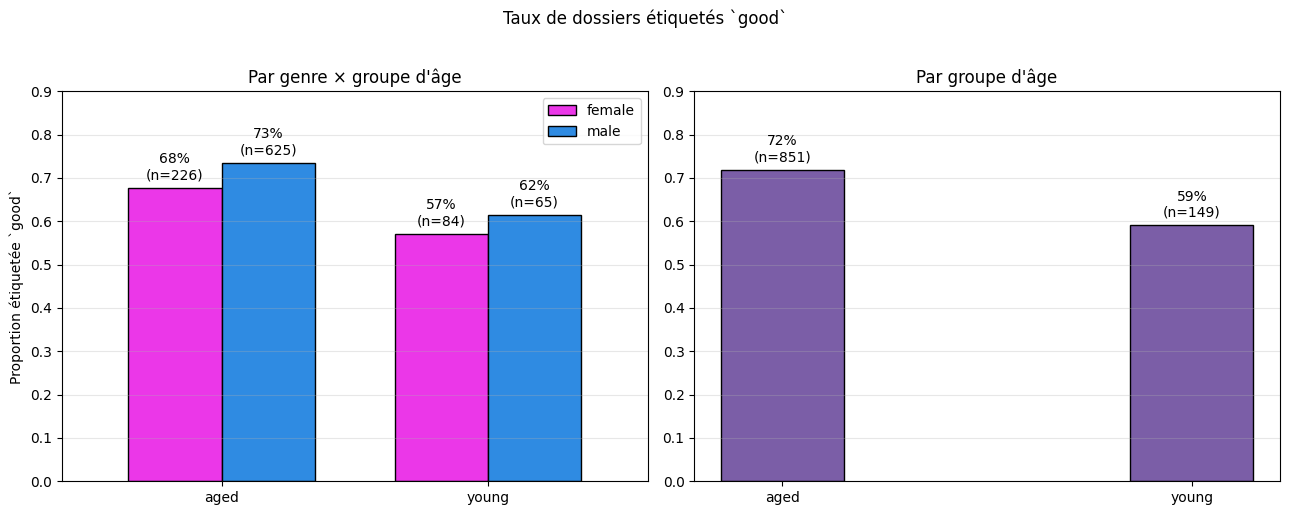

In [281]:
stats = (df.assign(good=(df['class'] == 'good').astype(int))                                        
            .groupby(['age_group', 'sex'])['good']                                                   
            .agg(taux='mean', n='count'))                                                            
taux      = stats['taux'].unstack()                                                                 
effectifs = stats['n'].unstack()                                                                    
                                                                                                    
marg = (df.assign(good=(df['class'] == 'good').astype(int))                                         
        .groupby('age_group')['good']
        .agg(taux='mean', n='count'))                                                             
                                                                                                    
fig, axes = plt.subplots(1, 2, figsize=(13, 5))                                                     

ax = axes[0]                                                                                        
taux.plot(kind='bar', ax=ax, color=["#EB37E8", "#2F8BE2"],
        edgecolor='black', width=0.7)                                                             
for container, sex in zip(ax.containers, taux.columns):
    labels = [f"{v:.0%}\n(n={effectifs.loc[ag, sex]})"                                              
            for ag, v in zip(taux.index, container.datavalues)]                                   
    ax.bar_label(container, labels=labels, padding=4, fontsize=10)                                  
ax.set_title("Par genre × groupe d'âge")                                                            
ax.set_ylabel("Proportion étiquetée `good`")                                                        
ax.set_xlabel("")                                                                                   
ax.set_ylim(0, 0.9)
ax.grid(axis='y', alpha=0.3)                                                                        
ax.legend(title="")                                                                                 
ax.tick_params(axis='x', rotation=0)
                                                                                                    
ax = axes[1]
ax.bar(marg.index, marg['taux'], color="#7B5EA7",                                                   
        edgecolor='black', width=0.3)                                                                
labels = [f"{v:.0%}\n(n={marg.loc[ag, 'n']})"
        for ag, v in zip(marg.index, marg['taux'])]                                               
ax.bar_label(ax.containers[0], labels=labels, padding=4, fontsize=10)
ax.set_title("Par groupe d'âge")                                                         
ax.set_xlabel("")                                                                                   
ax.set_ylabel("")                                                                                   
ax.set_ylim(0, 0.9)                                                                                 
ax.grid(axis='y', alpha=0.3)                                                                        
ax.tick_params(axis='x', rotation=0)                                                                

fig.suptitle("Taux de dossiers étiquetés `good`", y=1.02, fontsize=12)                              
plt.tight_layout()                                                                                  
plt.show()  

- Le taux d'étiquetage `good` est plus faible chez les jeunes (~59 %) que chez les adultes (~72 %), 
  soit un écart marginal d'environ 12 points. 
  
- Cet écart est stable entre les deux sexes (~11 points dans chaque), ce qui suggère un effet propre à l'âge non confondu par la composition genre × âge. 

- Le sous groupe des jeunes (n = 149) est plus petit que celui des personnes âgées (n = 851), les estimations seront donc plus incertaines . 

> Quand les taux de base diffèrent entre groupes (~12 points ici), les principales définitions de
fairness sont mutuellement incompatibles (Chouldechova 2017). Tout choix de mitigation imposera un 
arbitrage.


## 2. Baseline - Logistic Regression

> Pour la baseline, nous retenons une régression logistique, modèle de référence en credit scoring pour sa simplicité, sa parcimonie et l'interprétabilité directe de ses coefficients en log-odds.

> La Régression logistique est ici appliqué sans rebalancing ni régularisation (`C → ∞`). Cette configuration minimale sert de référence pour la suite, les implications de ces choix (calibration, variance) seront discutées au moment où elles deviennent pertinentes ( seuillage cost-sensitive, mitigation).

In [282]:
X = df.drop(columns=['class', 'sex', 'age_group'])
A = (df['age'] < 25).astype(int)                                                                    


# Stratification jointe sur (Y, A)
strates = y.astype(str) + "_" + A.astype(str)

X_train, X_test, y_train, y_test, A_train, A_test = train_test_split(
X, y, A,
test_size=0.3,
stratify=strates,
random_state=RANDOM_STATE
)

print(f"Train : {len(X_train)} lignes — {y_train.mean():.1%} good, {A_train.mean():.1%} jeunes")    
print(f"Test  : {len(X_test)} lignes  — {y_test.mean():.1%} good, {A_test.mean():.1%} jeunes")   

Train : 700 lignes — 70.0% good, 15.0% jeunes
Test  : 300 lignes  — 70.0% good, 14.7% jeunes


**Stratification jointe sur (Y, A)**
<br><br>

> Le dataset est séparé en train/test (70/30) avec une stratification sur la paire (cible, attribut sensible), où : </br>

- $Y$ désigne la variable cible.
- $A$ l’âge binarisé à 25 ans.

<br>

 Une stratification simple ne préserve qu'une marge :   

$$P_{\text{train}}(Y=1) \approx P_{\text{test}}(Y=1)$$

 La stratification jointe  préserve en plus la distribution **jointe** : 

$$P_{\text{train}}(Y=y, A=a) \approx P_{\text{test}}(Y=y, A=a), \quad \forall (y,a) \in \{0,1\}^2$$

En particulier, la part des jeunes solvables $P(Y=1, A=1)$ est conservée d'un split à l'autre.


> Avec $n_{\text{test}} = 300$ et seulement 14 % de jeunes, certains sous-groupes contiennent très peu d’individus (par exemple jeunes ∩ good, environ 26 observations). Sans stratification jointe sur $(Y, A)$, leur proportion peut varier fortement entre les splits, ce qui rend les métriques de fairness instables.

In [283]:
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()                   
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()                                
                                                                                                    
preprocessor = ColumnTransformer([                                                                  
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),                        
    ('num', StandardScaler(), num_cols),                                                            
])                                                                                                  
                                                                                                    
baseline = Pipeline([
    ('preproc', preprocessor),
    ('clf', LogisticRegression(
        C=1e10,                # régularisation effectivement nulle → calibration naturelle
        max_iter=5000,         
        solver='lbfgs',
        random_state=RANDOM_STATE,
    )),
])                                                                                            
                                                                                                    
baseline.fit(X_train, y_train)                                                                        

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preproc', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

In [284]:
proba_test = baseline.predict_proba(X_test)[:, 1]   # P(Y=1 | x) = P(good | x)                      
                                                                            
print(f"Baseline entraînée. Forme proba_test : {proba_test.shape}, "                                
    f"plage : [{proba_test.min():.3f}, {proba_test.max():.3f}]") 

Baseline entraînée. Forme proba_test : (300,), plage : [0.025, 0.998]


In [285]:
def evaluate(model, X, y, label, threshold=0.5):
    proba = model.predict_proba(X)[:, 1]
    pred  = (proba >= threshold).astype(int)
    return {                                                                                        
        'set':       label,
        'threshold': threshold,                                                                     
        'AUROC':     roc_auc_score(y, proba),                                                    
        'F1':        f1_score(y, pred),                                                             
        'Precision': precision_score(y, pred),                                                   
    }        

In [286]:
def evaluate_by_group(model, X, y, A, threshold=0.5):                                            
    proba = model.predict_proba(X)[:, 1]                                                            
    pred  = (proba >= threshold).astype(int)
    rows = []                                                                                       
    for g, label in [(1, 'jeune (A=1)'), (0, 'adulte (A=0)')]:                                      
        mask = (A == g)                     
        rows.append({                                                                               
            'group':     label,                                                                     
            'n':         mask.sum(),                                                                
            'AUROC':     roc_auc_score(y[mask], proba[mask]),                                       
            'F1':        f1_score(y[mask], pred[mask]),                                             
            'Precision': precision_score(y[mask], pred[mask]),                                      
            'Recall':    recall_score(y[mask], pred[mask]),
            'P(Ŷ=1)':   pred[mask].mean(),                                                          
        })                                                                                          
    return pd.DataFrame(rows).set_index('group').round(3)

In [287]:
results = pd.DataFrame([                                                                            
    evaluate(baseline, X_train, y_train, 'train', threshold=0.5),                                
    evaluate(baseline, X_test,  y_test,  'test',  threshold=0.5),                                   
]).set_index('set').round(3)                
                                                                                                    
results 

,threshold,AUROC,F1,Precision
set,,,,
train,0.5,0.839,0.854,0.817
test,0.5,0.775,0.827,0.803



> L'écart train/test sur l'AUROC est de 4.7 points, soit une généralisation correcte sans surapprentissage marqué.
>

In [288]:
evaluate_by_group(baseline, X_test, y_test, A_test, threshold=0.5)    

,n,AUROC,F1,Precision,Recall,P(Ŷ=1)
group,,,,,,
jeune (A=1),44,0.733,0.727,0.69,0.769,0.659
adulte (A=0),256,0.778,0.841,0.82,0.864,0.758


### 3. Le contexte bancaire et l'asymétrie des coûts : 


### 3.1 Asymétrie des erreurs </br>

a. Pourquoi toutes les erreurs ne se valent pas ? </br>

Le scoring crédit n’est pas un problème de classification neutre. La décision du modèle engage directement le bilan de l’institution financière.

Le seuil $\tau$ utilisé jusqu’ici ($0.5$) est celui par défaut de scikit-learn, mais il suppose implicitement que les deux types d’erreur ont le même coût. </br> 

Or, dans un problème de crédit, ce n’est pas le cas : refuser un bon client (perte d’opportunité commerciale) et accorder un crédit à un client risqué (perte potentielle du capital prêté) n’ont pas le même impact économique. </br>
</br> </br>

b. La matrice de coût du German Credit

> Le German Credit Dataset modélise explicitement cette asymétrie à travers la matrice de coût suivante : 

  $$                                                                                                                      
  C =
  \begin{pmatrix}                                                                                                         
  0 & 1 \\                                                                                                                
  5 & 0
  \end{pmatrix}                                                                                                           
  $$


Où :
- Un faux positif (accorder un crédit à un client risqué) coûte ainsi 5 fois plus qu’un faux négatif (refuser un client solvable).

###  3.2 Du coût au seuil bayésien optimal

> La matrice de coût ne modifie pas seulement l’évaluation du modèle = elle change également la règle de décision. Le seuil optimal devient alors celui qui minimise le coût attendu des décisions de crédit.

</br> </br>


a. Coût attendu des deux décisions 

</br> </br> 
$$
\mathbb{E}[C \mid \text{accepter}] = c_{TP} \cdot p + c_{FP} \cdot (1-p) = c_{FP} \cdot (1-p)
$$

$$
\mathbb{E}[C \mid \text{refuser}] = c_{FN} \cdot p + c_{TN} \cdot (1-p) = c_{FN} \cdot p
$$

</br>

<span style="color:#7F8C8D;">

Soit $p = P(Y=1 \mid x)$ la probabilité estimée que le client soit solvable. </br>
(On utilise $c_{TP} = c_{TN} = 0$ : les bonnes décisions sont à coût nul.)

</span> </br> </br> 




b. Règle de décision optimale. </br> </br></br> La banque accorde le crédit uniquement lorsque le coût attendu de l'acceptation est inférieur à celui du refus :</br></br>  

$$
\mathbb{E}[C \mid \text{accepter}] < \mathbb{E}[C \mid \text{refuser}]
$$

ce qui donne :

$$
c_{FP} \cdot (1-p) < c_{FN} \cdot p
$$

En isolant $p$ :

$$
p > \frac{c_{FP}}{c_{FP} + c_{FN}}
$$

Le seuil bayésien optimal est donc :

$$
\boxed{\tau^\star = \frac{c_{FP}}{c_{FP} + c_{FN}}}
$$
</br> </br> </br>

c. Application au German Credit. </br> </br></br>   Avec $c_{FP} = 5$ et $c_{FN} = 1$ :

$$
\boxed{\tau^\star = \frac{5}{5+1} = \frac{5}{6} \approx 0{,}833}
$$

> Le seuil $\tau^\star$ minimise le coût attendu des décisions de crédit. Il servira donc de seuil de référence pour l’évaluation des métriques de fairness dans la suite de l’étude.

In [289]:
C_FP, C_FN = 5, 1
tau_star = C_FP / (C_FP + C_FN)         
                                                            
print(f"τ★= {tau_star:.2f}")                                                                              

τ★= 0.83


In [290]:
def cost_at(tau):                                                                                                                                                                                                                                      
    y_pred = (proba_test >= tau).astype(int)                                                                                                                                                                                                           
    fp = ((y_pred == 1) & (y_test == 0)).sum()                                                                                                                                                                                                         
    fn = ((y_pred == 0) & (y_test == 1)).sum()
    return (C_FP * fp + C_FN * fn) / len(y_test)          

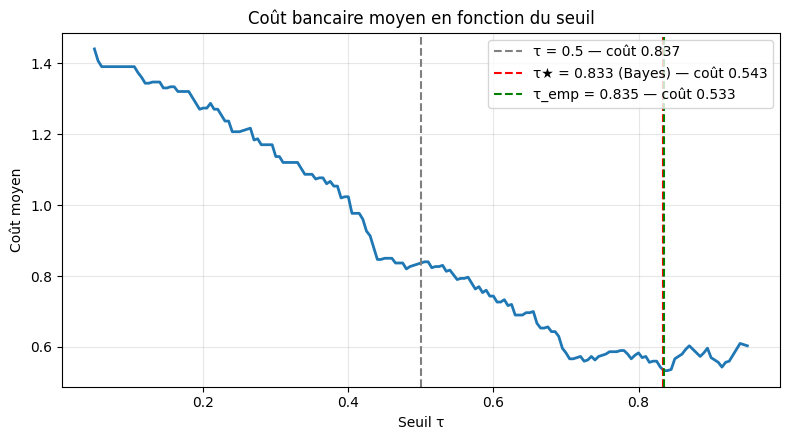

In [291]:
taus  = np.linspace(0.05, 0.95, 181)                                                                                                                                                                                                                   
costs = np.array([cost_at(t) for t in taus])                                                                                                                                                                                                           
tau_emp  = taus[np.argmin(costs)]                                                                                                                                                                                                                      
cost_emp = costs.min()                                                                                                                                                                                                                                 
cost_star = cost_at(tau_star)                                                                                                                                                                                                                        
cost_05   = cost_at(0.5)                                                                                                                                                                                                                               
                                                                                                                                                                                                                                                    
# Affichage                                                                                                                                                                                                                                            
fig, ax = plt.subplots(figsize=(8, 4.5))                                                                                                                                                                                                             
ax.plot(taus, costs, color='tab:blue', lw=2)                                                                                                                                                                                                           
                                                                                                                                                                                                                                                        
ax.axvline(0.5,      color='gray',  ls='--', lw=1.5, label=f'τ = 0.5 — coût {cost_05:.3f}')                                                                                                                                                            
ax.axvline(tau_star, color='red',   ls='--', lw=1.5, label=f'τ★ = {tau_star:.3f} (Bayes) — coût {cost_star:.3f}')                                                                                                                                      
ax.axvline(tau_emp,  color='green', ls='--', lw=1.5, label=f'τ_emp = {tau_emp:.3f} — coût {cost_emp:.3f}')                                                                                                                                             
                                                                                                                                                                                                                                                        
ax.set_xlabel('Seuil τ'); ax.set_ylabel('Coût moyen')                                                                                                                                                                                                  
ax.set_title("Coût bancaire moyen en fonction du seuil")                                                                                                                                                                                               
ax.legend(loc='upper right'); ax.grid(alpha=0.3)                                                                                                                                                                                                       
plt.tight_layout(); plt.show()                                                                                                                                                                                                                            

In [292]:
print(f"Δτ (τ★ − τ_emp) = {tau_star - tau_emp:+.3f}  →  τ_emp aligné sur τ★ Bayes")                                                                                                                                                                    

Δτ (τ★ − τ_emp) = -0.002  →  τ_emp aligné sur τ★ Bayes


## Analyse

 Le seuil optimal théorique $\tau^\star = 0{,}833$ et le seuil empirique $\tau_{\text{emp}} = 0{,}835$ coïncident ($\Delta\tau = -0{,}002$),  la règle bayésienne s'applique directement à nos scores. </br></br> 
 


> Cette superposition des valeurs n'est pas un hasard, elle est possible grâce à une bonne calibration du modèle. 

> Bonne calibration $\leftrightarrow$ les probabilités prédites par le modèle correspondent bien aux fréquences observées.

> C'est ce qui nous permet d'appliquer la règle de décision bayésienne sans nécessiter d'ajustement supplémentaire.

🖱️ Calibration

In [293]:
results = pd.DataFrame({                                                                                                                                                                                                                               
    'Origine':            ['Défaut sklearn', 'Bayes (théorique)', 'Empirique (test)'],                                                                                                                                                               
    'Coût moyen':         [round(cost_05, 4), round(cost_star, 4), round(cost_emp, 4)],                                                                                                                                                                
    'Réduction vs τ=0.5': ['—',                                                                                                                                                                                                                        
                            f"{(1 - cost_star/cost_05)*100:+.1f} %",                                                                                                                                                                                    
                            f"{(1 - cost_emp/cost_05)*100:+.1f} %"],                                                                                                                                                                                    
}, index=pd.Index([0.5, round(tau_star, 3), round(tau_emp, 3)], name='τ'))                                                                                                                                                                           
                                                                                                                                                                                                                                                        
results         

,Origine,Coût moyen,Réduction vs τ=0.5
τ,,,
0.500,Défaut sklearn,0.8367,—
0.833,Bayes (théorique),0.5433,+35.1 %
0.835,Empirique (test),0.5333,+36.3 %


 Adopter $\tau^\star$ réduit le coût bancaire de 35 % par rapport au défaut sklearn. </br>  Ce gain économique a un prix en équité, quantifié dans la section suivante.

## 4. Métrique de fairness : 

> **Convention utilisée pour la suite :**
>
> - $A = 1$ : clients jeunes ($\leq 25$ ans) ;
> - $A = 0$ : clients adultes ($> 25$ ans).
>
> Les clients adultes constituent donc le groupe de référence, et les clients jeunes le groupe potentiellement défavorisé.


In [294]:
threshold = 0.833                                                                                                      
y_pred = (proba_test >= threshold).astype(int)     

<u> a. Demographic Parity (DP) : </u> <br>                                                          
**Objectif :** vérifier que le modèle accorde le crédit au même taux dans les deux groupes.                             
                                                                                                                          
  $$                                                                                                                      
  \Delta\text{DP} = P(\hat{Y}=1 \mid A=1) - P(\hat{Y}=1 \mid A=0)                                                         
  $$    

In [295]:
def compute_dp(proba, A, threshold=0.5, verbose=True):
    y_pred = (proba >= threshold).astype(int)
                                            
    mask_jeune  = (A == 1)                  
    mask_adulte = (A == 0)              
                                                                                                                        
    DP_jeune  = y_pred[mask_jeune].mean()                                                                               
    DP_adulte = y_pred[mask_adulte].mean()                                                                              
    delta_DP  = DP_jeune - DP_adulte                                                                                    
                                                                                                                        
    if verbose:
        print(f"Seuil τ = {threshold}")                                                                                 
        print(f"DP jeune  : {DP_jeune:.3f}  (n={mask_jeune.sum()})")
        print(f"DP adulte : {DP_adulte:.3f}  (n={mask_adulte.sum()})")                                                  
        print(f"ΔDP       : {delta_DP:+.3f}")                                                                           
                                        
    return delta_DP 

In [296]:
delta_DP = compute_dp(proba_test, A_test, threshold=0.833)       

Seuil τ = 0.833
DP jeune  : 0.250  (n=44)
DP adulte : 0.516  (n=256)
ΔDP       : -0.266



La règle des "4/5" est un principe juridique <span style="color:#4A90E2;"> américain (EEOC) </span> qui évalue si un système de sélection est équitable.


<br> Pour qu'un système soit équitable il faut qu'il respecte le ratio suivant :                                                                                                                      

  $$                                                                                                                      
  \frac{\text{DP}_{\text{défavorisé}}}{\text{DP}_{\text{favorisé}}} \geq 0.8
  $$

$$
\frac{0{,}250}{0{,}516} \approx 0{,}48 \;<\; 0{,}80
$$



Ainsi la règle est non respectée.                                                                                          
Les jeunes sont défavorisés (taux d'accord plus bas) avec 26,6 points d'écart
.

> <span style="color:#D4AC0D;"> <u> Remarque </span> </u> <br><br> Dans le cadre bancaire, égaliser DP n'a pas d'intérêt opérationnel.<br><br> On forcerait la banque à accorder le crédit à des jeunes en incapacité réelle de rembourser, et leurs défauts alimenteraient négativement l'historique (feedback loop) aggravant le biais au lieu de le corriger. <br> <br> (*disparate impact amplification* via *selection bias under intervention*, Ensign et al. 2018).

<div align="center">
<img src="im.png" width="900"/>
</div>



<u> b. Equal Opportunity (EOpp) : </u> <br><br>
**Objectif** : Vérifier que parmi les vrais bons clients (Y=1), le modèle sélectionne autant de personnes dans chaque groupe.

  $$
  \Delta\text{EOpp} = P(\hat{Y}=1 \mid Y=1, A=1) - P(\hat{Y}=1 \mid Y=1, A=0)
  $$
  


 EOpp protège l'accès ("ai-je la même chance qu'un autre quand je suis légitime ?").<br>


In [297]:
def compute_eopp(proba, y_true, A, threshold=0.5, verbose=True):
    y_pred = (proba >= threshold).astype(int)
                                            
    mask_jeune  = (A == 1) & (y_true == 1)
    mask_adulte = (A == 0) & (y_true == 1)
                                                                                                                        
    TPR_jeune  = y_pred[mask_jeune].mean()  
    TPR_adulte = y_pred[mask_adulte].mean()                                                                             
    delta_EOpp = TPR_jeune - TPR_adulte                                                                                 
                                                                                                                        
    if verbose:                         
        print(f"Seuil τ = {threshold}")                                                                                 
        print(f"TPR jeune  : {TPR_jeune:.3f}  (n={mask_jeune.sum()})")                                                  
        print(f"TPR adulte : {TPR_adulte:.3f}  (n={mask_adulte.sum()})")
        print(f"ΔEOpp      : {delta_EOpp:+.3f}")                                                                        
                                                                                                                        
    return delta_EOpp 

In [298]:
delta_EOpp = compute_eopp(proba_test, y_test, A_test, threshold=0.833)                                                 

Seuil τ = 0.833
TPR jeune  : 0.385  (n=26)
TPR adulte : 0.636  (n=184)
ΔEOpp      : -0.251


## Analyse 

 À τ\* = 0,833, le modèle rate   <span style="color:#d97706;">62 % des bons clients jeunes  </span> contre  <span style="color:#d97706;"> 36 % des adultes seulement </span> </br></br>

<div align="center">
<span style="color:#dc6b6b;">
Près de 1,7× plus d'erreurs
</span> sur les jeunes solvables.
</div> </br></br>
 
* |ΔEOpp| dépasse largement le seuil conventionnel de $0{,}10$ (Friedler 2019, AIF360), sans constituer une violation au sens juridique strict. </br>

* Aucun ratio normatif n'existe pour EOpp, contrairement à DP.

### Caveat fiabilité 

TPR jeune est calculé sur 26 personnes seulement..

La valeur dépend fortement de quelles 26 personnes ont été tirées !
 </br> </br>
 > ▸  Un autre split aurait pu donner 0.45 ou 0.70 sans que le modèle ait changé.  C'est le bruit d'échantillonnage.                                                                                              
</br></br>
▸ Pour le quantifier, on rééchantillonne le test set 1000 fois (bootstrap) et on rapporte trois indicateurs complémentaires : </br>
 - un intervalle de confiance à 95 %
 - un intervalle de confiance à 90 % 
 - une probabilité directionnelle P(Δ<0).  

In [299]:
def bootstrap_ci(metric_fn, y, yhat, A, n_boot=1000, seed=RANDOM_STATE):                                                

    rng = np.random.default_rng(seed)                                                                                   
    n = len(y)                                                                                                          
    samples = []    

    for _ in range(n_boot):   

        idx = rng.integers(0, n, size=n)                                                                                
        d = metric_fn(y[idx], yhat[idx], A[idx])   

        if d is not None:                                                                                               
            samples.append(d)      

    s = np.array(samples) 
                                                                                                  
    return {                                                                                                            
        'delta':    metric_fn(y, yhat, A),  
        'ic95':     tuple(np.percentile(s, [2.5, 97.5])),                                                               
        'ic90':     tuple(np.percentile(s, [5,   95])),                                                                 
        'p_dir':    (s < 0).mean() if metric_fn(y, yhat, A) < 0 else (s > 0).mean(),                                    
    }      

In [300]:
def show_ci(name, delta, r): 
                                                                                               
    return pd.DataFrame({                                                                                               
        'Δ':                   [round(delta, 3)],                                                                       
        'IC 95%':              [f"[{r['ic95'][0]:+.3f}, {r['ic95'][1]:+.3f}]"],
        'IC 90%':              [f"[{r['ic90'][0]:+.3f}, {r['ic90'][1]:+.3f}]"],                                         
        'P(Δ dans sens obs.)': [round(r['p_dir'], 3)],
    }, index=[name])                                                                                                    
            

In [301]:
y_test_np = np.asarray(y_test)
A_test_np = np.asarray(A_test)  

show_ci("ΔEOpp", delta_EOpp, bootstrap_ci(                                                                              
    lambda y, yhat, a: yhat[(a==1)&(y==1)].mean() - yhat[(a==0)&(y==1)].mean(),
    y_test_np, y_pred, A_test_np                                                                                        
))                                          

,Δ,IC 95%,IC 90%,P(Δ dans sens obs.)
ΔEOpp,-0.251,"[-0.450, -0.053]","[-0.416, -0.088]",0.994


- Le signal est significatif au seuil 5 % . Le 0 exclut entièrement zéro. </br>
- Le signal est significatif au seuil 10 %. </br>
- On obtient une probabilité directionnelle tq P(Δ<0) = 0.994 indiquant que près de 99% des bootstraps sont strictement négatifs.
 <br> <br> 

> On peut donc considérer le signal comme fiable malgré l'effectif réduit (n=26).


> <span style="color:#D4AC0D;"> <u> Remarque </span> </u> <br><br> Dans le cadre bancaire, égaliser Eopp est la métrique la plus intéressante au niveau opérationnel.<br><br> Elle ne demande l'égalité que parmi les vrais bons clients (Y=1). <br> <br> La banque n'est donc pas forcée d'accorder à des profils "défaillants" (contrairement à DP).
</br></br>  L'institution doit traiter à parts égales les jeunes et les adultes qui "rembourseraient effectivement". 



<sub>
<b>Nuance.</b> Comme évoqué plus haut, il faut garder à l'esprit que l'étiquette "good" est biaisée par le point de vue de la banque, et ne correspond pas nécessairement à une capacité réelle de remboursement (construct invalidity), d'où le choix des guillemets pour le mot "rembourseraient effectivement" ou encore "défaillants".
</sub>

<u> c.  Equalized Odds (EOdds) : </u> <br><br>
 **Objectif** : vérifier que les deux taux d'erreur sont égaux entre groupes = refus à tort sur les vrais good (TPR),
  **et** accord à tort sur les vrais bad (FPR).
Soit s'assurer de ne pas refuser plus de bons clients ni accorder plus de crédits à de mauvais clients selon le groupe.


  $$                                                                                                                      
  \Delta\text{EOdds} = \max(|\Delta\text{TPR}|,\ |\Delta\text{FPR}|)                                                      
  $$            

In [302]:
def compute_eodds(proba, y_true, A, threshold=0.5, verbose=True):
    y_pred = (proba >= threshold).astype(int)
                                                                                                                        
    mask_j_good = (A == 1) & (y_true == 1)  
    mask_a_good = (A == 0) & (y_true == 1) 

    TPR_j = y_pred[mask_j_good].mean()                                                                                  
    TPR_a = y_pred[mask_a_good].mean()  

    delta_TPR = TPR_j - TPR_a                                                                                           
                                                                                                                        
    mask_j_bad = (A == 1) & (y_true == 0)                                                                               
    mask_a_bad = (A == 0) & (y_true == 0)

    FPR_j = y_pred[mask_j_bad].mean()                                                                                   
    FPR_a = y_pred[mask_a_bad].mean()     

    delta_FPR = FPR_j - FPR_a               
                                                                                                                        
    delta_EOdds = max(abs(delta_TPR), abs(delta_FPR))                                                                   
                                                                                                                        
    if verbose:
        print(f"Seuil τ = {threshold}")                       

        print("\n ")
        print(f"TPR jeune  : {TPR_j:.3f}  (n={mask_j_good.sum()})   ΔTPR = {delta_TPR:+.3f}")                           
        print(f"TPR adulte : {TPR_a:.3f}  (n={mask_a_good.sum()}) ")     

        print("\n ")
        print(f"FPR jeune  : {FPR_j:.3f}  (n={mask_j_bad.sum()})   ΔFPR = {delta_FPR:+.3f}")                            
        print(f"FPR adulte : {FPR_a:.3f}  (n={mask_a_bad.sum()}) ")

        print(f"\nΔEOdds     : {delta_EOdds:.3f}   (= max(|ΔTPR|, |ΔFPR|))")                                              
                                                                                                                        
    return delta_EOdds    

In [303]:
delta_EOdds = compute_eodds(proba_test, y_test, A_test, threshold=0.833)                                             

Seuil τ = 0.833

 
TPR jeune  : 0.385  (n=26)   ΔTPR = -0.251
TPR adulte : 0.636  (n=184) 

 
FPR jeune  : 0.056  (n=18)   ΔFPR = -0.153
FPR adulte : 0.208  (n=72) 

ΔEOdds     : 0.251   (= max(|ΔTPR|, |ΔFPR|))


## Analyse 

- Sur les bons clients on rate près de 1.7× plus les jeunes (ΔTPR = −0.251) par rapport aux adultes, et sur les mauvais on en accepte à tort 3.7× moins (ΔFPR = −0.153). <br>
- Le modèle est donc **plus strict avec les jeunes des deux côtés**, il leur dit "non" plus souvent, qu'ils méritent un crédit ou non.

- Ce qui est une bonne nouvelle pour les jeunes car ils sont au moins protégés contre les accords à tort, qui risqueraient d'aggraver leur historique de crédit et les pénaliser à l'avenir. Si le modèle accordait massivement des crédits aux jeunes mauvais payeurs, leurs défauts s'inscriraient dans l'historique de crédit du groupe, alimentant les futures décisions du modèle qui apprendrait à *justifier* statistiquement leur exclusion.

<div align="center">
<img src="im.png" width="900"/>
</div>



> EOdds est dominé par le TPR , c'est la même violation qu'EOpp, avec un FPR plus favorable côté jeunes. La mitigation ciblera donc EOpp (faire monter le TPR des jeunes), tout en gardant à l'œil le FPR pour ne pas annuler cet avantage en sur-acceptant des jeunes risqués.


<sub>
<b>Nuance.</b> A noter que le FPR reste une métrique importante dans notre analyse notamment à cause du cout élevé associer aux faux positifs dans le contexte bancaire.
</sub>

### Vérification de la fiabilité du signal 

In [304]:
y_pred = (proba_test >= tau_star).astype(int)                                                                                                                                                                                                        
y_test_np = np.asarray(y_test)                                                                                                                                                                                                                         
A_test_np = np.asarray(A_test)

In [305]:
fpr_jeune  = y_pred[(A_test_np==1) & (y_test_np==0)].mean()                                                                                                                                                                                          
fpr_adulte = y_pred[(A_test_np==0) & (y_test_np==0)].mean()                                                                                                                                                                                            
delta_FPR  = fpr_jeune - fpr_adulte                                                                                                                                                                                                                    
print(f"FPR jeune  : {fpr_jeune:.3f}  (n={((A_test_np==1)&(y_test_np==0)).sum()})")                                                                                                                                                                    
print(f"FPR adulte : {fpr_adulte:.3f}  (n={((A_test_np==0)&(y_test_np==0)).sum()})")                                                                                                                                                                   
print(f"ΔFPR       : {delta_FPR:+.3f}\n")     

FPR jeune  : 0.056  (n=18)
FPR adulte : 0.208  (n=72)
ΔFPR       : -0.153



In [306]:
show_ci("ΔFPR", delta_FPR, bootstrap_ci(                                                                                                                                                                                                               
    lambda y, yhat, a: yhat[(a==1)&(y==0)].mean() - yhat[(a==0)&(y==0)].mean(),                                                                                                                                                                        
    y_test_np, y_pred, A_test_np                                                                                                                                                                                                                       
))          

,Δ,IC 95%,IC 90%,P(Δ dans sens obs.)
ΔFPR,-0.153,"[-0.278, -0.004]","[-0.264, -0.035]",0.976


- Le signal est significatif au seuil 5 % . Le 0 exclut entièrement zéro. </br>
- Le signal est significatif au seuil 10 %. </br>
- On obtient une probabilité directionnelle tq P(Δ<0) = 0.976 indiquant que 97.6% des bootstraps sont strictement négatifs.
 <br> <br> 

<u> d.  Predictive Parity (PP) : </u> <br><br>

**Objectif.** Vérifier qu'un dossier accepté a la même probabilité d'être un bon client dans les deux groupes.




 $$                                          
  \Delta\text{PP} = P(Y = 1 \mid \hat{Y} = 1,\ A = 1) - P(Y = 1 \mid \hat{Y} = 1,\ A = 0)
  $$   


  PP protège la signification ("ce qu'on dit de moi vaut-il la même chose ?").

In [307]:
def compute_pp(proba, y_true, A, threshold=0.5, verbose=True):                                                          
    y_pred = (proba >= threshold).astype(int)                                                                           
                                                                                                                        
    mask_jeune_pos  = (A == 1) & (y_pred == 1)                                                                          
    mask_adulte_pos = (A == 0) & (y_pred == 1)                                                                          
                                                                                                                        
    PP_jeune  = y_true[mask_jeune_pos].mean()                                                                           
    PP_adulte = y_true[mask_adulte_pos].mean()                                                                          
    delta_PP  = PP_jeune - PP_adulte                                                                                    
                                                                                                                        
    if verbose:
        print(f"Seuil τ = {threshold}")                                                                                 
        print(f"PP jeune  : {PP_jeune:.3f}  (n={mask_jeune_pos.sum()})")                                                
        print(f"PP adulte : {PP_adulte:.3f}  (n={mask_adulte_pos.sum()})")                                              
        print(f"ΔPP       : {delta_PP:+.3f}")                                                                           
                                                                                                                        
    return delta_PP     

In [308]:
delta_PP = compute_pp(proba_test, y_test, A_test, threshold=0.83)                                                        

Seuil τ = 0.83
PP jeune  : 0.909  (n=11)
PP adulte : 0.886  (n=132)
ΔPP       : +0.023


## Analyse 
À τ\* = 0,833, parmi les clients acceptés, le modèle a raison dans 91 % des cas chez les jeunes contre 89 % chez les adultes. ΔPP = +0,023.

>Les acceptations à τ\* sont fiables dans les deux groupes. </br></br>
>L'écart entre groupes n'existe presque pas. </br></br>
>À τ\*, la predictive parity est satisfaite, un crédit accordé signifie la même chose pour un jeune et pour un adulte.




In [309]:
def pp_metric(y, yhat, A):
    mask_j = (A == 1) & (yhat == 1)
    mask_a = (A == 0) & (yhat == 1)
    if mask_j.sum() == 0 or mask_a.sum() == 0:
        return None
    return y[mask_j].mean() - y[mask_a].mean()

y_pred_83 = (proba_test >= 0.833).astype(int)
result = bootstrap_ci(pp_metric, y_test_np, y_pred_83, A_test_np)
show_ci("ΔPP à τ*", 0.023, result)

,Δ,IC 95%,IC 90%,P(Δ dans sens obs.)
ΔPP à τ*,0.023,"[-0.185, +0.156]","[-0.145, +0.141]",0.625


> Le modèle atteint une quasi parfaité partié sur la métrique PP  (ΔPP ≈ 0.023) mais inéquitable d'accès (ΔEOpp = -0.251). Le biais réside dans la règle de décision 
  au seuil unique, pas dans l'estimation des probabilités.

## 4. Mitigation : 

<div style="
border-left: 4px solid #4a6fa5;
padding-left: 1em;
margin: 1em 0;
">

L’analyse précédente montre qu’au seuil économiquement optimal,
les jeunes présentent un TPR plus faible que les adultes.

Abaisser le seuil permettrait mécaniquement d’augmenter ce TPR.
Cependant, dans le contexte bancaire, cette correction augmenterait
également le FPR et entrerait en conflit avec la matrice de coût
définie précédemment.

<div style="margin-top:0.6em;">
Avant de choisir une méthode de mitigation, il est donc nécessaire de comprendre l’origine structurelle de cette asymétrie.

</div>

</div>

/var/folders/ms/qzgtjj3j3mn0m5lv1hk9kcr40000gn/T/ipykernel_51501/2659163457.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


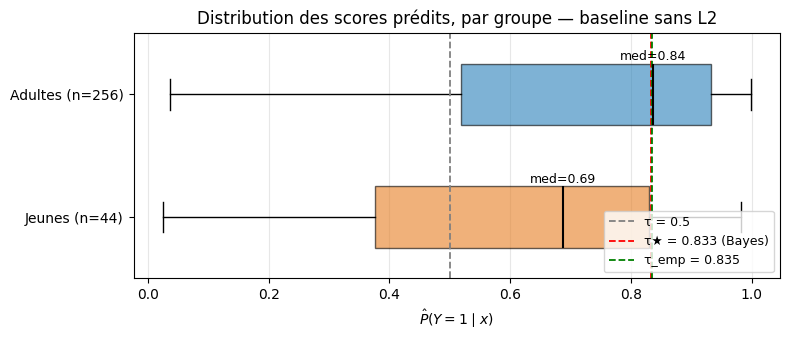

In [310]:
fig, ax = plt.subplots(figsize=(8, 3.5))                                                                                                                                                                                                               
                                                                                                                                                                                                                                                        
data = [proba_test[A_test == 1], proba_test[A_test == 0]]                                                                                                                                                                                              
labels = [f'Jeunes (n={(A_test==1).sum()})', f'Adultes (n={(A_test==0).sum()})']                                                                                                                                                                       
                                                                                                                                                                                                                                                    
bp = ax.boxplot(                                                                                                                                                                                                                                     
    data, labels=labels,                                                                                                                                                                                                                               
    patch_artist=True, vert=False, widths=0.5,                                                                                                                                                                                                       
    medianprops=dict(color='black', linewidth=1.5),                                                                                                                                                                                                  
)                                                                                                                                                                                                                                                      
for patch, c in zip(bp['boxes'], ['#E67E22', '#2980B9']):
    patch.set_facecolor(c); patch.set_alpha(0.6)                                                                                                                                                                                                       
                                                                                                                                                                                                                                                        
# Seuils de référence                                                                                                                                                                                                                                
ax.axvline(0.5,      color='gray',  ls='--', lw=1.3, label='τ = 0.5')                                                                                                                                                                                  
ax.axvline(tau_star, color='red',   ls='--', lw=1.3, label=f'τ★ = {tau_star:.3f} (Bayes)')                                                                                                                                                             
ax.axvline(tau_emp,  color='green', ls='--', lw=1.3, label=f'τ_emp = {tau_emp:.3f}')                                                                                                                                                                   
                                                                                                                                                                                                                                                        
# Médianes annotées                                                                                                                                                                                                                                    
for i, group_data in enumerate(data, start=1):                                                                                                                                                                                                         
    med = np.median(group_data)                                                                                                                                                                                                                        
    ax.text(med, i + 0.28, f'med={med:.2f}', ha='center', fontsize=9, color='black')                                                                                                                                                                   
                                                                                                                                                                                                                                                        
ax.set_xlabel(r'$\hat P(Y=1 \mid x)$')                                                                                                                                                                                                                 
ax.set_title('Distribution des scores prédits, par groupe — baseline sans L2')                                                                                                                                                                         
ax.legend(loc='lower right', fontsize=9)                                                                                                                                                                                                               
ax.grid(axis='x', alpha=0.3)                                                                                                                                                                                                                         
plt.tight_layout()                                                                                                                                                                                                                                     
plt.show()     

<h3>Analyse</h3>

<p>
Le seuil bayésien optimal est fixé à :
</p>

<script src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js"></script>

<div style="
text-align:center;
font-size:1.35em;
margin:1.2em 0 1.4em 0;
">

$$
\tau^\star = 0.833
$$

</div>
<p>
Ce seuil n’interagit pas de la même manière avec les distributions de scores
des deux groupes.
</p>

<div style="
margin:1.4em 0;
padding:0.2em 0 0.2em 1.2em;
border-left:3px solid #7a8fb8;
">

<p style="margin:0 0 0.4em 0;">
<b>Adultes</b>
</p>

<p style="margin:0;">
Le seuil se situe près du centre de la distribution,
une proportion importante d’individus possède naturellement des scores
compatibles avec l’acceptation.
</p>

</div>

<div style="
margin:1.4em 0;
padding:0.2em 0 0.2em 1.2em;
border-left:3px solid #b88a4a;
">

<p style="margin:0 0 0.4em 0;">
<b>Jeunes</b>
</p>

<p style="margin:0;">
Le seuil coupe au contraire l’extrémité haute de la distribution ,
les individus acceptés doivent appartenir à une fraction beaucoup plus
extrême de leur groupe.
</p>

</div>

<div style="
margin-top:1.6em;
padding:0.9em 1.1em;
border-radius:8px;
background:rgba(255,255,255,0.04);
border:1px solid rgba(255,255,255,0.12);
">

<b>Point central.</b><br><br>

Le problème de fairness n’apparaît donc pas uniquement après la décision
finale. Il est déjà présent dans la structure même des scores produits
par le modèle.

</div>

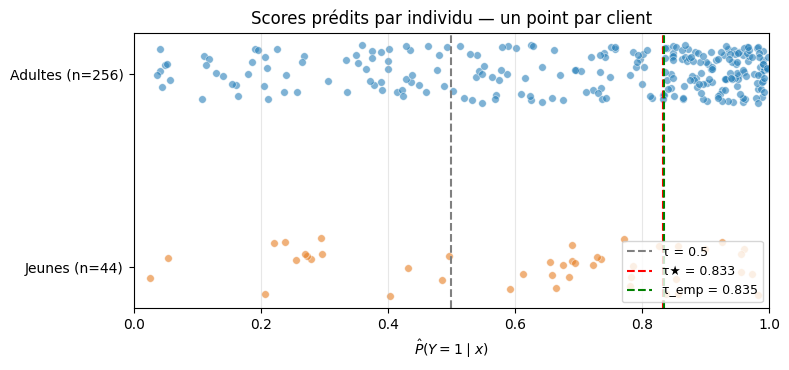

In [311]:
fig, ax = plt.subplots(figsize=(8, 3.8))                                                                                                                                                                                                               
                                                                                                                                                                                                                                                    
# Un point par individu, jitter vertical pour éviter superposition                                                                                                                                                                                     
rng = np.random.default_rng(0)                                                                                                                                                                                                                         
for i, (mask, label, color) in enumerate([                                                                                                                                                                                                             
    (A_test == 1, f'Jeunes (n={(A_test==1).sum()})',  '#E67E22'),                                                                                                                                                                                    
    (A_test == 0, f'Adultes (n={(A_test==0).sum()})', '#2980B9'),                                                                                                                                                                                      
]):                                                                                                                                                                                                                                                    
    scores = proba_test[mask]                                                                                                                                                                                                                          
    y_jitter = i + rng.uniform(-0.15, 0.15, size=len(scores))                                                                                                                                                                                          
    ax.scatter(scores, y_jitter, color=color, alpha=0.6, s=30, edgecolor='white', linewidth=0.5)                                                                                                                                                       
                                                                                                                                                                                                                                                        
ax.set_yticks([0, 1])                                                                                                                                                                                                                                  
ax.set_yticklabels([f'Jeunes (n={(A_test==1).sum()})', f'Adultes (n={(A_test==0).sum()})'])                                                                                                                                                            
                                                                                                                                                                                                                                                        
ax.axvline(0.5,      color='gray',  ls='--', lw=1.5, label='τ = 0.5')                                                                                                                                                                                  
ax.axvline(tau_star, color='red',   ls='--', lw=1.5, label=f'τ★ = {tau_star:.3f}')                                                                                                                                                                     
ax.axvline(tau_emp,  color='green', ls='--', lw=1.5, label=f'τ_emp = {tau_emp:.3f}')                                                                                                                                                                   
                                                                                                                                                                                                                                                        
ax.set_xlabel(r'$\hat P(Y=1 \mid x)$')                                                                                                                                                                                                                 
ax.set_xlim(0, 1)                                                                                                                                                                                                                                      
ax.set_title('Scores prédits par individu — un point par client')                                                                                                                                                                                      
ax.legend(loc='lower right', fontsize=9)                                                                                                                                                                                                               
ax.grid(axis='x', alpha=0.3)                                                                                                                                                                                                                           
plt.tight_layout()                                                                                                                                                                                                                                     
plt.show()                         

<h3>Analyse</h3>

<p>
La figure précédente montrait un décalage global des distributions.
Cette visualisation individualise maintenant les scores attribués à chaque client.
</p>

<br>

<div style="
margin:1.2em 0;
padding-left:1.1em;
border-left:3px solid #7a8fb8;
">

<b>Adultes</b><br><br>

Le modèle produit fréquemment des scores très élevés proches de 1,
avec une séparation relativement nette entre individus acceptés et refusés.

</div>

<div style="
margin:1.4em 0;
padding-left:1.1em;
border-left:3px solid #b88a4a;
">

<b>Jeunes</b><br><br>

Les scores apparaissent davantage concentrés dans une zone intermédiaire.

<div style="
text-align:center;
font-size:1.08em;
margin:1em 0 0.6em 0;
">

$$
0.5 \lesssim s(X) \lesssim 0.85
$$

</div>

Le modèle attribue donc beaucoup moins souvent des scores extrêmement confiants à ce groupe.

</div>

<br>

<div style="
margin-top:1.2em;
padding:0.9em 1.1em;
background:rgba(255,255,255,0.035);
border-left:3px solid #666;
border-radius:6px;
">

Cette concentration intermédiaire suggère l’existence d’une
<b>région locale d’incertitude</b> :

<ul style="margin-top:0.7em;">
<li>
certains jeunes <i>good</i> ne reçoivent pas suffisamment de preuve favorable
pour dépasser le seuil ;
</li>

<li style="margin-top:0.45em;">
certains jeunes <i>bad</i> obtiennent au contraire des scores similaires.
</li>
</ul>

</div>

<div style="
margin-top:1.4em;
padding-top:0.8em;
border-top:1px solid rgba(255,255,255,0.12);
font-size:1.02em;
">

<b>Point important.</b>

Le problème semble donc moins provenir d’erreurs isolées que
d’une difficulté structurelle du modèle à polariser les scores
chez les jeunes.

</div>

<h2>Apparition d’une région d’overlap chez les jeunes</h2>

<p>
Pour comprendre pourquoi le modèle peine à satisfaire simultanément :
</p>

<ul>
<li>un TPR élevé chez les jeunes </li>
<li>et un faible coût bancaire</li>
</ul>

<p>
il faut maintenant observer la distribution des scores
conditionnellement à la vraie classe.
</p>


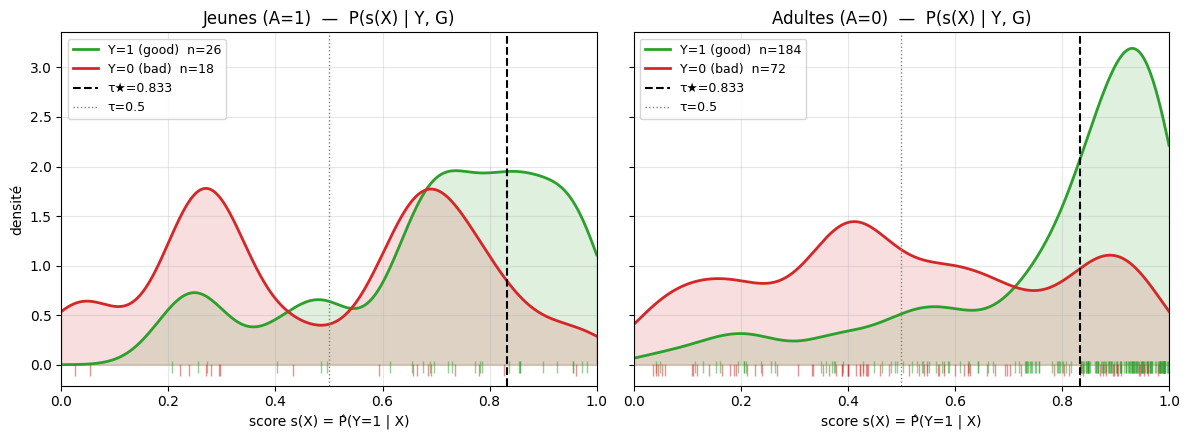

Moyennes conditionnelles E[s(X) | Y, G] :
  Jeunes (A=1)        Y=1 (good) : 0.705  (n=26)
  Jeunes (A=1)        Y=0 (bad) : 0.484  (n=18)
  Adultes (A=0)       Y=1 (good) : 0.784  (n=184)
  Adultes (A=0)       Y=0 (bad) : 0.512  (n=72)


In [312]:
A_arr = np.asarray(A_test)                                                                                              
y_arr = np.asarray(y_test)                                                                                            
p     = np.asarray(proba_test)                                                                                          
                                                                                                                    
TAU = 5/6  # 0.833

groups = {1: "Jeunes (A=1)", 0: "Adultes (A=0)"}                                                                        
colors_y = {1: "C2", 0: "C3"}  # vert = good (Y=1), rouge = bad (Y=0)
labels_y = {1: "Y=1 (good)", 0: "Y=0 (bad)"}                                                                            
                                                                                                                        
xs = np.linspace(0, 1, 400)                                                                                             
                                                                                                                        
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)                                                          

for ax, (g_val, g_name) in zip(axes, groups.items()):                                                                   
    mask_g = (A_arr == g_val)                                                                                         
    for y_val in [1, 0]:                                                                                                
        mask = mask_g & (y_arr == y_val)
        scores = p[mask]                                                                                                
        n = mask.sum()                                                                                                  
        # KDE
        kde = gaussian_kde(scores, bw_method=0.25)                                                                      
        ax.plot(xs, kde(xs), color=colors_y[y_val], lw=2,                                                               
                label=f"{labels_y[y_val]}  n={n}")                                                                      
        ax.fill_between(xs, kde(xs), alpha=0.15, color=colors_y[y_val])                                                 
        # rug                                                                                                           
        ax.plot(scores, np.full_like(scores, -0.05) + (0.03 if y_val == 1 else 0),                                    
                "|", color=colors_y[y_val], alpha=0.5, markersize=8)                                                    
    ax.axvline(TAU, color="k", ls="--", lw=1.5, label=f"τ★={TAU:.3f}")                                                  
    ax.axvline(0.5, color="gray", ls=":", lw=1, label="τ=0.5")                                                          
    ax.set_title(f"{g_name}  —  P(s(X) | Y, G)")                                                                        
    ax.set_xlabel("score s(X) = P̂(Y=1 | X)")                                                                            
    ax.set_xlim(0, 1)                                                                                                   
    ax.legend(fontsize=9, loc="upper left")                                                                             
    ax.grid(alpha=0.3)                                                                                                  
                                                                                                                    
axes[0].set_ylabel("densité")                                                                                           
plt.tight_layout()                                                                                                    
plt.show()                                                                                                              

# Diagnostics : moyennes conditionnelles                                                                                
print("Moyennes conditionnelles E[s(X) | Y, G] :")                                                                    
for g_val, g_name in groups.items():                                                                                    
    for y_val in [1, 0]:                                                                                                
        mask = (A_arr == g_val) & (y_arr == y_val)
        print(f"  {g_name:18s}  {labels_y[y_val]} : {p[mask].mean():.3f}  (n={mask.sum()})")  


<p>
La figure suivante révèle une différence structurelle majeure
entre jeunes et adultes.
</p>

<br>


<div style="
margin:1.5em 0;
padding-left:1.1em;
border-left:3px solid #b88a4a;
">

<p style="margin:0 0 0.7em 0;">
<b>Jeunes</b>
</p>

<p>
Les densités :
</p>

<div style="
text-align:center;
margin:1em 0;
font-size:1.04em;
">

$$
P(s(X)\mid Y=1, A=1)
\quad\text{et}\quad
P(s(X)\mid Y=0, A=1)
$$

</div>

<p>
présentent un chevauchement important dans une large zone intermédiaire :
</p>

<div style="
text-align:center;
margin:1em 0 1.2em 0;
font-size:1.08em;
">

$$
0.5 \lesssim s(X) \lesssim 0.85
$$

</div>

<ul style="margin-top:0;">
<li>
de nombreux jeunes <i>good</i> et <i>bad</i>
reçoivent des scores très similaires 
</li>

<li style="margin-top:0.45em;">
aucune frontière simple ne permet alors
de les séparer proprement.
</li>
</ul>

</div>

<div style="
margin-top:1.8em;
padding:1em 1.2em;
border-radius:8px;
background:rgba(255,255,255,0.04);
border:1px solid rgba(255,255,255,0.10);
">

<b>Point central.</b><br><br>

Cette région d’overlap devient le cœur du problème de fairness. 
Elle rend toute correction de l’Equal Opportunity ($EOpp$) particulièrement difficile. Abaisser le seuil pour augmenter le $TPR$ des jeunes de pénétrer dans une zone où le risque de faux positifs augmente fortement, car les deux distributions sont fortement entremêlées et ainsi faire exploser le coût bancaire.

</div>

Jeunes (A=1) : AUC = 0.733  IC95% [0.568, 0.875]  n=44
Adultes (A=0): AUC = 0.778  IC95% [0.713, 0.838]  n=256
|ΔAUC| = 0.045


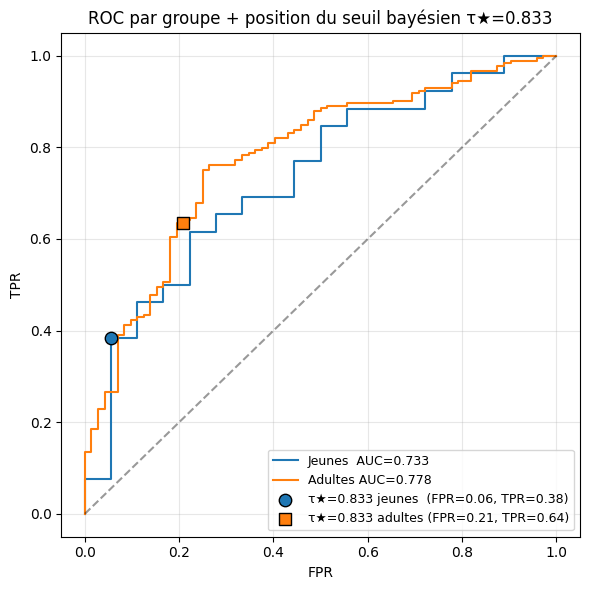


ΔTPR(τ★) = TPR_jeunes - TPR_adultes = -0.251  → |ΔEOpp|
ΔFPR(τ★) = FPR_jeunes - FPR_adultes = -0.153


In [313]:
A_arr = np.asarray(A_test)                                                                                              
y_arr = np.asarray(y_test)                                                                                              
mask_young = (A_arr == 1)                                                                                               
mask_old   = (A_arr == 0)                                                                                               

TAU = 5/6  # 0.833                                                                                                      
                
auc_young = roc_auc_score(y_arr[mask_young], proba_test[mask_young])                                                    
auc_old   = roc_auc_score(y_arr[mask_old],   proba_test[mask_old])
                                                                                                                        
def bootstrap_auc(y, p, n_boot=1000, seed=42):                                                                          
    rng = np.random.default_rng(seed)
    n = len(y)                                                                                                          
    samples = []
    for _ in range(n_boot):                                                                                             
        idx = rng.integers(0, n, n)
        if len(np.unique(y[idx])) == 2:                                                                                 
            samples.append(roc_auc_score(y[idx], p[idx]))                                                               
    return np.percentile(samples, [2.5, 50, 97.5])
                                                                                                                        
lo_y, _, hi_y = bootstrap_auc(y_arr[mask_young], proba_test[mask_young])                                                
lo_o, _, hi_o = bootstrap_auc(y_arr[mask_old],   proba_test[mask_old])                                                  
                                                                                                                        
print(f"Jeunes (A=1) : AUC = {auc_young:.3f}  IC95% [{lo_y:.3f}, {hi_y:.3f}]  n={mask_young.sum()}")                    
print(f"Adultes (A=0): AUC = {auc_old:.3f}  IC95% [{lo_o:.3f}, {hi_o:.3f}]  n={mask_old.sum()}")                        
print(f"|ΔAUC| = {abs(auc_young - auc_old):.3f}")                                                                       
                                                                                                                        
fpr_y, tpr_y, thr_y = roc_curve(y_arr[mask_young], proba_test[mask_young])                                              
fpr_o, tpr_o, thr_o = roc_curve(y_arr[mask_old],   proba_test[mask_old])                                                
                                                                                                                        
def point_at_tau(y, p, tau):                                                                                            
    yhat = (p >= tau).astype(int)
    tp = ((yhat == 1) & (y == 1)).sum()                                                                                 
    fn = ((yhat == 0) & (y == 1)).sum()
    fp = ((yhat == 1) & (y == 0)).sum()                                                                                 
    tn = ((yhat == 0) & (y == 0)).sum()
    tpr = tp / (tp + fn) if (tp + fn) else 0.0                                                                          
    fpr = fp / (fp + tn) if (fp + tn) else 0.0                                                                          
    return fpr, tpr                                                                                                     
                                                                                                                        
fpr_yt, tpr_yt = point_at_tau(y_arr[mask_young], proba_test[mask_young], TAU)                                           
fpr_ot, tpr_ot = point_at_tau(y_arr[mask_old],   proba_test[mask_old],   TAU)
                                                                                                                        
plt.figure(figsize=(6, 6))                                                                                              
plt.plot(fpr_y, tpr_y, label=f"Jeunes  AUC={auc_young:.3f}", color="C0")
plt.plot(fpr_o, tpr_o, label=f"Adultes AUC={auc_old:.3f}",   color="C1")                                                
plt.scatter([fpr_yt], [tpr_yt], color="C0", s=80, zorder=5, edgecolor="k",                                              
            label=f"τ★=0.833 jeunes  (FPR={fpr_yt:.2f}, TPR={tpr_yt:.2f})")                                             
plt.scatter([fpr_ot], [tpr_ot], color="C1", s=80, zorder=5, edgecolor="k", marker="s",                                  
            label=f"τ★=0.833 adultes (FPR={fpr_ot:.2f}, TPR={tpr_ot:.2f})")                                             
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)                                                                              
plt.xlabel("FPR"); plt.ylabel("TPR")                                                                                    
plt.title("ROC par groupe + position du seuil bayésien τ★=0.833")                                                       
plt.legend(loc="lower right", fontsize=9)                                                                               
plt.grid(alpha=0.3)                                                                                                     
plt.tight_layout()                                                                                                      
plt.show()                                                                                                              
                
print(f"\nΔTPR(τ★) = TPR_jeunes - TPR_adultes = {tpr_yt - tpr_ot:+.3f}  → |ΔEOpp|")                                     
print(f"ΔFPR(τ★) = FPR_jeunes - FPR_adultes = {fpr_yt - fpr_ot:+.3f}")

<h3>Analyse</h3>

<p>
La figure précédente montrait que les scores des jeunes présentent une zone importante de chevauchement entre profils <i>good</i> et <i>bad</i>.

La courbe ROC permet ici d’en observer la conséquence opérationnelle directe.
</p>

</br>

<div style="
margin:1.3em 0;
padding-left:1.1em;
border-left:3px solid #7a8fb8;
">

<b>Adultes</b><br><br>

Le seuil se situe dans une région où le modèle obtient encore un gain relativement important en vrais positifs pour une augmentation modérée du taux de faux positifs.

</div>

<div style="
margin:1.5em 0;
padding-left:1.1em;
border-left:3px solid #b88a4a;
">

<b>Jeunes</b><br><br>

Autour de $\tau^\star$, la courbe ROC devient localement beaucoup moins favorable.

Récupérer davantage de vrais positifs nécessite rapidement d’accepter beaucoup plus de faux positifs.

</div>

<br>

<div style="
margin-top:1.2em;
padding:0.9em 1.1em;
background:rgba(255,255,255,0.035);
border-left:3px solid #666;
border-radius:6px;
">

Cette géométrie traduit directement le chevauchement des distributions observé précédemment :

<ul style="margin-top:0.7em;">
<li>
dans cette région de score, les profils <i>good</i> et <i>bad</i> jeunes deviennent difficilement séparables
</li>

<li style="margin-top:0.45em;">
le déplacement du seuil augmente alors rapidement le taux de faux positifs
</li>
</ul>

</div>


<h3>Arbitrage coût / fairness selon le seuil</h3>

<p>
La figure suivante généralise l’intuition suggérée par la géométrie ROC précédente.
</p>

<br>

<div style="
margin:1.2em 0;
padding-left:1.1em;
border-left:3px solid #7a8fb8;
">

<b>Lecture de la figure</b><br><br>

Lorsque le seuil diminue :

<ul style="margin-top:0.7em;">
<li>
l’écart d’<b>Equal Opportunity</b> se réduit progressivement 
</li>

<li style="margin-top:0.45em;">
mais le <b>coût bancaire</b> augmente rapidement
</li>
</ul>

</div>

<div style="
margin:1.4em 0;
padding-left:1.1em;
border-left:3px solid #b88a4a;
">

<b>Seuils de référence</b><br><br>

La figure permet de situer les deux seuils analysés ensuite :

- Seuil bayésien optimal
$$
  \tau^\star = 0.833  
$$

- Seuil arbitraire par défaut 
$$
\tau = 0.5 
$$

</div>

<div style="
margin-top:1.4em;
padding-top:0.85em;
border-top:1px solid rgba(255,255,255,0.12);
font-size:1.02em;
line-height:1.9;
">

<b>Idée clé.</b>

L’amélioration de la fairness n’est pas gratuite, elle s’obtient en acceptant une hausse du risque bancaire.

</div>

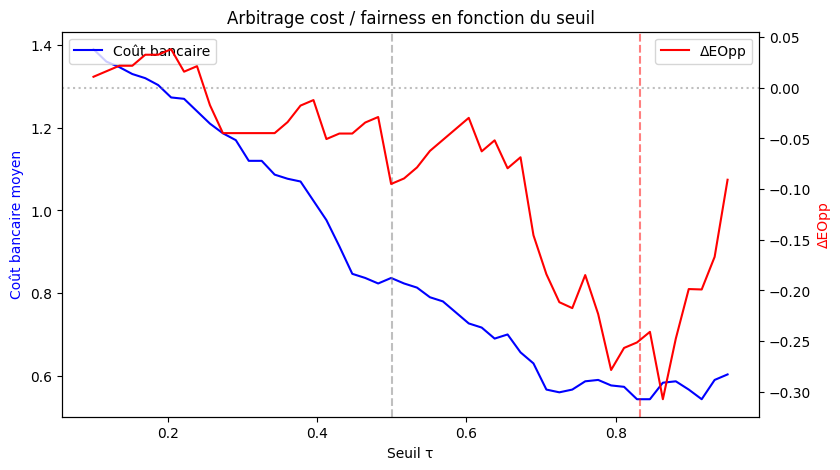

In [314]:
seuils = np.linspace(0.1, 0.95, 50)
delta_eopp = []
cout = []

for tau in seuils:
    yhat = (proba_test >= tau).astype(int)
    
    # TPR par groupe
    tpr_j = yhat[(A_test == 1) & (y_test == 1)].mean()
    tpr_a = yhat[(A_test == 0) & (y_test == 1)].mean()
    delta_eopp.append(tpr_j - tpr_a)
    
    # Coût
    fp = ((yhat == 1) & (y_test == 0)).sum()
    fn = ((yhat == 0) & (y_test == 1)).sum()
    cout.append((5*fp + fn) / len(y_test))

# Tracer en double axe
fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

ax1.plot(seuils, cout, 'b-', label='Coût bancaire')
ax2.plot(seuils, delta_eopp, 'r-', label='ΔEOpp')
ax2.axhline(0, color='gray', linestyle=':', alpha=0.5)

ax1.axvline(0.5, color='gray', linestyle='--', alpha=0.5)
ax1.axvline(0.833, color='red', linestyle='--', alpha=0.5)

ax1.set_xlabel('Seuil τ')
ax1.set_ylabel('Coût bancaire moyen', color='b')
ax2.set_ylabel('ΔEOpp', color='r')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.title('Arbitrage cost / fairness en fonction du seuil')
plt.show()

In [315]:
A_arr = np.asarray(A_test)                                                                                                               
y_arr = np.asarray(y_test)                                                                                                             
p     = np.asarray(proba_test)                                                                                                           

mask_young = (A_arr == 1)                                                                                                                
mask_old   = (A_arr == 0)                                                                                                              

def confusion_at(tau, mask):                                                                                                             
    yhat = (p[mask] >= tau).astype(int)
    y    = y_arr[mask]                                                                                                                   
    TP = int(((yhat == 1) & (y == 1)).sum())                                                                                           
    FP = int(((yhat == 1) & (y == 0)).sum())                                                                                             
    FN = int(((yhat == 0) & (y == 1)).sum())
    TN = int(((yhat == 0) & (y == 0)).sum())                                                                                             
    P, N = (y == 1).sum(), (y == 0).sum()                                                                                                
    return {"TP": TP, "FP": FP, "FN": FN, "TN": TN,
            "TPR": TP/P if P else 0,                                                                                                     
            "FPR": FP/N if N else 0,                                                                                                   
            "PPV": TP/(TP+FP) if (TP+FP) else 0,                                                                                         
            "coût": 5*FP + FN}                                                                                                           

def table_at(tau):                                                                                                                       
    df = pd.DataFrame(                                                                                                                 
        [confusion_at(tau, mask_young), confusion_at(tau, mask_old)],                                                                    
        index=pd.Index(["Jeunes", "Adultes"], name="Groupe"),
    )                                                                                                                                    
    return df.style.format({"TPR": "{:.3f}", "FPR": "{:.3f}", "PPV": "{:.3f}"}).set_caption(f"Matrice de confusion — τ = {tau:.3f}")                                                                 
                                                                                                                                        
display(table_at(5/6))                                                                                                                   
display(table_at(0.5))                                                                                                                   
                        

,TP,FP,FN,TN,TPR,FPR,PPV,coût
Groupe,,,,,,,,
Jeunes,10,1,16,17,0.385,0.056,0.909,21
Adultes,117,15,67,57,0.636,0.208,0.886,142


,TP,FP,FN,TN,TPR,FPR,PPV,coût
Groupe,,,,,,,,
Jeunes,20,9,6,9,0.769,0.500,0.690,51
Adultes,159,35,25,37,0.864,0.486,0.820,200


<h3>Analyse</h3>

<p>
Les matrices de confusion quantifient directement le compromis suggéré par les distributions de scores et la géométrie ROC précédente.
</p>

<br>

<div style="
padding-left:1.1em;
border-left:3px solid #7a8fb8;
margin:1.4em 0;
">

<b>Seuil bayésien optimal</b>

$$
\tau^\star = 0.833
$$

Le système minimise le coût bancaire, mais produit un écart important d’Equal Opportunity.

</div>

$$
TPR_{adultes} - TPR_{jeunes}
=
0.636 - 0.385
=
25.1 \text{ points}
$$

<p>
Une proportion importante de bons jeunes clients reste donc rejetée.
</p>

<br>

<div style="
padding-left:1.1em;
border-left:3px solid #b88a4a;
margin:1.8em 0;
">

<b>Seuil standard</b>

$$
\tau = 0.5
$$

Le TPR des jeunes augmente fortement :

$$
0.385 \longrightarrow 0.769
$$

mais cette amélioration s’accompagne d’une forte hausse du risque :

$$
FPR_{jeunes} :
0.056 \longrightarrow 0.500
$$

</div>

<br>

<div style="
margin-top:1.4em;
padding:1em 1.2em;
background:rgba(255,255,255,0.035);
border-left:3px solid #666;
border-radius:6px;
">

<b>Impact économique</b>

Le coût bancaire total augmente fortement :

$$
163 \longrightarrow 251
\qquad (+54\%)
$$

</div>

<br>

<p>
Pour que ce déplacement du seuil reste économiquement acceptable,
le gain en vrais positifs doit compenser le coût induit par les faux positifs supplémentaires.
</p>

<p>
Dans notre matrice bancaire, un faux positif coûte environ cinq fois plus cher qu’un faux négatif.
</p>

$$
\frac{\Delta TP}{\Delta FP} \geq 5
$$

<p>
Or ici :
</p>

$$
\frac{\Delta TP}{\Delta FP}
=
\frac{20-10}{9-1}
=
1.25
$$

<div style="
margin-top:1.6em;
padding-top:0.9em;
border-top:1px solid rgba(255,255,255,0.12);
font-size:1.03em;
line-height:1.9;
">

<b>Point important.</b>

Le déplacement vers un seuil standard permet bien de récupérer davantage de bons jeunes clients, mais au prix d’une augmentation beaucoup trop importante des profils risqués acceptés.

</div>

<h3>Focus sur les jeunes</h3>


In [316]:
ry1 = confusion_at(5/6, mask_young) 
ry2 = confusion_at(0.5, mask_young)
                                                                                                                                        
effet = pd.DataFrame({
    "τ★=0.833": [ry1["TP"], ry1["FP"], ry1["coût"]],                                                                                     
    "τ=0.6":    [ry2["TP"], ry2["FP"], ry2["coût"]],                                                                                     
    "Δ":        [ry2["TP"]-ry1["TP"], ry2["FP"]-ry1["FP"], ry2["coût"]-ry1["coût"]],                                                     
}, index=["TP (bons récupérés)", "FP (mauvais acceptés)", "Coût (5·FP+FN)"])                                                             
                                                                                                                                        
ratio = (ry2["TP"]-ry1["TP"]) / max(1, ry2["FP"]-ry1["FP"])                                                                              
                                                                                                                                        
display(effet)                                                                                                                                       


,τ★=0.833,τ=0.6,Δ
TP (bons récupérés),10,20,10
FP (mauvais acceptés),1,9,8
Coût (5·FP+FN),21,51,30


<p>
Le déplacement du seuil permet bien de récupérer davantage de bons jeunes clients :
</p>

<div style="
margin:1.1em 0;
padding-left:1.1em;
border-left:3px solid #7a8fb8;
">

$$
TP : 10 \longrightarrow 20
$$

</div>

<p>
Mais cette amélioration s’accompagne simultanément d’une forte hausse des profils risqués acceptés :
</p>

<div style="
margin:1.3em 0;
padding-left:1.1em;
border-left:3px solid #b88a4a;
">

$$
FP : 1 \longrightarrow 9
$$

</div>

<br>

<div style="
margin-top:1.2em;
padding:1em 1.15em;
background:rgba(255,255,255,0.035);
border-left:3px solid #666;
border-radius:6px;
line-height:1.9;
">

<b>Rendement du déplacement de seuil</b>

$$
\frac{\Delta TP}{\Delta FP}
=
\frac{20-10}{9-1}
=
1.25
\ll 5
$$

Le gain en vrais positifs devient donc insuffisant relativement au coût induit par les faux positifs supplémentaires.

<br><br>

Le système récupère trop peu de bons jeunes clients relativement au risque additionnel accepté.

</div>

## 5. Mitigation 

<h2>Axe A  -  Post-processing </h2>
<h3>Seuils différenciés par groupe</h3>

<p>
Les analyses précédentes ont montré que le seuil unique :
</p>

<div style="
text-align:center;
font-size:1.08em;
margin:1.4em 0 1.6em 0;
">

$$
\tau^\star = 0.833
$$

</div>

<p>
n’interagit pas de la même manière avec les distributions de scores des jeunes et des adultes.
</p>

<br>

<div style="
margin:1.2em 0;
padding-left:1.1em;
border-left:3px solid #7a8fb8;
">

<b>Adultes</b><br><br>

À seuil identique, les adultes restent relativement bien séparés.

</div>

<div style="
margin:1.4em 0;
padding-left:1.1em;
border-left:3px solid #b88a4a;
">

<b>Jeunes</b><br><br>

Les jeunes présentent au contraire une large région d’overlap où les profils
<i>good</i> et <i>bad</i> deviennent difficilement distinguables.

</div>

<br>

<div style="
margin-top:1.2em;
padding:0.95em 1.15em;
background:rgba(255,255,255,0.035);
border-left:3px solid #666;
border-radius:6px;
line-height:1.9;
">

Imposer une même frontière de décision aux deux groupes revient alors à appliquer des niveaux d’exigence statistiques différents selon la population considérée.

</div>

<br>

<div style="
margin:1.4em 0;
padding-left:1.1em;
border-left:3px solid #7a8fb8;
line-height:1.9;
">

<b>Principe de la mitigation</b><br><br>

Nous appliquons une stratégie de <i>post-processing</i> proposée par Hardt, Price &amp; Srebro (2016).

<br><br>

Le modèle de scoring reste inchangé :

seule la règle de décision finale est ajustée via des seuils spécifiques à chaque groupe.

</div>

<div style="
text-align:center;
margin:2em 0 1.8em 0;
">

<div style="
font-size:0.74em;
letter-spacing:0.12em;
text-transform:uppercase;
opacity:0.55;
margin-bottom:0.8em;
">

Contrainte fairness

</div>

$$
TPR_{jeunes} \approx TPR_{adultes}
$$

</div>

<div style="
margin-top:1.2em;
padding:0.95em 1.15em;
background:rgba(255,255,255,0.035);
border-left:3px solid #666;
border-radius:6px;
line-height:1.9;
">

La méthode de Hardt formule alors le problème comme une optimisation sous contrainte :

<ul style="margin-top:0.7em;">
<li>
la contrainte impose un niveau similaire d’Equal Opportunity entre groupes
</li>

<li style="margin-top:0.45em;">
et l’algorithme choisit, parmi les solutions satisfaisant cette contrainte, celle qui préserve au mieux l’objectif de performance
</li>
</ul>

Dans notre contexte bancaire, cet objectif n’est pas une accuracy générique mais le coût métier :

$$
C = C_{FP}\cdot FP + C_{FN}\cdot FN
$$

Les seuils sont donc sélectionnés directement sur les courbes ROC des jeunes et des adultes afin de minimiser ce coût tout en réduisant l’asymétrie de TPR observée précédemment.

</div>

<h2>Implémentation Hardt version cost-aware avec <i>fairlearn</i></h2>

<br>

<div style="
margin:1.3em 0;
padding-left:1.1em;
border-left:3px solid #7a8fb8;
line-height:1.9;
">

Nous implémentons cette stratégie avec
<code>fairlearn.ThresholdOptimizer</code>.


</div>

<div style="
margin:1.5em 0;
padding-left:1.1em;
border-left:3px solid #b88a4a;
line-height:1.9;
">
<b>Modification apportée</b>


Par défaut, <code>fairlearn</code> optimise des métriques génériques comme l’accuracy ou la balanced accuracy.

Or notre problème est gouverné par une matrice de coût asymétrique :

$$
C = C_{FP}\cdot FP + C_{FN}\cdot FN
$$

</div>


Nous étendons alors l’API interne de <i>fairlearn</i> en enregistrant notre propre fonction objectif dans <code>METRIC_DICT</code>, le registre utilisé par <code>ThresholdOptimizer</code> pour évaluer les solutions candidates.

</div>

<div style="
text-align:center;
margin:2.2em 0 2em 0;
">

<div style="
font-size:0.74em;
letter-spacing:0.12em;
text-transform:uppercase;
opacity:0.55;
margin-bottom:0.8em;
">

Métrique ajoutée

</div>

$$
\text{neg\_cost\_weighted}
=
-\frac{
C_{FP}\cdot FP + C_{FN}\cdot FN
}{n}
$$

</div>


In [317]:
np.savez("hardt_annex_data.npz",                                                                                                   
        p_nat=np.asarray(proba_test),                                                                                           
        y_te=np.asarray(y_test),                                                                                                  
        A_te=np.asarray(A_test))                                                                                                
print("Données exportées vers hardt_annex_data.npz")  

Données exportées vers hardt_annex_data.npz


In [318]:
def neg_cost_weighted(x):                                                                                                          
    return -(C_FP * x.false_positives + C_FN * x.false_negatives) / x.n                                                            
                
METRIC_DICT["neg_cost_weighted"] = neg_cost_weighted                                                                               
OBJECTIVES_FOR_SIMPLE_CONSTRAINTS.add("neg_cost_weighted")                                      

In [319]:
post_cost = ThresholdOptimizer(                                                                                                    
    estimator=baseline,                                                                      
    constraints="true_positive_rate_parity",    # ≡ Equal Opportunity                                                              
    objective="neg_cost_weighted",                                                                                                 
    prefit=True,                                                                                                                   
    predict_method="predict_proba",                                                                                                
)               
post_cost.fit(X_train, y_train, sensitive_features=A_train)
                                                                                                               
y_pred_hardt_cost = post_cost.predict(                                                                                             
    X_test, sensitive_features=A_test, random_state=RANDOM_STATE
)               

/var/folders/ms/qzgtjj3j3mn0m5lv1hk9kcr40000gn/T/ipykernel_51501/888349812.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.04, 1, 0.96])


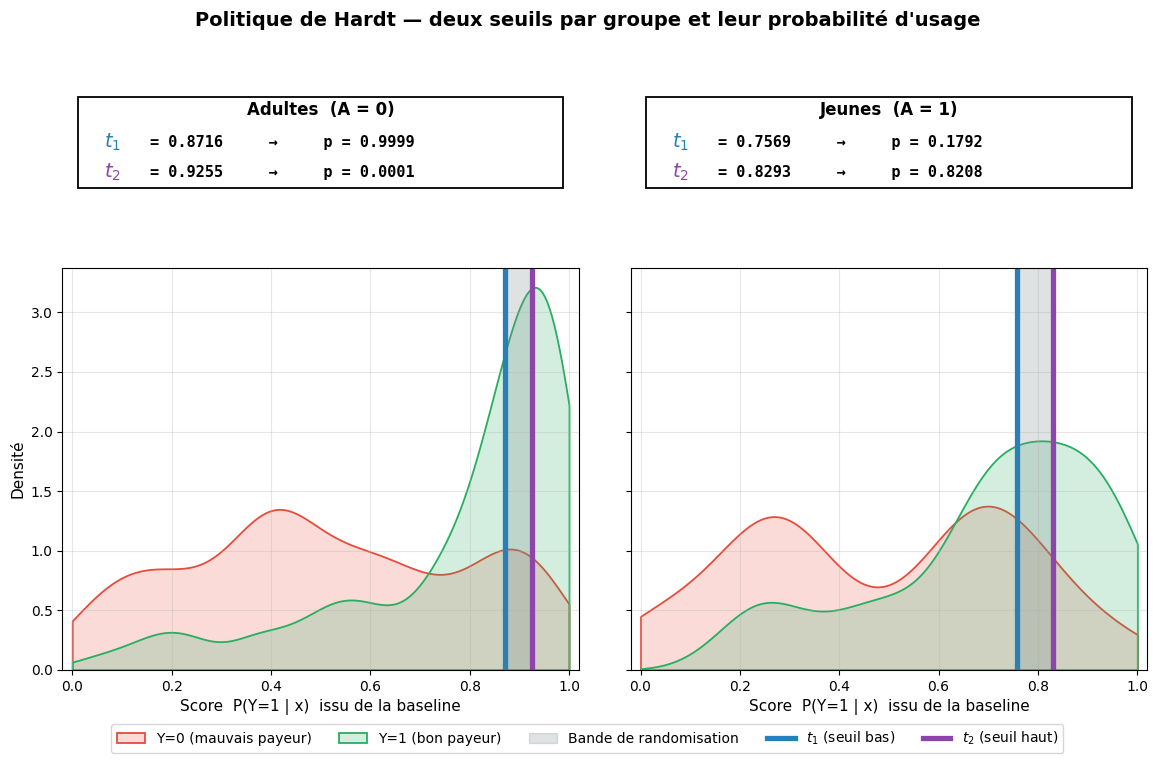

In [320]:
# Garde anti-redémarrage : si le kernel a été relancé, on re-fit ThresholdOptimizer.
if 'post_cost' not in globals():
    if 'neg_cost_weighted' not in METRIC_DICT:
        def neg_cost_weighted(x):
            return -(C_FP * x.false_positives + C_FN * x.false_negatives) / x.n
        METRIC_DICT['neg_cost_weighted'] = neg_cost_weighted
        OBJECTIVES_FOR_SIMPLE_CONSTRAINTS.add('neg_cost_weighted')
    post_cost = ThresholdOptimizer(
        estimator=baseline,
        constraints='true_positive_rate_parity',
        objective='neg_cost_weighted',
        prefit=True,
        predict_method='predict_proba',
    )
    post_cost.fit(X_train, y_train, sensitive_features=A_train)
    y_pred_hardt_cost = post_cost.predict(X_test, sensitive_features=A_test, random_state=RANDOM_STATE)

strategy = post_cost.interpolated_thresholder_.interpolation_dict                                                                  
                                                                                                                                    
A_arr     = np.asarray(A_test)
y_arr     = np.asarray(y_test)                                                                                                     
proba_arr = np.asarray(proba_test)                                                                                               

COL_T1   = "#2980B9"                                                                                                               
COL_T2   = "#8E44AD"
COL_BAND = "#7F8C8D"                                                                                                               
COL_Y0   = "#E74C3C"                                                                                                               
COL_Y1   = "#27AE60"
                                                                                                                                    
labels = {0: "Adultes  (A = 0)", 1: "Jeunes  (A = 1)"}                                                                             

fig = plt.figure(figsize=(14, 7.5))                                                                                                
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 4], hspace=0.30, wspace=0.10,                                                     
                        figure=fig)                                                                                                 

axes_card = [fig.add_subplot(gs[0, i]) for i in range(2)]                                                                          
axes_plot = [fig.add_subplot(gs[1, i]) for i in range(2)]                                                                        
axes_plot[1].sharey(axes_plot[0])                                                                                                  
                                                                                                                                
for i, a in enumerate([0, 1]):                                                                                                     
    s = strategy[a]
    t0, p0 = s.operation0.threshold, s.p0                                                                                          
    t1, p1 = s.operation1.threshold, s.p1                                                                                        
    if t0 > t1:                                                                                                                    
        t_strict, p_strict = t0, p0
        t_loose,  p_loose  = t1, p1                                                                                                
    else:                                                                                                                        
        t_strict, p_strict = t1, p1
        t_loose,  p_loose  = t0, p0                                                                                                

    # ─── Carte décision compacte ───                                                                                              
    ax_c = axes_card[i]                                                                                                          
    ax_c.axis("off")
    ax_c.set_xlim(0, 1); ax_c.set_ylim(0, 1)                                                                                       

    ax_c.add_patch(plt.Rectangle((0.03, 0.05), 0.94, 0.90,                                                                         
                                facecolor="white", edgecolor="black",                                                          
                                linewidth=1.3, zorder=1))                                                                        
                                                                                                                                
    # titre groupe                                                                                                                 
    ax_c.text(0.5, 0.83, labels[a], ha="center", va="center",
            fontsize=12, fontweight="bold", zorder=2)                                                                            
                                                                                                                                
    # ligne t1 — compacte, tout sur une ligne                                                                                      
    ax_c.text(0.08, 0.50, "$t_1$", color=COL_T1, fontsize=14,
            fontweight="bold", va="center", zorder=2)                                                                            
    ax_c.text(0.17, 0.50,                                                                                                          
            f"= {t_loose:.4f}     →     p = {p_loose:.4f}",
            fontsize=11, fontfamily="monospace", fontweight="bold",                                                              
            va="center", zorder=2)                                                                                             
                                                                                                                                    
    # ligne t2                                                                                                                   
    ax_c.text(0.08, 0.20, "$t_2$", color=COL_T2, fontsize=14,
            fontweight="bold", va="center", zorder=2)                                                                            
    ax_c.text(0.17, 0.20,
            f"= {t_strict:.4f}     →     p = {p_strict:.4f}",                                                                    
            fontsize=11, fontfamily="monospace", fontweight="bold",                                                              
            va="center", zorder=2)
                                                                                                                                    
    # ─── Plot ───                                                                                                               
    ax = axes_plot[i]                                                                                                              
    for y_val, color, lbl in [(0, COL_Y0, "Y=0 (mauvais payeur)"),                                                               
                            (1, COL_Y1, "Y=1 (bon payeur)")]:                                                                    
        sub = (A_arr == a) & (y_arr == y_val)
        if sub.sum() > 1:                                                                                                          
            sns.kdeplot(proba_arr[sub], ax=ax, color=color, fill=True,                                                             
                        alpha=0.20, linewidth=1.3, label=lbl,
                        clip=(0, 1), bw_adjust=0.7)                                                                                
                                                                                                                                
    ax.axvspan(t_loose, t_strict, color=COL_BAND, alpha=0.25,                                                                      
                label="Bande de randomisation")                                                                                   
    ax.axvline(t_loose,  color=COL_T1, ls="-", lw=3.8, label="$t_1$ (seuil bas)")                                                  
    ax.axvline(t_strict, color=COL_T2, ls="-", lw=3.8, label="$t_2$ (seuil haut)")                                                 

    ax.set_xlabel("Score  P(Y=1 | x)  issu de la baseline", fontsize=11)                                                           
    if i == 0:                                                                                                                   
        ax.set_ylabel("Densité", fontsize=11)                                                                                      
    else:                                                                                                                          
        ax.set_ylabel("")
        plt.setp(ax.get_yticklabels(), visible=False)                                                                              
    ax.grid(alpha=0.3)                                                                                                           
    ax.set_xlim(-0.02, 1.02)                                                                                                       

handles, lbls = axes_plot[0].get_legend_handles_labels()                                                                           
fig.legend(handles, lbls, loc="lower center", ncol=5,                                                                            
            fontsize=10, frameon=True, bbox_to_anchor=(0.5, -0.01))                                                                 

fig.suptitle("Politique de Hardt — deux seuils par groupe et leur probabilité d'usage",                                            
            fontweight="bold", fontsize=14, y=0.99)                                                                             
plt.tight_layout(rect=[0, 0.04, 1, 0.96])                                                                                          
plt.show()                                                                                                                         



<h3>Lecture de la figure</h3>

<p>
La méthode de Hardt apprend ici une politique de décision propre à chaque groupe.
</p>


La règle de décision alterne aléatoirement entre deux seuils :

$$
\begin{aligned}
p_0 &\rightarrow \tau_0 \\
p_1 &\rightarrow \tau_1
\end{aligned}
$$
<br>

<div style="
margin:1.2em 0;
padding-left:1.1em;
border-left:3px solid #7a8fb8;
line-height:1.9;
">

<b>Pour les `Adultes`</b>

</div>

$$
\begin{aligned}
p_0 \approx 0.0001 &: \quad s(x)>0.925 \\
p_1 \approx 0.9999 &: \quad s(x)>0.872
\end{aligned}
$$

<p>
La politique est donc pratiquement déterministe, avec un seuil proche de 0.87.
</p>

<div style="
margin:1.4em 0;
padding-left:1.1em;
border-left:3px solid #b88a4a;
line-height:1.9;
">

<b>Pour les `Jeunes`</b>

</div>

$$
\begin{aligned}
p_0 \approx 0.179 &: \quad s(x)>0.757 \\
p_1 \approx 0.821 &: \quad s(x)>0.829
\end{aligned}
$$



<div style="
margin-top:1.4em;
padding:0.9em 1.1em;
background:rgba(255,255,255,0.035);
border-left:3px solid #666;
border-radius:6px;
line-height:1.9;
">

Cette randomisation permet d’atteindre plus précisément la contrainte :

$$
TPR_{jeunes} \approx TPR_{adultes}
$$

</div>

<div style="
margin-top:1.4em;
padding-top:0.9em;
border-top:1px solid rgba(255,255,255,0.12);
font-size:1.01em;
line-height:1.9;
">

Le mécanisme géométrique de cette randomisation
(ROC, enveloppe convexe et mélange probabiliste entre seuils)
est détaillé dans l'annexe suivant si cela est nécessaire.  🔗
<a href="./ExplicationHardt.ipynb" style="
color:#e6a8c9;
text-decoration:none;
font-weight:600;
">
ExplicationHardt.ipynb
</a>  

</div>

In [321]:
proba_hardt = y_pred_hardt_cost.astype(float)
                                                                                                                                    
print(f"Acceptation globale : {y_pred_hardt_cost.mean():.3f}")                                                                     
print(f"Coût          : "                                                                                                    
    f"{(C_FP*((y_pred_hardt_cost==1)&(y_test==0)).sum() + C_FN*((y_pred_hardt_cost==0)&(y_test==1)).sum())}")
print()    

delta_EOpp_h  = compute_eopp(proba_hardt,  y_test, A_test, threshold=0.833)                                                          

Acceptation globale : 0.393
Coût          : 170

Seuil τ = 0.833
TPR jeune  : 0.462  (n=26)
TPR adulte : 0.505  (n=184)
ΔEOpp      : -0.044


<h3>Analyse des résultats</h3>

<p>
Après mitigation, le système obtient :
</p>

<div style="
margin:1.2em 0;
padding-left:1.1em;
border-left:3px solid #7a8fb8;
line-height:1.9;
">

$$
\text{Acceptation} = 0.393
\qquad
\text{Coût} = 170
$$

</div>

<p>
L’écart d’Equal Opportunity devient fortement réduit :
</p>

$$
\begin{aligned}
TPR_{jeunes} &= 0.462 \\
TPR_{adultes} &= 0.505 \\
\\
\Delta EOpp &= -0.044
\end{aligned}
$$

<div style="
margin-top:1.3em;
padding:0.9em 1.1em;
background:rgba(255,255,255,0.035);
border-left:3px solid #666;
border-radius:6px;
line-height:1.9;
">

Le coût total augmente seulement de :

$$
163 \longrightarrow 170
$$

La mitigation améliore donc fortement l’Equal Opportunity tout en conservant un surcoût limité.

</div>

<div style="
margin-top:1.6em;
padding-top:0.9em;
border-top:1px solid rgba(255,255,255,0.12);
font-size:1.01em;
line-height:1.95;
">

<b>Limites importantes.</b>

<ul style="margin-top:0.8em; line-height:1.9;">

<li>
la réduction de <i>ΔEOpp</i> provient en partie d’une baisse du <i>TPR</i> des adultes
</li>

<li style="margin-top:0.5em;">
la randomisation améliore l’équité au niveau des groupes,
mais viole une inéquité au niveau individuel :
deux profils très similaires peuvent recevoir des décisions différentes.
</li>

</ul>

</div>

<img src="idv.png" width="500">

<img src="idv2.png" width="500">

> Pour mieux comprendre ces notions , vous pouvez consulter le cours fort sympathique suivant : https://www.youtube.com/watch?v=aE9zJxms7Eg (By Miss Laclau)

<h2>Axe B  -  Pre-processing </h2>

<h3>Reweighting</h3>

<br>

<div style="
margin-top:1.2em;
padding:0.95em 1.15em;
background:rgba(255,255,255,0.035);
border-left:3px solid #666;
border-radius:6px;
line-height:1.9;
">

Cette violation du principe d’équité individuelle nous pousse alors à rechercher une méthode capable d’agir plus en amont du processus de décision.

</div>

<br>

<div style="
margin:1.4em 0;
padding-left:1.1em;
border-left:3px solid #7a8fb8;
line-height:1.9;
">

<b>Principe du Reweighting</b><br><br>

Le <i>Reweighting</i> est une technique de mitigation <i>pre-processing</i>
qui cherche à corriger les déséquilibres présents dans les données d’entraînement.

<br><br>

Chaque observation reçoit un poids dépendant de son groupe d’appartenance et de son étiquette,
afin de rééquilibrer statistiquement les différentes populations utilisées pendant l’apprentissage du modèle.

</div>

In [322]:
A_train_arr = np.asarray(A_train)                                                                                                        
y_train_arr = np.asarray(y_train)                                                                                                        
                                                                                                                                        
sample_weight = np.ones(len(y_train_arr))                                                                                                
mask_pos = (y_train_arr == 1)                                                                                                          
n_pos = mask_pos.sum()                                                                                                                 
                                                                                                                                        
for a_val in [0, 1]:
    m = mask_pos & (A_train_arr == a_val)                                                                                                
    sample_weight[m] = n_pos / (2 * m.sum())                                                                                           
                                                                                                                                        
                                                                                                                                        
for a_val, name in [(1, "Jeunes"), (0, "Adultes")]:                                                                                      
    mp = mask_pos & (A_train_arr == a_val)                                                                                             
    print(f"(A={a_val} {name:8s}, Y=1) : w = {sample_weight[mp][0]:.3f}   n = {mp.sum()}")                                               
                                                                                                

(A=1 Jeunes  , Y=1) : w = 3.952   n = 62
(A=0 Adultes , Y=1) : w = 0.572   n = 428


In [323]:
# Modèle reweighted                                                                                                               
reweighted = Pipeline([                                                                                                                
    ("preproc", preprocessor),
    ("clf", LogisticRegression(class_weight=None, max_iter=1000,
                                random_state=RANDOM_STATE)),                                                                              
])
reweighted.fit(X_train, y_train, clf__sample_weight=sample_weight)                                                                       
proba_test_rw = reweighted.predict_proba(X_test)[:, 1]       

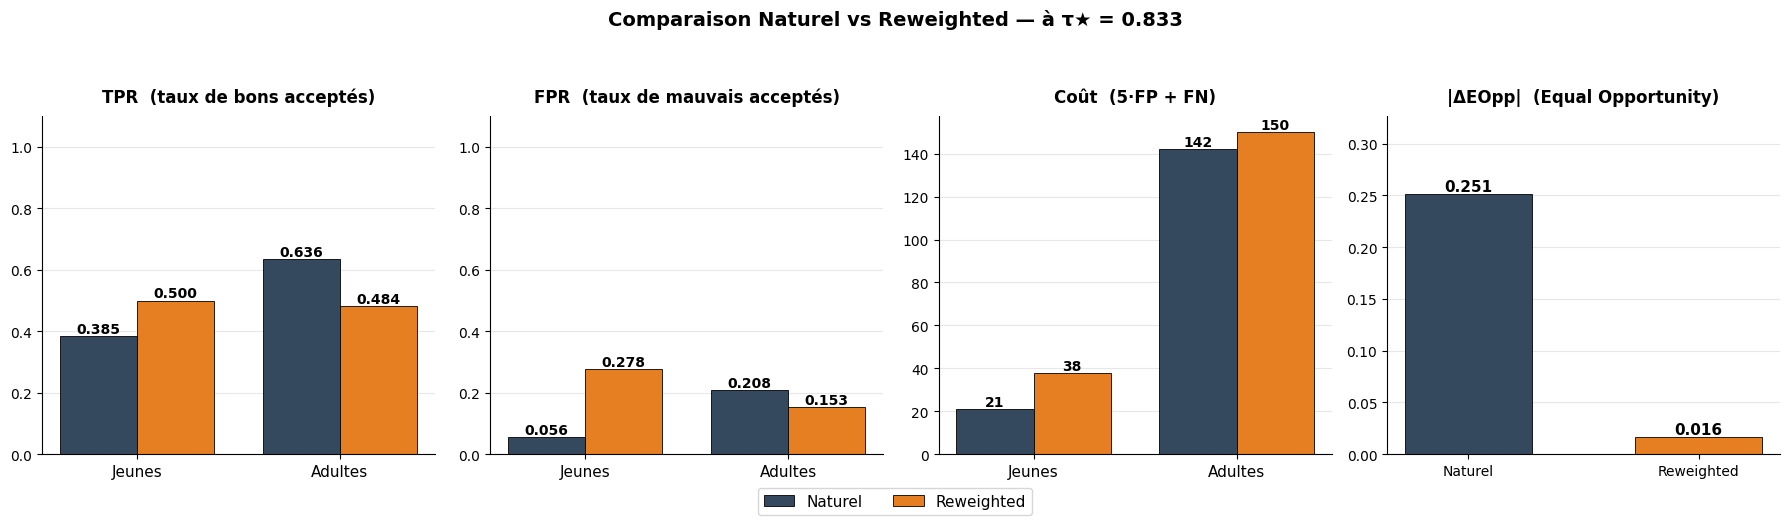

In [324]:
TAU = 5/6                                                                                                                          
A_arr = np.asarray(A_test); y_arr = np.asarray(y_test)                                                                           
                                                                                                                                    
def metrics_block(p, label):
    rows = []                                                                                                                      
    for a_val, gname in [(1, "Jeunes"), (0, "Adultes")]:                                                                         
        m = (A_arr == a_val)                                                                                                       
        yhat = (p[m] >= TAU).astype(int); y = y_arr[m]
        TP = ((yhat == 1) & (y == 1)).sum(); FP = ((yhat == 1) & (y == 0)).sum()                                                   
        FN = ((yhat == 0) & (y == 1)).sum()                                                                                        
        P, N = (y == 1).sum(), (y == 0).sum()                                                                                      
        rows.append({"Modèle": label, "Groupe": gname,                                                                             
                    "TPR": TP/P if P else 0,                                                                                    
                    "FPR": FP/N if N else 0,                                                                                      
                    "PPV": TP/(TP+FP) if (TP+FP) else 0,                                                                        
                    "coût": int(5*FP + FN)})                                                                                      
    return rows                                                                                                                    

df = pd.DataFrame(                                                                                                                 
    metrics_block(proba_test,    "Naturel") +                                                                                    
    metrics_block(proba_test_rw, "Reweighted")
).set_index(["Modèle", "Groupe"])                                                                                                  

delta_eopp = {                                                                                                                     
    m: abs(df.loc[(m, "Jeunes"), "TPR"] - df.loc[(m, "Adultes"), "TPR"])                                                         
    for m in ["Naturel", "Reweighted"]                                                                                             
}                                                                                                                                  
                                                                                                                                    
# ───── Figure : 1×4 panneaux ─────                                                                                                
COL_NAT, COL_RW = "#34495E", "#E67E22"                                                                                           
groups = ["Jeunes", "Adultes"]                                                                                                     
models = ["Naturel", "Reweighted"]
x = np.arange(len(groups))                                                                                                         
w = 0.38                                                                                                                           

fig, axes = plt.subplots(1, 4, figsize=(18, 4.8))                                                                                  
                                                                                                                                
def bar_panel(ax, metric, title, fmt="{:.3f}", ylim=None):                                                                         
    vals_nat = [df.loc[("Naturel", g),    metric] for g in groups]
    vals_rw  = [df.loc[("Reweighted", g), metric] for g in groups]                                                                 
    b1 = ax.bar(x - w/2, vals_nat, w, color=COL_NAT, label="Naturel",                                                            
                edgecolor="black", linewidth=0.6)                                                                                  
    b2 = ax.bar(x + w/2, vals_rw,  w, color=COL_RW,  label="Reweighted",                                                           
                edgecolor="black", linewidth=0.6)                                                                                  
    for bars, vals in [(b1, vals_nat), (b2, vals_rw)]:                                                                             
        for bar, v in zip(bars, vals):                                                                                           
            ax.text(bar.get_x() + bar.get_width()/2,                                                                               
                    bar.get_height(), fmt.format(v),                                                                               
                    ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels(groups, fontsize=11)                                                                      
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)                                                                  
    ax.grid(axis="y", alpha=0.3)                                                                                                   
    if ylim is not None:                                                                                                         
        ax.set_ylim(*ylim)                                                                                                         
    ax.set_axisbelow(True)                                                                                                       
    for spine in ["top", "right"]:                                                                                                 
        ax.spines[spine].set_visible(False)
                                                                                                                                    
bar_panel(axes[0], "TPR",  "TPR  (taux de bons acceptés)",   ylim=(0, 1.1))                                                        
bar_panel(axes[1], "FPR",  "FPR  (taux de mauvais acceptés)", ylim=(0, 1.1))
bar_panel(axes[2], "coût", "Coût  (5·FP + FN)", fmt="{:.0f}")                                                                      
                                                                                                                                
# Panel 4 : |ΔEOpp| par modèle                                                                                                     
ax = axes[3]                                                                                                                     
deopp_vals = [delta_eopp["Naturel"], delta_eopp["Reweighted"]]                                                                     
bars = ax.bar(models, deopp_vals,                                                                                                
            color=[COL_NAT, COL_RW], edgecolor="black", linewidth=0.6,                                                           
            width=0.55)
for bar, v in zip(bars, deopp_vals):                                                                                               
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),                                                                     
            f"{v:.3f}", ha="center", va="bottom",
            fontsize=11, fontweight="bold")                                                                                        
ax.set_title("|ΔEOpp|  (Equal Opportunity)", fontsize=12, fontweight="bold", pad=10)                                             
ax.set_ylim(0, max(deopp_vals) * 1.30)                                                                                             
ax.grid(axis="y", alpha=0.3)                                                                                                     
ax.set_axisbelow(True)                                                                                                             
for spine in ["top", "right"]:                                                                                                     
    ax.spines[spine].set_visible(False)
                                                                                                                                    
# ───── Légende commune Naturel / Reweighted ─────                                                                               
handles, lbls = axes[0].get_legend_handles_labels()
fig.legend(handles, lbls, loc="lower center", ncol=2, fontsize=11,                                                                 
            frameon=True, bbox_to_anchor=(0.5, -0.04))
                                                                                                                                    
fig.suptitle(f"Comparaison Naturel vs Reweighted — à τ★ = {TAU:.3f}",                                                            
            fontweight="bold", fontsize=14, y=1.03)                                                                               
plt.tight_layout(rect=[0, 0.02, 1, 0.97])                                                                                          
plt.show()

<h3>Analyse</h3>

<p>
Le reweighting réduit fortement l’écart d’Equal Opportunity, qui devient presque nul :
</p>

<div style="
margin:1.2em 0;
padding-left:1.1em;
border-left:3px solid #7a8fb8;
line-height:1.9;
">

$$
|\Delta EOpp| :
0.251 \longrightarrow 0.016
$$

</div>

<p>
Cette amélioration provient principalement d’un rééquilibrage global des performances entre groupes.
</p>

<div style="
margin:1.4em 0;
padding-left:1.1em;
border-left:3px solid #b88a4a;
line-height:1.9;
">

Le modèle augmente le taux d’acceptation des jeunes solvables, mais au prix :

<ul style="margin-top:0.7em;">

<li>
d’une hausse importante des faux positifs chez les jeunes.
</li>

<li style="margin-top:0.45em;">
d’une baisse du taux de détection des profils solvables adultes.
</li>

</ul>

</div>

<p>
Le comportement du modèle devient ainsi plus homogène entre groupes, sans supprimer réellement le chevauchement observé précédemment chez les jeunes, que l'on analysera à la figure suivante .
</p>

<hr style="
margin:2.6em 0;
border:none;
border-top:1px solid rgba(255,255,255,0.10);
">

<p>
Le coût total augmente néanmoins de manière relativement modérée :
</p>

<div style="
margin-top:1.2em;
padding:0.95em 1.15em;
background:rgba(255,255,255,0.035);
border-left:3px solid #666;
border-radius:6px;
line-height:1.9;
">

$$
163 \longrightarrow 188
\qquad (+15\%)
$$

</div>

<p>
Ce résultat contraste avec l’explosion du coût observée lors du simple déplacement global du seuil.
</p>


Cette mitigation est une alternative à la mitigation Hardt, qui garentie à la fois l'équité au niveau des groupes et au niveau individuel.


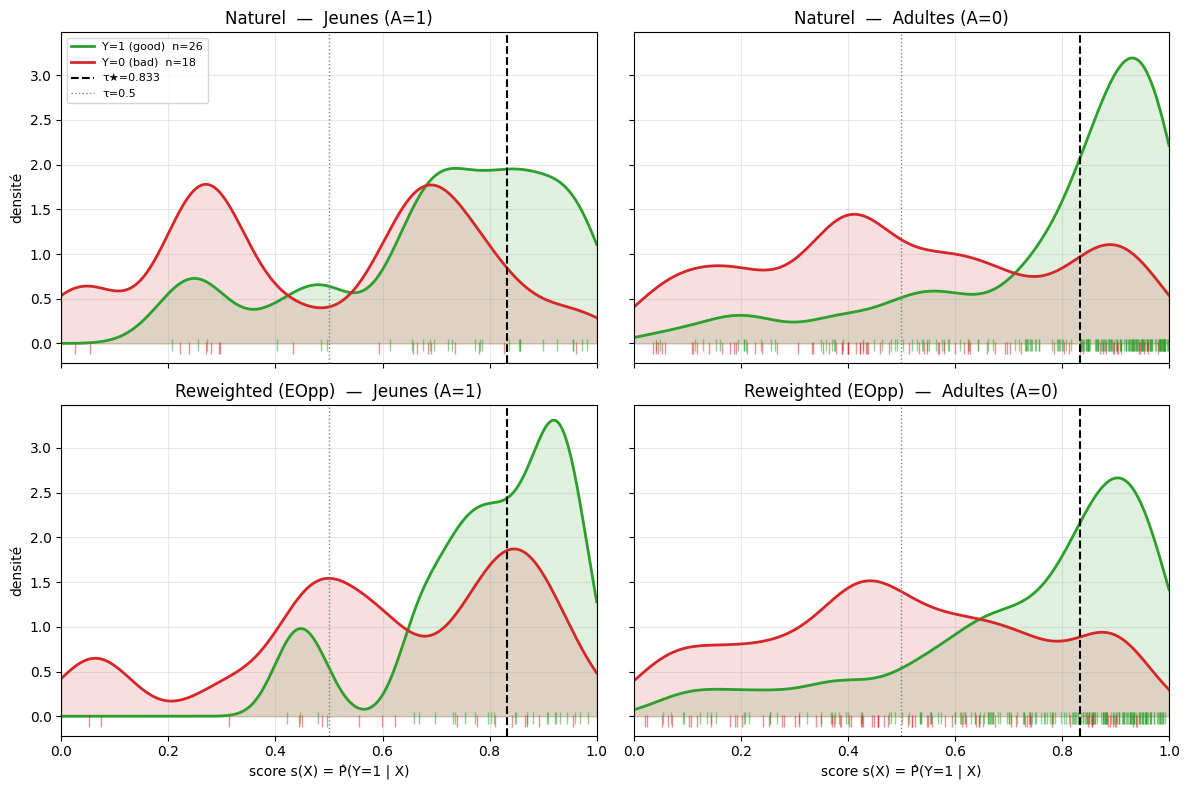

In [325]:
A_arr = np.asarray(A_test)                                                                                                               
y_arr = np.asarray(y_test)
                                                                                                                                        
TAU = 5/6
groups = {1: "Jeunes (A=1)", 0: "Adultes (A=0)"}                                                                                         
colors_y = {1: "C2", 0: "C3"}
labels_y = {1: "Y=1 (good)", 0: "Y=0 (bad)"}                                                                                             
xs = np.linspace(0, 1, 400)
                                                                                                                                        
models = [("Naturel", proba_test), ("Reweighted (EOpp)", proba_test_rw)]                                                                 
                                                                                                                                        
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)                                                                
                
for row, (mname, p) in enumerate(models):                                                                                                
    for col, (g_val, g_name) in enumerate(groups.items()):
        ax = axes[row, col]
        mask_g = (A_arr == g_val)                                                                                                        
        for y_val in [1, 0]:
            mask = mask_g & (y_arr == y_val)                                                                                             
            scores = p[mask]
            kde = gaussian_kde(scores, bw_method=0.25)                                                                                   
            ax.plot(xs, kde(xs), color=colors_y[y_val], lw=2,
                    label=f"{labels_y[y_val]}  n={mask.sum()}")                                                                          
            ax.fill_between(xs, kde(xs), alpha=0.15, color=colors_y[y_val])
            ax.plot(scores, np.full_like(scores, -0.05) + (0.03 if y_val == 1 else 0),                                                   
                    "|", color=colors_y[y_val], alpha=0.5, markersize=8)
        ax.axvline(TAU, color="k", ls="--", lw=1.5, label=f"τ★={TAU:.3f}")                                                               
        ax.axvline(0.5, color="gray", ls=":", lw=1, label="τ=0.5")                                                                       
        ax.set_title(f"{mname}  —  {g_name}")                                                                                            
        ax.set_xlim(0, 1)                                                                                                                
        ax.grid(alpha=0.3)
        if row == 1:                                                                                                                     
            ax.set_xlabel("score s(X) = P̂(Y=1 | X)")                                                                                     
        if col == 0:
            ax.set_ylabel("densité")                                                                                                     
        if row == 0 and col == 0:                                                                                                        
            ax.legend(fontsize=8, loc="upper left")
                                                                                                                                        
plt.tight_layout()
plt.show()
                                                                                                                                                                                  
                                                                                        

<h3>Analyse</h3>

<p>
Le reweighting modifie bien la structure des scores, en particulier chez les jeunes où les distributions sont globalement déplacées vers des scores plus élevés.
</p>

<div style="
margin:1.4em 0;
padding-left:1.1em;
border-left:3px solid #b88a4a;
line-height:1.9;
">

Le chevauchement entre profils <i>Y=1</i> et <i>Y=0</i> reste toutefois important dans la région critique autour du seuil opérationnel :

$$
\tau^\star = 0.833
$$

</div>

<p>
L’amélioration des métriques de fairness semble ainsi provenir davantage d’une translation globale des scores que d’une réelle amélioration de la séparabilité locale entre profils solvables et risqués.
</p>

<div style="
margin-top:1.5em;
padding:0.95em 1.15em;
background:rgba(255,255,255,0.035);
border-left:3px solid #666;
border-radius:6px;
line-height:1.9;
">

Cette observation motive une analyse plus fine du pouvoir discriminant du modèle :

<ul style="margin-top:0.8em;">

<li>
quantification statistique du chevauchement 
</li>

<li style="margin-top:0.45em;">
analyse SHAP des variables responsables des déplacements de score.
</li>

</ul>

</div>

## 7.1 Quantification du chevauchement (KS)

<div style="margin-top:2.2em;">

<div style="
font-size:0.72em;
letter-spacing:0.14em;
text-transform:uppercase;
opacity:0.5;
margin-bottom:0.55em;
">

Analyse des distributions de scores

</div>

<h3 style="
margin-top:0;
line-height:1.45;
max-width:900px;
">

Chevauchement des distributions chez les jeunes et affaiblissement de la capacité discriminante dans la zone critique de décision

</h3>

</div>

<h3 style="
margin-top:0;
line-height:1.45;
max-width:900px;
">
Analyse quantitvative du chevauchement

</h3>


Afin de confirmer quantitativement cette observation, nous utilisons le test de Kolmogorov–Smirnov (KS), qui mesure l’écart maximal entre les fonctions de répartition empiriques des deux distributions de scores.

Soient :
- $F_1$ : la distribution empirique des scores des bons emprunteurs,
- $F_0$ : celle des mauvais emprunteurs.

La statistique KS est définie par :

$$
D = \sup_{s \in [0,1]} |F_1(s) - F_0(s)|
$$

**Hypothèses**

- $H_0$ : les scores des $Y=1$ et des $Y=0$ suivent la même loi dans le sous-groupe (le modèle ne sépare pas bons et mauvais clients).
- $H_1$ : les deux lois diffèrent.

*Une p-value $< 0{,}05$ conduit à rejeter $H_0$ : la séparation observée n'est pas attribuable au hasard d'échantillonnage.*

=== Test KS : separation good vs bad par groupe age ===


,Groupe,n (Y=1),n (Y=0),D (KS),p-value,Decision H0 (alpha=0.05)
0,Jeunes (A=1),26,18,0.393,0.0542,non-rejet
1,Adultes (A=0),184,72,0.500,2.44e-12,rejet


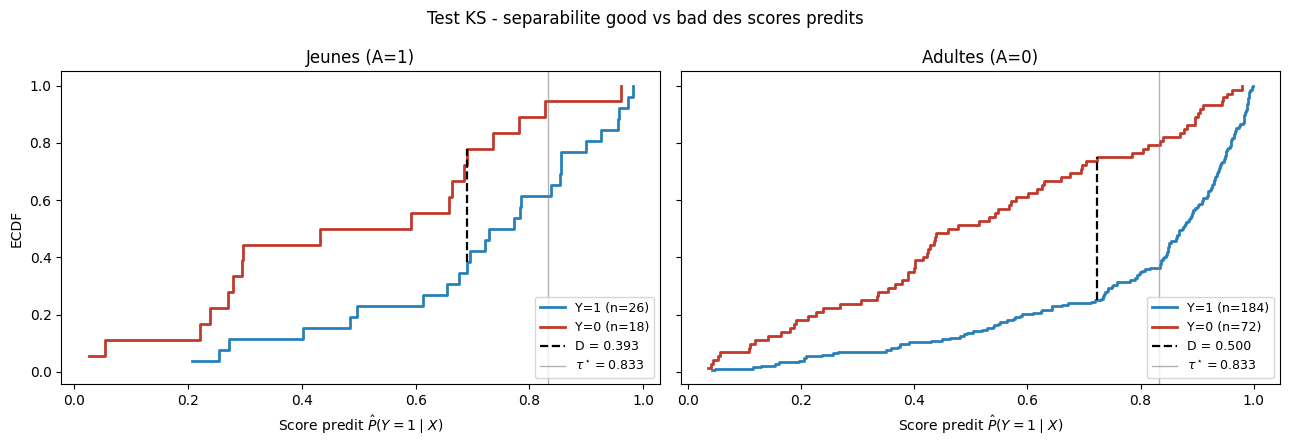

In [326]:
from scipy.stats import ks_2samp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

A = np.asarray(A_test); y = np.asarray(y_test)
mask_young = (A == 1); mask_adult = (A == 0)

# Scores predits P(Y=1 | X) par (groupe age, label)
s_y_good = proba_test[mask_young & (y == 1)]
s_y_bad  = proba_test[mask_young & (y == 0)]
s_a_good = proba_test[mask_adult & (y == 1)]
s_a_bad  = proba_test[mask_adult & (y == 0)]

# Test KS a deux echantillons (bilateral)
ks_young = ks_2samp(s_y_good, s_y_bad)
ks_adult = ks_2samp(s_a_good, s_a_bad)

res = pd.DataFrame({
    'Groupe':                    ['Jeunes (A=1)', 'Adultes (A=0)'],
    'n (Y=1)':                   [len(s_y_good),  len(s_a_good)],
    'n (Y=0)':                   [len(s_y_bad),   len(s_a_bad)],
    'D (KS)':                    [round(ks_young.statistic, 3), round(ks_adult.statistic, 3)],
    'p-value':                   [f'{ks_young.pvalue:.3g}',     f'{ks_adult.pvalue:.3g}'],
    'Decision H0 (alpha=0.05)':  ['rejet' if ks_young.pvalue < 0.05 else 'non-rejet',
                                  'rejet' if ks_adult.pvalue < 0.05 else 'non-rejet'],
})
print('=== Test KS : separation good vs bad par groupe age ===')
display(res)

# Visualisation : D = ecart vertical maximal entre les deux ECDF
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

def plot_ecdf(ax, s_good, s_bad, title, D):
    g = np.sort(s_good); b = np.sort(s_bad)
    Fg = np.arange(1, len(g)+1) / len(g)
    Fb = np.arange(1, len(b)+1) / len(b)
    ax.step(g, Fg, where='post', color='#2980B9', lw=2, label=f'Y=1 (n={len(g)})')
    ax.step(b, Fb, where='post', color='#C0392B', lw=2, label=f'Y=0 (n={len(b)})')
    grid = np.sort(np.unique(np.concatenate([g, b])))
    Fg_g = np.searchsorted(g, grid, side='right') / len(g)
    Fb_g = np.searchsorted(b, grid, side='right') / len(b)
    i = int(np.argmax(np.abs(Fg_g - Fb_g)))
    ax.vlines(grid[i], min(Fg_g[i], Fb_g[i]), max(Fg_g[i], Fb_g[i]),
              color='black', lw=1.6, linestyles='--', label=f'D = {D:.3f}')
    ax.axvline(0.833, color='gray', lw=1, alpha=0.6, label=r'$\tau^\star = 0.833$')
    ax.set_title(title); ax.set_xlabel(r'Score predit $\hat{P}(Y=1\mid X)$')
    ax.legend(loc='lower right', fontsize=9)

plot_ecdf(axes[0], s_y_good, s_y_bad, 'Jeunes (A=1)',  ks_young.statistic)
plot_ecdf(axes[1], s_a_good, s_a_bad, 'Adultes (A=0)', ks_adult.statistic)
axes[0].set_ylabel('ECDF')
plt.suptitle('Test KS - separabilite good vs bad des scores predits')
plt.tight_layout(); plt.show()

<ul style="line-height:1.9;">

<li style="margin-bottom:1em;">
Chez les <b>adultes</b>, l’hypothèse nulle est rejetée.  
Le modèle est donc capable de discriminer les profils pour ce groupe.
</li>

<li>
Chez les <b>jeunes</b>, on ne rejette pas H_0.  
Ce résultat ne suffit toutefois pas à conclure à une absence de séparabilité des distributions.
</li>

</ul>

<br>

<p style="line-height:1.9;">
La statistique de Kolmogorov–Smirnov reste principalement sensible à l’écart maximal observé sur l’ensemble du support des scores.  
Elle peut donc masquer une ambiguïté localisée dans une région spécifique.
</p>

<br>

<div style="
text-align:center;
margin:1.5em 0;
line-height:1.8;
">

$$
D = 0.393
\qquad \text{sur} \qquad [0.5 \; ; \; 0.85]
$$

</div>

<p style="line-height:1.9;">
Cette région présente une forte superposition des distributions de scores,
ce qui suggère une difficulté de discrimination locale entre profils
<i>good</i> et <i>bad</i>.
</p>

<br>

<div style="
color:#6FCF97;
line-height:1.9;
">

Nous nous limiterons dans la suite à une analyse visuelle des densités de scores afin d’évaluer le chevauchement local dans cette zone critique.

</div>

> La présence d’un chevauchement local soulève alors une question centrale ! 

Cette ambiguïté provient-elle :

- D’une limitation du modèle utilisé, 
ou reflète-t-elle 
- D'une absence réelle d’information discriminante dans les variables disponibles ?

<h1 style="
color:#D4B24C;
margin-top:1.6em;
margin-bottom:0.6em;
font-weight:600;
">

7.2 Le problème est-il lié à l'expressivité du modèle ?

</h1>

<p style="line-height:1.9;">

Afin de distinguer ces deux hypothèses, nous comparons les scores produits par :

</p>

<ul style="line-height:1.9; margin-top:0.6em;">

<li>
une <b>régression logistique</b>, modèle linéaire à faible capacité,
</li>

<li>
et <b>XGBoost</b>, modèle non linéaire beaucoup plus expressif.
</li>

</ul>

<br>

<p style="line-height:1.9;">

L’idée est la suivante,  si les mêmes individus restent ambigus pour les deux modèles,
alors le chevauchement observé ne peut pas être attribué uniquement à la simplicité d’une frontière linéaire.

<br><br>

Il suggère au contraire une ambiguïté plus profonde dans l’information portée par les variables disponibles.

</p>

In [327]:
from xgboost import XGBClassifier                                                                                         
from sklearn.pipeline import Pipeline                                                                                   
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import numpy as np                                                                                                        

cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()                                         
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()                                                    
                                                                                                                        
prep_xgb = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),                                              
    ('num', StandardScaler(), num_cols),                                                                                  
])
                                                                                                                        
xgb_pipe = Pipeline([                                                                                                   
    ('prep', prep_xgb),
    ('clf', XGBClassifier(eval_metric="logloss", random_state=42)),                                                       
])
xgb_pipe.fit(X_train, y_train)                                                                                            
proba_test_xgb = xgb_pipe.predict_proba(X_test)[:, 1]     

Spearman(s_LR, s_XGB) chez les jeunes  : rho = 0.638 (p = 3.18e-06)
Spearman(s_LR, s_XGB) chez les adultes : rho = 0.775  (reference)


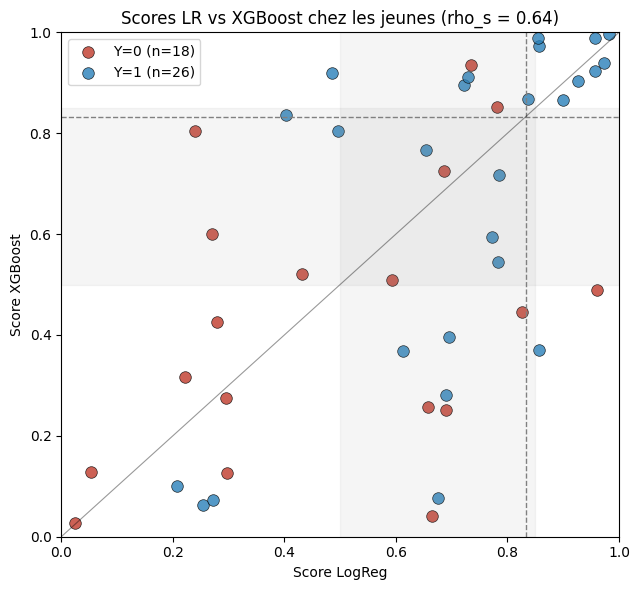

In [328]:
from scipy.stats import spearmanr

s_lr_y  = proba_test[mask_young]
s_xgb_y = proba_test_xgb[mask_young]
y_y     = y[mask_young]

rho_y, p_rho_y = spearmanr(s_lr_y,  s_xgb_y)
rho_a, _       = spearmanr(proba_test[~mask_young], proba_test_xgb[~mask_young])
print(f'Spearman(s_LR, s_XGB) chez les jeunes  : rho = {rho_y:.3f} (p = {p_rho_y:.3g})')
print(f'Spearman(s_LR, s_XGB) chez les adultes : rho = {rho_a:.3f}  (reference)')

fig, ax = plt.subplots(figsize=(6.5, 6))
mg = (y_y == 1); mb = (y_y == 0)
ax.scatter(s_lr_y[mb], s_xgb_y[mb], s=70, alpha=0.8,
           color='#C0392B', edgecolor='black', linewidth=0.5, label=f'Y=0 (n={mb.sum()})')
ax.scatter(s_lr_y[mg], s_xgb_y[mg], s=70, alpha=0.8,
           color='#2980B9', edgecolor='black', linewidth=0.5, label=f'Y=1 (n={mg.sum()})')
# Zone critique sur les deux axes
ax.axvspan(0.5, 0.85, color='gray', alpha=0.08)
ax.axhspan(0.5, 0.85, color='gray', alpha=0.08)
ax.axvline(0.833, color='gray', lw=1, ls='--')
ax.axhline(0.833, color='gray', lw=1, ls='--')
ax.plot([0, 1], [0, 1], color='black', lw=0.8, alpha=0.4)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel('Score LogReg'); ax.set_ylabel('Score XGBoost')
ax.set_title(f'Scores LR vs XGBoost chez les jeunes (rho_s = {rho_y:.2f})')
ax.legend(loc='upper left')
plt.tight_layout(); plt.show()

<h4 style="margin-bottom:0.8em;">
Description de la figure
</h4>

<p style="line-height:1.9;">

Chaque point représente un jeune individu, positionné selon :

</p>

<ul style="line-height:1.9; margin-top:0.5em;">

<li>
son score prédit par la régression logistique (axe horizontal),
</li>

<li>
et son score prédit par XGBoost (axe vertical).
</li>

</ul>

<p style="line-height:1.9; margin-top:1em;">
La diagonale correspond à un accord parfait entre les deux modèles.
</p>

<h4 style="margin-bottom:1em;">
Analyse
</h4>

<p style="line-height:1.9;">
La comparaison met en évidence trois régions principales.
</p>

<br>

<div style="
padding-left:1em;
border-left:3px solid #4A90E2;
margin-bottom:1.6em;
line-height:1.9;
">

<span><b> Zone de confiance positive</b> = Les individus recevant des scores élevés sous régression logistique
reçoivent également des scores élevés sous XGBoost.
Ces profils correspondent majoritairement à de bons emprunteurs.

</div>

<div style="
padding-left:1em;
border-left:3px solid #D64545;
margin-bottom:1.6em;
line-height:1.9;
">

<span><b> Zone de confiance négative</b> =  Les individus fortement risqués sous régression logistique
restent également classés comme mauvais sous XGBoost.
Les deux modèles convergent donc sur les profils clairement défavorables.

</div>

<div style="
padding-left:1em;
border-left:3px solid #7A7A7A;
margin-bottom:1.8em;
line-height:1.9;
">

<span><b> Zone d’ambiguïté</b> = La région intermédiaire reste largement ambiguë pour les deux modèles.
Les individus situés dans cette zone sous régression logistique
demeurent majoritairement proches de cette même région sous XGBoost.

</div>


> Ainsi, malgré sa capacité non linéaire beaucoup plus expressive,
XGBoost ne parvient pas à résoudre les ambiguïtés présentes dans cette région critique. Ces résultats suggèrent que le chevauchement observé chez les jeunes
ne provient pas uniquement d’une limitation structurelle du modèle linéaire,
mais plus probablement d’une difficulté informationnelle locale liée aux variables disponibles.


#### Qauntifions le chevauchement

On définit la zone critique $Z = [0{,}5\,;\,0{,}85]$, autour du seuil $\tau^\star = 0{,}833$ où le chevauchement est le plus dommageable opérationnellement. </br> </br> Un jeune individu est *doublement ambigu* si :

$$
s_{\text{LR}}(x) \in Z \quad \textbf{et} \quad s_{\text{XGB}}(x) \in Z.
$$


In [329]:
Z_LOW, Z_HIGH = 0.5, 0.85

in_zone_lr  = (proba_test     >= Z_LOW) & (proba_test     <= Z_HIGH)
in_zone_xgb = (proba_test_xgb >= Z_LOW) & (proba_test_xgb <= Z_HIGH)
in_zone_both = in_zone_lr & in_zone_xgb

rows = []
for label, lab_name in [(1, 'Bons jeunes (Y=1)'), (0, 'Mauvais jeunes (Y=0)')]:
    sub   = mask_young & (y == label)
    n_tot = int(sub.sum())
    n_lr   = int((sub & in_zone_lr).sum())
    n_xgb  = int((sub & in_zone_xgb).sum())
    n_both = int((sub & in_zone_both).sum())
    rows.append({
        'Sous-groupe':         lab_name,
        'n total':             n_tot,
        'dans Z (LR)':         f'{n_lr}/{n_tot} ({n_lr/n_tot:.0%})',
        'dans Z (XGB)':        f'{n_xgb}/{n_tot} ({n_xgb/n_tot:.0%})',
        'dans Z (LR & XGB)':   f'{n_both}/{n_tot} ({n_both/n_tot:.0%})',
    })
print(f'=== Cas ambigus chez les jeunes : score dans Z = [{Z_LOW} ; {Z_HIGH}] ===')
display(pd.DataFrame(rows))

=== Cas ambigus chez les jeunes : score dans Z = [0.5 ; 0.85] ===


,Sous-groupe,n total,dans Z (LR),dans Z (XGB),dans Z (LR & XGB)
0,Bons jeunes (Y=1),26,11/26 (42%),6/26 (23%),4/26 (15%)
1,Mauvais jeunes (Y=0),18,8/18 (44%),5/18 (28%),2/18 (11%)


- Le tableau confirme quantitativement que la région de chevauchement concerne une proportion importante de jeunes emprunteurs dans les deux classes.

- Une fraction non négligeable des bons et mauvais profils reçoit des scores intermédiaires simultanément sous régression logistique et sous XGBoost  $Z_{\text{LR}} \cap Z_{\text{XGB}}$  . 

Renforcant ainsi l'hypothèse d'une difficulté informationnelle évoquée plus haut.

<h2 style="margin-bottom:0.8em;">
Analyse de la région d’overlap chez les jeunes
</h2>

<p style="line-height:1.9;">

Les analyses précédentes ont montré que le chevauchement observé chez les jeunes
persiste même lorsque la régression logistique est remplacée
par un modèle non linéaire beaucoup plus expressif.

Cette ambiguïté semble donc davantage liée à l’information portée par les variables disponibles
qu’à une simple limitation structurelle du modèle.

</p>

<br>

<p style="line-height:1.9;">

La question devient alors :

</p>

<div style="
margin:1em 0 1.4em 0;
padding-left:1em;
border-left:3px solid #B8B8B8;
font-style:italic;
line-height:1.9;
">

Comment cette ambiguïté se construit-elle dans les scores produits par le modèle ?

</div>

<p style="line-height:1.9; margin-bottom:0.8em;">

L’objectif est d’analyser plus précisément la région d’overlap afin de répondre aux questions suivantes :

</p>

<ol style="line-height:2; padding-left:1.2em;">

<li>
Quelles variables dominent le score dans la région d’overlap ?
</li>

<li>
Lesquelles contribuent de manière similaire aux bons et aux mauvais jeunes
(<i>signal confus</i>, ambiguïté informationnelle) ?
</li>

<li>
Quelles variables continuent malgré tout à séparer les deux groupes ?
</li>

<li>
Le comportement des variables dans l’overlap diffère-t-il de celui observé dans les régions fiables ?
</li>

</ol>

#### Définition du périmètre d'analyse

In [330]:
import os
os.makedirs('shap_outputs', exist_ok=True)

S_LOW, S_HIGH = 0.5, 0.85

score = np.asarray(proba_test)
A     = np.asarray(A_test)
y     = np.asarray(y_test)

is_young   = (A == 1)
in_overlap = (score >= S_LOW) & (score <= S_HIGH)
in_bad_rel = (score < S_LOW)
in_good_rel = (score > S_HIGH)

young_bad_reliable  = is_young & (y == 0) & in_bad_rel
young_good_reliable = is_young & (y == 1) & in_good_rel
young_good_overlap  = is_young & (y == 1) & in_overlap
young_bad_overlap   = is_young & (y == 0) & in_overlap

overlap_mask  = is_young & in_overlap
reliable_mask = is_young & (in_bad_rel | in_good_rel)

populations = {
    'young_good_reliable': young_good_reliable,
    'young_good_overlap':  young_good_overlap,
    'young_bad_overlap':   young_bad_overlap,
    'young_bad_reliable':  young_bad_reliable,
}

pop_summary = pd.DataFrame([
    {'population': name, 'n': int(mask.sum()),
     'score_min': float(score[mask].min()) if mask.sum() else np.nan,
     'score_max': float(score[mask].max()) if mask.sum() else np.nan,
     'score_mean': float(score[mask].mean()) if mask.sum() else np.nan}
    for name, mask in populations.items()
]).set_index('population')
display(pop_summary.round(3))



,n,score_min,score_max,score_mean
population,,,,
young_good_reliable,9,0.854,0.982,0.918
young_good_overlap,11,0.613,0.837,0.724
young_bad_overlap,8,0.593,0.827,0.704
young_bad_reliable,9,0.025,0.432,0.235


## 8. Explicabilité SHAP de la zone d'overlap


### 8.1 Périmètre et 4 sous-populations


<p style="line-height:1.9;">

Nous distinguons trois régions principales :

</p>

<ul style="line-height:2; margin-top:0.7em;">

<li>
<b>Bad reliable</b> : s(X) appartient à [0 , 0.5[ 
</li>

<li>
<b>Overlap</b> :  s(X) appartient à [0.5 , 0.85[
</li>

<li>
<b>Good reliable</b> : $s(X) appartient à [0.85 , 1]
</li>

</ul>

<br>

<p style="line-height:1.9;">

Nous considérons ensuite quatre sous-groupes restreints aux jeunes ($A = 1$) :

</p>

<ul style="line-height:2; margin-top:0.7em;">

<li><code>young_bad_reliable</code></li>

<li><code>young_good_reliable</code></li>

<li><code>young_good_overlap</code></li>

<li><code>young_bad_overlap</code></li>

</ul>

### 8.2 SHAP moyen par population


#### Comment quantifier la contribution des variables au score d’un individu ?

Les valeurs SHAP permettent de décomposer localement le score d’un individu en contributions attribuées aux différentes variables.

Pour un individu $x$, on écrit :

$$
f(x)=\phi_0+\sum_j \phi_j(x)
$$

où :
- $\phi_0$ est la valeur moyenne de référence du modèle 
- $\phi_j(x)$ est la contribution de la variable $j$ pour l’individu $x$

Dans notre cas, le modèle est une régression logistique. Le score de probabilité est :

$$
s(x)=P(Y=1\mid X=x)
$$

mais la régression logistique est additive dans l’espace des **log-odds** :

$$
f(x)=\log\frac{s(x)}{1-s(x)}
=
\beta_0+\sum_j \beta_jx_j
$$

Les valeurs SHAP expliquent donc le score dans cet espace log-odds :
- $\phi_j(x)>0$ pousse le score vers la classe *good*
- $\phi_j(x)<0$ pousse le score vers la classe *bad*

In [331]:
import shap

preproc = baseline.named_steps['preproc']
clf     = baseline.named_steps['clf']

X_train_t = preproc.transform(X_train)
X_test_t  = preproc.transform(X_test)
if hasattr(X_train_t, 'toarray'):
    X_train_t = X_train_t.toarray()
    X_test_t  = X_test_t.toarray()

feature_names = list(preproc.get_feature_names_out())

explainer  = shap.LinearExplainer(clf, X_train_t)
shap_test  = explainer.shap_values(X_test_t)
base_value = float(np.atleast_1d(explainer.expected_value)[0])

logit_pred = np.log(score / (1 - score))
shap_sum   = base_value + shap_test.sum(axis=1)
add_err    = np.max(np.abs(logit_pred - shap_sum))
print(f'Base value (φ₀) : {base_value:+.3f}  (log-odds)')
print(f'Erreur additivité max : {add_err:.2e}')


Base value (φ₀) : +1.362  (log-odds)
Erreur additivité max : 4.62e-14


L'erreur d'additivité de l'ordre de $10^{-10}$ confirme que la décomposition est exacte : tout ce qui suit peut être lu comme une réécriture parfaite des log-odds prédits.


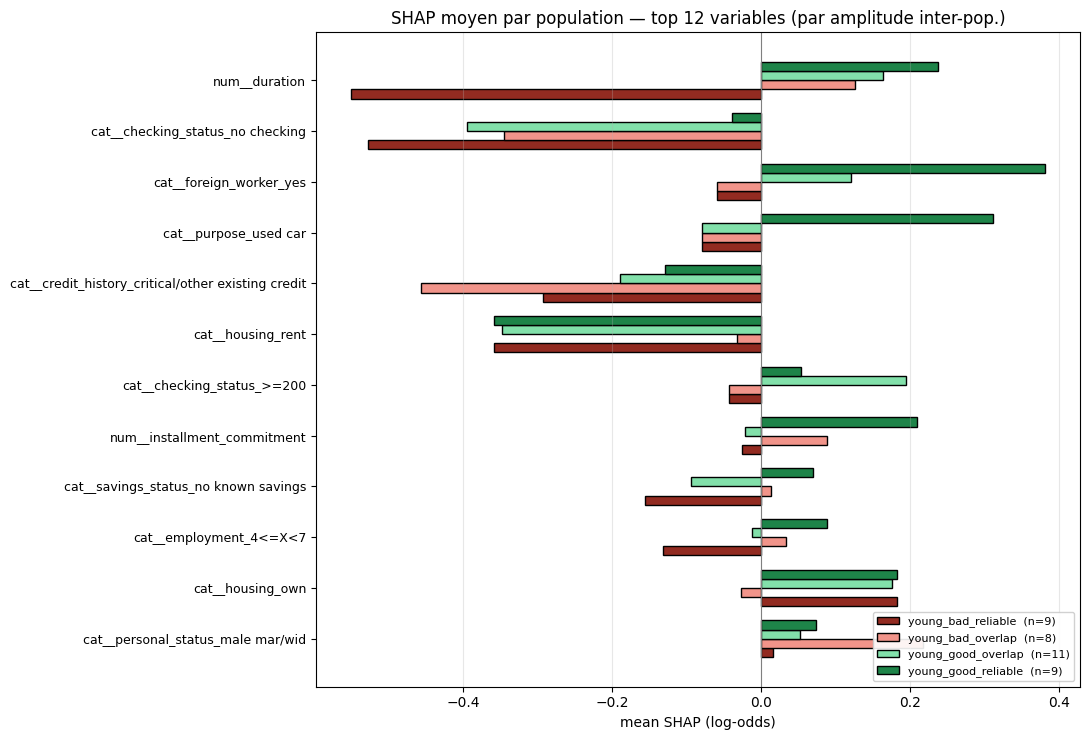

In [332]:
shap_by_pop = pd.DataFrame({
    name: shap_test[mask].mean(axis=0) for name, mask in populations.items()
}, index=feature_names)
shap_by_pop['range'] = shap_by_pop.max(axis=1) - shap_by_pop.min(axis=1)
shap_by_pop = shap_by_pop.sort_values('range', ascending=False)

pop_order  = ['young_bad_reliable', 'young_bad_overlap',
              'young_good_overlap', 'young_good_reliable']
pop_colors = ['#922B21', '#F1948A', '#82E0AA', '#1E8449']

top_n = 12
top_vars = shap_by_pop.head(top_n).index.tolist()[::-1]

fig, ax = plt.subplots(figsize=(11, 7.5))
n_pop  = len(pop_order)
bar_h  = 0.18
ypos   = np.arange(len(top_vars))

for k, (pop, c) in enumerate(zip(pop_order, pop_colors)):
    offset = (k - (n_pop - 1) / 2) * bar_h
    vals   = shap_by_pop.loc[top_vars, pop]
    n_obs  = int(populations[pop].sum())
    ax.barh(ypos + offset, vals, height=bar_h, color=c, edgecolor='black',
            label=f'{pop}  (n={n_obs})')

ax.set_yticks(ypos); ax.set_yticklabels(top_vars, fontsize=9)
ax.axvline(0, color='gray', lw=0.8)
ax.set_xlabel('mean SHAP (log-odds)')
ax.set_title(f'SHAP moyen par population — top {top_n} variables (par amplitude inter-pop.)')
ax.legend(loc='lower right', fontsize=8, framealpha=0.9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('shap_outputs/fig_mean_shap_4_populations.png',
            dpi=150, bbox_inches='tight')
plt.show()


<i> a. La figure suivante compare les contributions SHAP moyennes des principales variables dans les différentes régions de score chez les jeunes. </i>

L’objectif n’est pas encore d’expliquer des individus particuliers, mais d’observer comment la structure globale du signal  évolue entre les régions fiables et la zone d’overlap ! 

Un premier constat apparaît clairement, dans les régions fiables, les contributions SHAP sont fortement polarisées entre bons et mauvais profils. Les variables importantes poussent les scores dans des directions opposées selon la classe, ce qui permet au modèle de séparer les individus avec confiance.

À l’inverse, dans la région d’overlap, les contributions deviennent plus proches entre classes, souvent de plus faible amplitude, et parfois même de même signe. Les profils bons et mauvais deviennent alors localement beaucoup plus similaires du point de vue du modèle.

> Cette observation est révèle qu'il s'agit ici d'une ambiguïté informationnelle locale. Certaines variables restent importantes dans le calcul du score, mais leur capacité à discriminer les classes se dégrade fortement dans la zone d’overlap.


Exemple 

`num__duration` présente un signal fortement polarisé dans les régions fiables :
* positif chez les bons profils et négatif chez les mauvais 
* alors que ses contributions deviennent beaucoup plus proches dans l’overlap, traduisant une perte locale de pouvoir séparateur

La suite de l’analyse s’intéressera plus particulièrement à la variable `foreign_worker`, qui permettra d’illustrer plusieurs nuances importantes d’interprétation des valeurs SHAP, notamment le lien entre contribution au score, fréquence des modalités et véritable pouvoir discriminant.

### 8.3 Un paradoxe apparent , un coefficient négatif mais SHAP positif



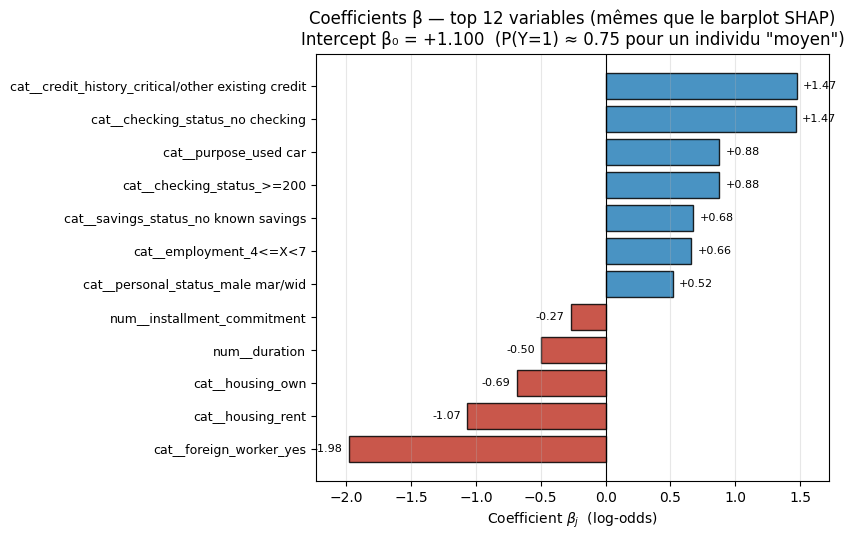

In [333]:
preproc_b = baseline.named_steps['preproc']
clf_b     = baseline.named_steps['clf']
feat_b    = list(preproc_b.get_feature_names_out())
coefs_b   = clf_b.coef_[0]
interc_b  = float(clf_b.intercept_[0])

coef_df = (pd.DataFrame({'beta': coefs_b}, index=feat_b)
             .assign(abs_beta=lambda d: d['beta'].abs(),
                     odds_ratio=lambda d: np.exp(d['beta']))
             .loc[top_vars]                # mêmes 12 variables que le barplot SHAP
             .sort_values('beta'))

fig, ax = plt.subplots(figsize=(8.5, 5.5))
colors = ['#C0392B' if b < 0 else '#2980B9' for b in coef_df['beta']]
ax.barh(range(len(coef_df)), coef_df['beta'], color=colors,
        edgecolor='black', alpha=0.85)
ax.set_yticks(range(len(coef_df)))
ax.set_yticklabels(coef_df.index, fontsize=9)
ax.axvline(0, color='black', lw=0.8)

for i, (idx, row) in enumerate(coef_df.iterrows()):
    dx = 0.05 if row['beta'] >= 0 else -0.05
    ha = 'left' if row['beta'] >= 0 else 'right'
    ax.text(row['beta'] + dx, i, f"{row['beta']:+.2f}",
            va='center', ha=ha, fontsize=8, color='black')

ax.set_xlabel(r'Coefficient $\beta_j$  (log-odds)')
ax.set_title(f'Coefficients β — top {len(coef_df)} variables (mêmes que le barplot SHAP)\n'
             f'Intercept β₀ = {interc_b:+.3f}  '
             f'(P(Y=1) ≈ {1/(1+np.exp(-interc_b)):.2f} pour un individu "moyen")')
ax.grid(axis='x', alpha=0.3)
x_pad = 0.25
ax.set_xlim(coef_df['beta'].min() - x_pad, coef_df['beta'].max() + x_pad)
plt.tight_layout()
plt.savefig('shap_outputs/fig_lr_coefficients_top12.png', dpi=150, bbox_inches='tight')
plt.show()



La variable `cat__foreign_worker_yes` présente un comportement qui peut sembler contradictoire au premier abord.

Dans la régression logistique, son coefficient est fortement négatif :

$$
\beta_{\text{foreign\_worker\_yes}}\approx -1.98
$$

ce qui signifie que la présence de cette modalité pousse globalement le score vers la classe *bad*.

Pourtant, dans les contributions SHAP moyennes observées précédemment, cette variable apparaît associée à des contributions fortement positives notamment chez les `good_reliable`.

Pour comprendre ce phénomène, il faut préciser comment les SHAP values sont calculées dans un modèle linéaire.


Pour un modèle linéaire comme la régression logistique, les valeurs SHAP peuvent s’écrire approximativement :

$$
\phi_j(x)\approx \beta_j(x_j-E[X_j])
$$

Cette relation montre qu’une contribution SHAP dépend simultanément :

- du coefficient appris par le modèle :
$$
\beta_j
$$

- et de l’écart entre l’individu et le profil moyen de référence :
$$
x_j-E[X_j]
$$

Autrement dit, SHAP ne mesure pas uniquement la force du coefficient du modèle, mais aussi à quel point l’individu est atypique relativement à la population moyenne.

Pour une variable catégorielle encodée en one-hot :

$$
x_j\in\{0,1\}
$$

et :

$$
E[X_j]=P(X_j=1)
$$

correspond simplement à la fréquence de la modalité dans le dataset.

Ainsi :

- si la modalité est présente :
$$
\phi_j(x)\approx \beta_j(1-P(X_j=1))
$$

- si la modalité est absente :
$$
\phi_j(x)\approx -\beta_jP(X_j=1)
$$

La fréquence de la modalité intervient donc directement dans la valeur SHAP.

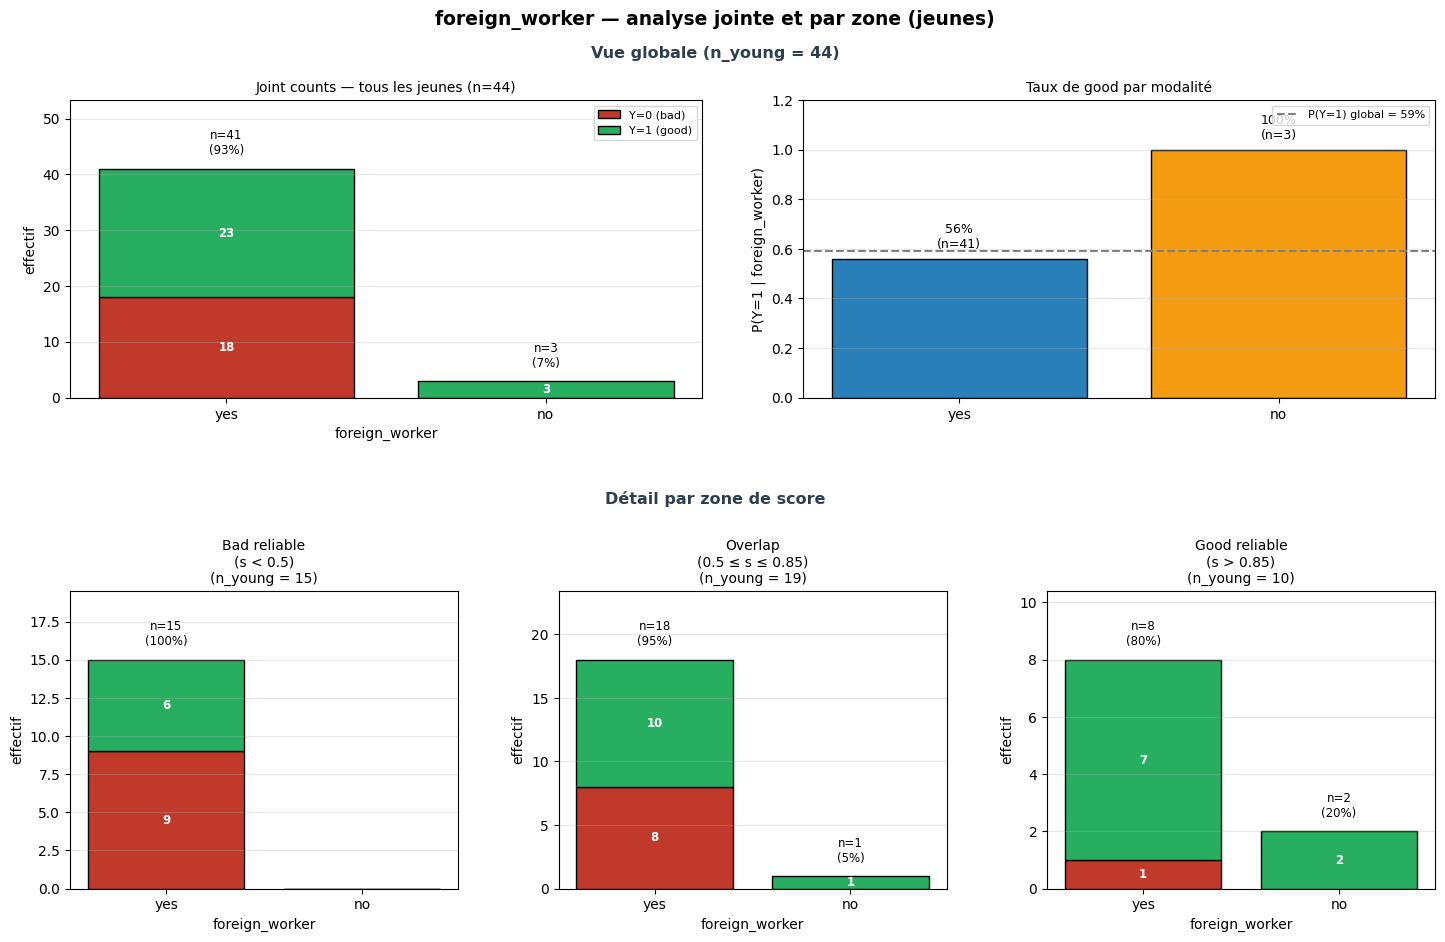

In [334]:
fw_young = X_test.loc[is_young, 'foreign_worker'].values
y_young  = y[is_young]
n_y      = int(is_young.sum())

totals = {v: int((fw_young == v).sum()) for v in ['yes', 'no']}
p_good = {v: (((fw_young == v) & (y_young == 1)).sum() / totals[v]) if totals[v] else np.nan
          for v in ['yes', 'no']}
p_good_global = float(y_young.mean())

j_fw    = feature_names.index('cat__foreign_worker_yes')
beta_fw = float(clf.coef_[0][j_fw])
mean_shap_fw_young = float(shap_test[is_young, j_fw].mean())

zones_fw = {
    'Bad reliable\n(s < 0.5)':      is_young & in_bad_rel,
    'Overlap\n(0.5 ≤ s ≤ 0.85)':    is_young & in_overlap,
    'Good reliable\n(s > 0.85)':    is_young & in_good_rel,
}

def _stacked_yes_no(ax, mask, title, show_legend=False):
    fw = X_test.loc[mask, 'foreign_worker'].values
    yz = y[mask]
    n  = int(mask.sum())
    bad_h  = [int(((fw == v) & (yz == 0)).sum()) for v in ['yes', 'no']]
    good_h = [int(((fw == v) & (yz == 1)).sum()) for v in ['yes', 'no']]
    tot_h  = [b + g for b, g in zip(bad_h, good_h)]

    xpos = np.arange(2)
    ax.bar(xpos, bad_h,  color='#C0392B', edgecolor='black', label='Y=0 (bad)')
    ax.bar(xpos, good_h, bottom=bad_h, color='#27AE60', edgecolor='black', label='Y=1 (good)')

    y_top = max(tot_h) if any(tot_h) else 1
    for i, tot in enumerate(tot_h):
        if tot > 0:
            ax.text(i, tot + y_top * 0.05,
                    f'n={tot}\n({tot/n:.0%})' if n else '0',
                    ha='center', va='bottom', fontsize=8.5)
        if bad_h[i] > 0:
            ax.text(i, bad_h[i] / 2, str(bad_h[i]),
                    ha='center', va='center', color='white', fontsize=8.5, fontweight='bold')
        if good_h[i] > 0:
            ax.text(i, bad_h[i] + good_h[i] / 2, str(good_h[i]),
                    ha='center', va='center', color='white', fontsize=8.5, fontweight='bold')
    ax.set_xticks(xpos); ax.set_xticklabels(['yes', 'no'])
    ax.set_xlabel('foreign_worker')
    ax.set_ylabel('effectif')
    ax.set_ylim(0, y_top * 1.30 if y_top else 1)
    ax.set_title(title, fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    if show_legend:
        ax.legend(fontsize=8, loc='upper right')

fig = plt.figure(figsize=(15, 9.5))
gs  = fig.add_gridspec(2, 6, hspace=0.65, wspace=0.7,
                       top=0.90, bottom=0.07, left=0.07, right=0.98)

ax_joint = fig.add_subplot(gs[0, :3])
ax_pyfw  = fig.add_subplot(gs[0, 3:])

_stacked_yes_no(ax_joint, is_young,
                f'Joint counts — tous les jeunes (n={n_y})', show_legend=True)

vals = [p_good['yes'], p_good['no']]
bars = ax_pyfw.bar(['yes', 'no'], vals,
                   color=['#2980B9', '#F39C12'], edgecolor='black')
ax_pyfw.axhline(p_good_global, color='gray', ls='--', lw=1.5,
                label=f'P(Y=1) global = {p_good_global:.0%}')
for bar, val, v in zip(bars, vals, ['yes', 'no']):
    ax_pyfw.text(bar.get_x() + bar.get_width() / 2, val + 0.03,
                 f'{val:.0%}\n(n={totals[v]})',
                 ha='center', va='bottom', fontsize=9)
ax_pyfw.set_ylim(0, max(max(vals), p_good_global) + 0.20)
ax_pyfw.set_ylabel('P(Y=1 | foreign_worker)')
ax_pyfw.set_title('Taux de good par modalité', fontsize=10)
ax_pyfw.legend(fontsize=8, loc='upper right')
ax_pyfw.grid(axis='y', alpha=0.3)

ax_zones = [fig.add_subplot(gs[1, :2]),
            fig.add_subplot(gs[1, 2:4]),
            fig.add_subplot(gs[1, 4:])]
for ax, (zname, mask) in zip(ax_zones, zones_fw.items()):
    _stacked_yes_no(ax, mask,
                    f'{zname}\n(n_young = {int(mask.sum())})',
                    show_legend=False)

fig.text(0.5, 0.945,
         f'Vue globale (n_young = {n_y})',
         ha='center', fontsize=11.5, fontweight='bold', color='#2C3E50')
fig.text(0.5, 0.475,
         'Détail par zone de score',
         ha='center', fontsize=11.5, fontweight='bold', color='#2C3E50')

fig.suptitle('foreign_worker — analyse jointe et par zone (jeunes)',
             fontsize=13.5, fontweight='bold', y=0.995)
plt.savefig('shap_outputs/fig_foreign_worker_full.png',
            dpi=150, bbox_inches='tight')
plt.show()

La figure suivante met en évidence un point essentiel : la modalité

$$
foreign\_worker = yes
$$

représente presque toute la population jeune, tandis que :

$$
foreign\_worker = no
$$

reste extrêmement rare.



$$
P(\text{foreign\_worker=yes})\approx0.96
$$


Ainsi, pour les individus ayant :

$$
foreign\_worker=yes
$$

la contribution SHAP devient :

$$
\phi_j(x)\approx -1.98\times(1-0.96)\approx -0.08
$$

malgré le coefficient fortement négatif.

À l’inverse, les rares individus associés à :

$$
foreign\_worker=no
$$

s’éloignent fortement du profil moyen :

$$
\phi_j(x)\approx -1.98\times(-0.96)\approx +1.90
$$

et produisent donc des contributions SHAP fortement positives.

Ce phénomène devient encore plus important lorsqu’on analyse des sous-régions locales du score.

Globalement, les individus :

$$
foreign\_worker=no
$$

restent extrêmement rares et leurs contributions SHAP positives sont diluées dans la moyenne globale.

Mais dans la région :

$$
\text{good reliable}
$$

leur proportion augmente fortement (≈20% contre ≈4% globalement chez les jeunes).

Les quelques individus `no`, associés à des contributions très élevées :

$$
\phi_j(x)\approx +1.90
$$

deviennent alors beaucoup plus influents dans les moyennes SHAP locales.

Ainsi, le signal SHAP positif observé pour :

$$
cat\_\_foreign\_worker\_yes
$$

dans `good reliable` ne signifie pas que la modalité `yes` favorise les profils *good*.

Il reflète principalement l’effet des rares individus :

$$
foreign\_worker=no
$$

dont les contributions positives deviennent localement dominantes.


> Cette analyse met en évidence une nuance essentielle,  les contributions SHAP locales dépendent non seulement du modèle appris, mais aussi de la fréquence des modalités et de la population sur laquelle les moyennes sont calculées. Une variable peut ainsi apparaître fortement contributive dans une région donnée sans pour autant constituer un véritable signal discriminant entre *good* et *bad*.


###  8.4 Forces opposées par zone

### Compensation des forces SHAP dans la région d’overlap

La figure suivante permet d’observer comment les scores se construisent individuellement chez les jeunes.

Pour chaque individu :
- les barres vertes représentent la somme des contributions SHAP positives :
$$
\sum \phi^+
$$

- les barres rouges représentent la somme des contributions SHAP négatives :
$$
\sum \phi^-
$$

- le losange représente le score SHAP net :
$$
\sum_j \phi_j
$$

- La couleur du losange indique la vraie classe : </br> 
<span style="color:#6FCF97;"> vrai *good*</span> </br>
<span style="color:#D64545;"> vrai *bad*</span> </br>



/var/folders/ms/qzgtjj3j3mn0m5lv1hk9kcr40000gn/T/ipykernel_51501/2033763761.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.97])


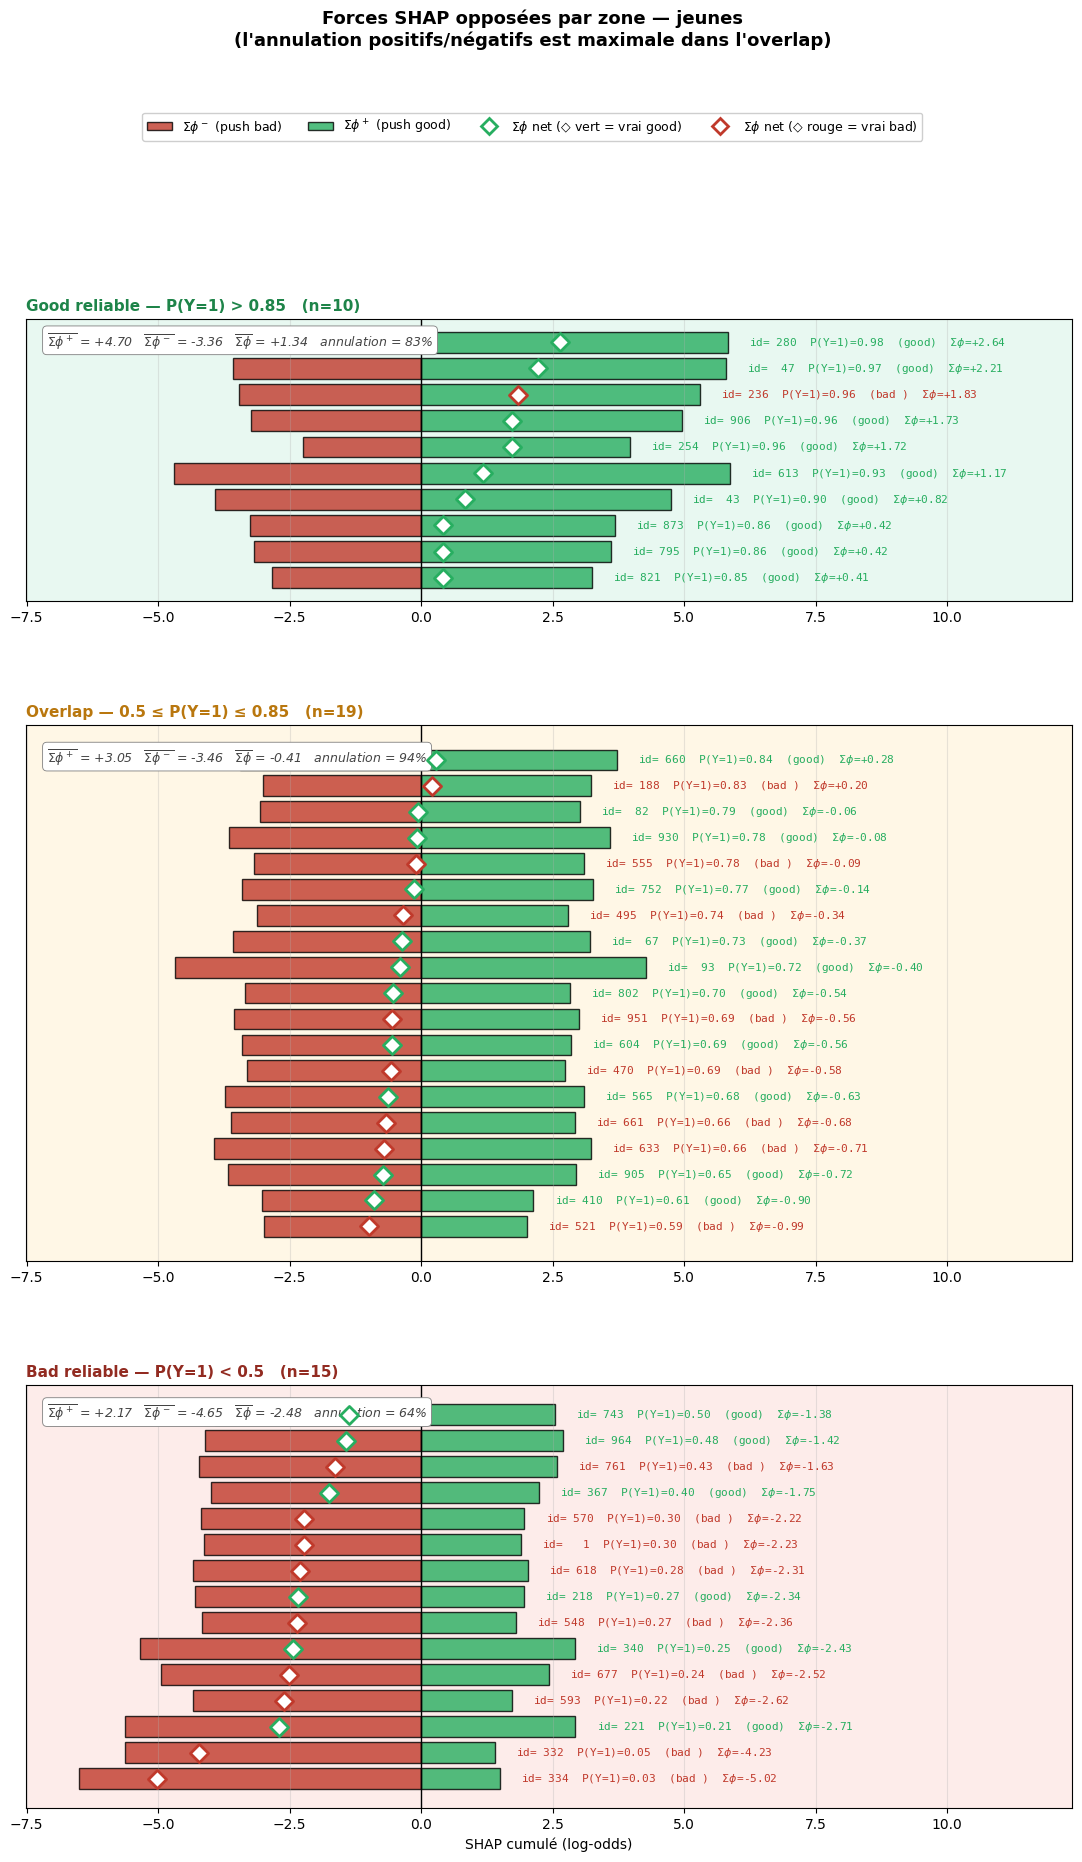

In [335]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

zones = {
    'good_reliable': is_young & in_good_rel,
    'overlap':       is_young & in_overlap,
    'bad_reliable':  is_young & in_bad_rel,
}
zone_titles = {
    'good_reliable': 'Good reliable — P(Y=1) > 0.85',
    'overlap':       'Overlap — 0.5 ≤ P(Y=1) ≤ 0.85',
    'bad_reliable':  'Bad reliable — P(Y=1) < 0.5',
}
zone_bg     = {'good_reliable': '#E8F8F1', 'overlap': '#FFF7E6', 'bad_reliable': '#FDECEA'}
zone_color  = {'good_reliable': '#1E8449', 'overlap': '#B9770E', 'bad_reliable': '#922B21'}

order_zones = ['good_reliable', 'overlap', 'bad_reliable']

zone_data = {}
for z, m in zones.items():
    s   = shap_test[m]
    pos = np.where(s > 0, s, 0).sum(axis=1)
    neg = np.where(s < 0, s, 0).sum(axis=1)
    net = pos + neg
    zone_data[z] = {
        'shap': s, 'pos': pos, 'neg': neg, 'net': net,
        'score': score[m], 'y': y[m], 'idx': X_test.index[m],
        'n': int(m.sum()),
    }

x_min = min(zd['neg'].min() for zd in zone_data.values()) - 1.0
x_pos_max = max(zd['pos'].max() for zd in zone_data.values())
x_max = x_pos_max + 6.5   # room for annotations

heights = [zone_data[z]['n'] for z in order_zones]
fig, axes = plt.subplots(3, 1,
                         figsize=(13.5, 0.36 * sum(heights) + 3.5),
                         gridspec_kw={'height_ratios': heights, 'hspace': 0.30})

for ax, z in zip(axes, order_zones):
    zd  = zone_data[z]
    n_z = zd['n']
    if n_z == 0:
        ax.text(0.5, 0.5, f'(aucun jeune en zone {z})', ha='center', va='center',
                transform=ax.transAxes); ax.set_yticks([]); continue
    order = np.argsort(zd['net'])
    ypos  = np.arange(n_z)

    ax.set_facecolor(zone_bg[z])
    ax.barh(ypos, zd['neg'][order], color='#C0392B', edgecolor='black', alpha=0.80)
    ax.barh(ypos, zd['pos'][order], color='#27AE60', edgecolor='black', alpha=0.80)

    for j, i in enumerate(order):
        cls_c = '#27AE60' if zd['y'][i] == 1 else '#C0392B'
        ax.scatter(zd['net'][i], j, marker='D', s=85,
                   facecolor='white', edgecolor=cls_c, linewidth=2, zorder=5)

    for j, i in enumerate(order):
        cls   = 'good' if zd['y'][i] == 1 else 'bad '
        cls_c = '#27AE60' if zd['y'][i] == 1 else '#C0392B'
        ax.text(zd['pos'][order][j] + 0.4, j,
                f'id={zd["idx"][i]:>4d}  P(Y=1)={zd["score"][i]:.2f}  ({cls})  '
                f'$\\Sigma\\phi$={zd["net"][i]:+.2f}',
                va='center', ha='left', fontsize=8, color=cls_c, family='monospace')

    ax.axvline(0, color='black', lw=1)
    ax.set_yticks([])
    ax.set_xlim(x_min, x_max)
    ax.set_title(f'{zone_titles[z]}   (n={n_z})',
                 loc='left', fontsize=11, fontweight='bold', color=zone_color[z])
    ax.grid(axis='x', alpha=0.3)

    mean_pos = zd['pos'].mean(); mean_neg = zd['neg'].mean()
    mean_net = zd['net'].mean(); amp = mean_pos - mean_neg
    cancel   = (1 - abs(mean_net) / amp) * 100 if amp else 0
    ax.text(0.02, 0.96,
            f'$\\overline{{\\Sigma\\phi^+}}$ = +{mean_pos:.2f}   '
            f'$\\overline{{\\Sigma\\phi^-}}$ = {mean_neg:.2f}   '
            f'$\\overline{{\\Sigma\\phi}}$ = {mean_net:+.2f}   '
            f'annulation = {cancel:.0f}%',
            ha='left', va='top', transform=ax.transAxes,
            fontsize=9, style='italic', color='#444',
            bbox=dict(boxstyle='round,pad=0.35', fc='white', ec='gray', lw=0.6))

axes[-1].set_xlabel('SHAP cumulé (log-odds)')

handles = [
    Patch(facecolor='#C0392B', edgecolor='black', alpha=0.80,
          label=r'$\Sigma\phi^-$ (push bad)'),
    Patch(facecolor='#27AE60', edgecolor='black', alpha=0.80,
          label=r'$\Sigma\phi^+$ (push good)'),
    Line2D([0], [0], marker='D', linestyle='', markersize=8,
           markerfacecolor='white', markeredgecolor='#27AE60', markeredgewidth=2,
           label=r'$\Sigma\phi$ net (◇ vert = vrai good)'),
    Line2D([0], [0], marker='D', linestyle='', markersize=8,
           markerfacecolor='white', markeredgecolor='#C0392B', markeredgewidth=2,
           label=r'$\Sigma\phi$ net (◇ rouge = vrai bad)'),
]
fig.legend(handles=handles, loc='upper center', ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, 0.99), frameon=True, framealpha=0.95)

fig.suptitle('Forces SHAP opposées par zone — jeunes\n'
             "(l'annulation positifs/négatifs est maximale dans l'overlap)",
             y=1.04, fontsize=13, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('shap_outputs/fig_shap_forces_by_zone.png',
            dpi=150, bbox_inches='tight')
plt.show()


## Analyse

Des contributions SHAP positives et négatives coexistent dans toutes les régions, y compris dans les zones fiables.

Le problème de l’overlap ne provient donc pas simplement de la présence de signaux contradictoires, mais du fait qu’aucune direction ne parvient plus à dominer clairement le score final.

Dans la région `good_reliable`, les forces opposées restent importantes, mais les contributions positives demeurent globalement dominantes.  
Les scores nets restent donc clairement positifs et cohérents avec la vraie classe.

À l’inverse, dans la région `overlap`, les contributions positives et négatives deviennent beaucoup plus équilibrées.  

Deux phénomènes apparaissent alors simultanément :

- certains vrais *good* reçoivent des scores faiblement positifs
- certains vrais *bad* reçoivent des scores similaires aux vrais good.

Des individus appartenant à des classes différentes deviennent ainsi presque indiscernables du point de vue du modèle.

> Le problème n’est donc pas une absence totale d’information.
> Le modèle détecte bien des signaux favorables et défavorables, mais aucun ne devient suffisamment dominant pour produire une séparation robuste entre les classes dans la zone overlap.

###   8.5 Pourquoi les vrais good basculent dans `l'overlap`


Les analyses précédentes ont montré que les profils présents dans
l’overlap ne sont pas dépourvus de signal favorable. Le problème semble plutôt venir d’une perte progressive de dominance
du signal *good*. 


Nous cherchons maintenant à comprendre : 

> comment un individu réellement good perd-il progressivement son caractère “fiable” du point de vue du modèle ?

L’analyse suivante procède en deux étapes :
1. étudier le déplacement des contributions SHAP variable par variable ;
2. puis décomposer ce basculement entre perte de preuves favorables
   et gain de preuves défavorables.


In [336]:
shap_gr = shap_test[young_good_reliable]   # Groupe A
shap_go = shap_test[young_good_overlap]    # Groupe B
n_gr = int(young_good_reliable.sum())
n_go = int(young_good_overlap.sum())

mean_gr = shap_gr.mean(axis=0)
mean_go = shap_go.mean(axis=0)
delta_good = mean_go - mean_gr

positive_loss = np.maximum(0, mean_gr) - np.maximum(0, mean_go)
negative_gain = np.maximum(0, -mean_go) - np.maximum(0, -mean_gr)

shift_df = pd.DataFrame({
    'mean_shap_good_reliable': mean_gr,
    'mean_shap_good_overlap':  mean_go,
    'delta_good':              delta_good,
    'abs_delta':               np.abs(delta_good),
    'positive_loss':           positive_loss,
    'negative_gain':           negative_gain,
}, index=feature_names).sort_values('abs_delta', ascending=False)

####  Déplacement des contributions SHAP entre `good_reliable` et `good_overlap`


Cette figure compare les contributions SHAP moyennes des vrais profils *good* selon leur position dans l’espace des scores : `good_reliable` versus `good_overlap`.

L’objectif est de comprendre pourquoi certains individus réellement *good* ne reçoivent pas un score suffisamment élevé pour rejoindre la zone fiable.


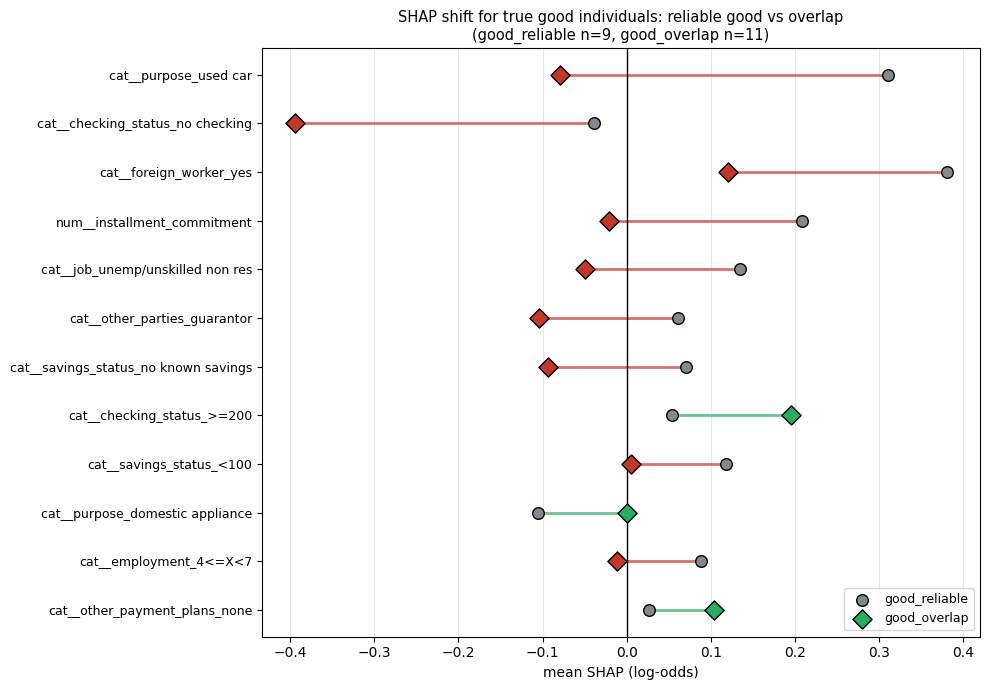

In [337]:
TOP = 12
top_shift = shift_df.head(TOP).iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 7))
for i, (feat, row) in enumerate(top_shift.iterrows()):
    r, o = row['mean_shap_good_reliable'], row['mean_shap_good_overlap']
    color = '#C0392B' if o < r else '#27AE60'
    ax.plot([r, o], [i, i], color=color, lw=2, alpha=0.7, zorder=2)
    ax.scatter(r, i, color='#7F8C8D', s=70, zorder=3, edgecolor='black',
               label='good_reliable' if i == 0 else None)
    ax.scatter(o, i, color=color, s=95, zorder=3, edgecolor='black', marker='D',
               label='good_overlap' if i == 0 else None)

ax.axvline(0, color='black', lw=1)
ax.set_yticks(range(len(top_shift)))
ax.set_yticklabels(top_shift.index, fontsize=9)
ax.set_xlabel('mean SHAP (log-odds)')
ax.set_title('SHAP shift for true good individuals: reliable good vs overlap\n'
             f'(good_reliable n={n_gr}, good_overlap n={n_go})', fontsize=10.5)
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('shap_outputs/fig_good_shap_shift.png', dpi=150, bbox_inches='tight')
plt.show()


### Analyse

Trois comportements distincts apparaissent quand on passe des 
`good_reliable` à `l'overlap`. 

- Plusieurs variables qui 
poussaient fortement les good_reliable vers des scores élevés 
perdent une partie importante de leur amplitude dans l'overlap. Elles restent parfois positives, mais ne 
portent plus le score avec la même intensité.

- Certaines variables 
changent carrément de signe. 
Elles participent alors à tirer certains vrais *good* vers des 
scores plus faibles.

- Quelques variables conservent ou 
renforcent leur contribution favorable. Mais ce noyau résistant ne suffit 
pas à compenser l'affaiblissement global ni l'apparition de 
contributions défavorables.

> **Les vrais *good* en overlap ne manquent pas de signal favorable, 
> c'est donc bel et bien sa dominance qui s'effrite.** Certaines variables favorables
> s'affaiblissent, d'autres deviennent franchement défavorables, et
> celles qui résistent restent minoritaires.

#### Décomposition du basculement vers l’overlap

La figure précédente montrait comment les contributions SHAP se déplacent
lorsqu’un vrai profil *good* bascule vers l’overlap.

Nous cherchons maintenant à synthétiser ce déplacement en séparant
explicitement :
- la perte de preuves favorables ;
- et le gain de preuves défavorables.

Pour chaque variable $j$ :

$$
\text{perte}_j = \max(0,\, \overline{\phi_j^{\text{rel}}}) - \max(0,\, \overline{\phi_j^{\text{ov}}})
\qquad\text{(preuve favorable perdue)}
$$

$$
\text{gain}_j = \max(0,\, -\overline{\phi_j^{\text{ov}}}) - \max(0,\, -\overline{\phi_j^{\text{rel}}})
\qquad\text{(preuve défavorable gagnée)}
$$


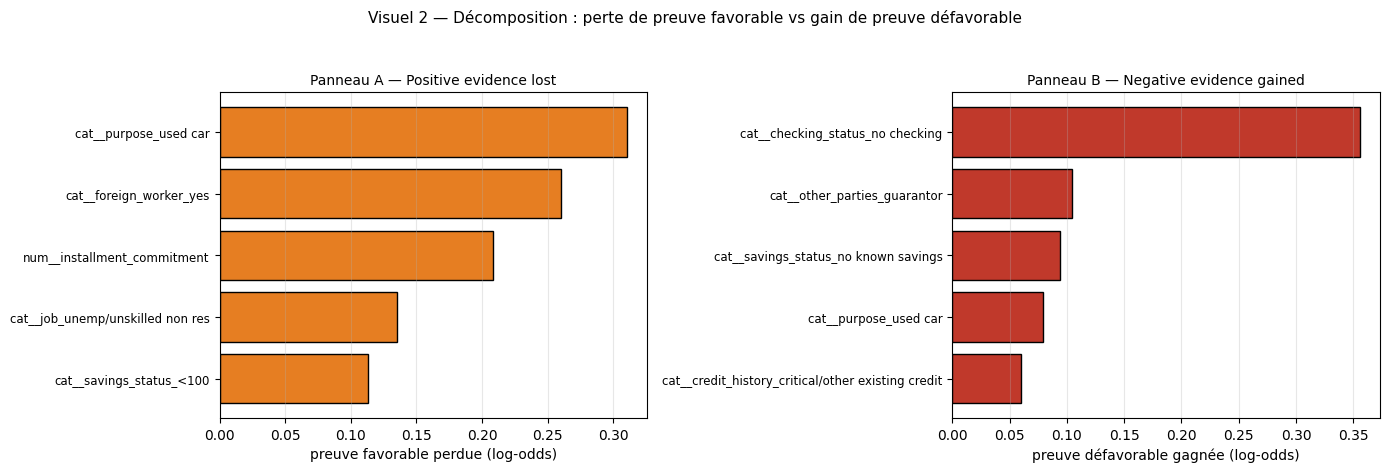

In [338]:
loss_top = shift_df.sort_values('positive_loss', ascending=False).head(5).iloc[::-1]
gain_top = shift_df.sort_values('negative_gain', ascending=False).head(5).iloc[::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].barh(range(len(loss_top)), loss_top['positive_loss'],
             color='#E67E22', edgecolor='black')
axes[0].set_yticks(range(len(loss_top)))
axes[0].set_yticklabels(loss_top.index, fontsize=8.5)
axes[0].set_xlabel('preuve favorable perdue (log-odds)')
axes[0].set_title('Panneau A — Positive evidence lost', fontsize=10)
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(range(len(gain_top)), gain_top['negative_gain'],
             color='#C0392B', edgecolor='black')
axes[1].set_yticks(range(len(gain_top)))
axes[1].set_yticklabels(gain_top.index, fontsize=8.5)
axes[1].set_xlabel('preuve défavorable gagnée (log-odds)')
axes[1].set_title('Panneau B — Negative evidence gained', fontsize=10)
axes[1].grid(axis='x', alpha=0.3)

fig.suptitle('Visuel 2 — Décomposition : perte de preuve favorable vs gain de preuve défavorable',
             y=1.04, fontsize=11)
plt.tight_layout()
plt.savefig('shap_outputs/fig_good_evidence_decomp.png', dpi=150, bbox_inches='tight')
plt.show()


### Analyse

Le panneau A montre que le phénomène principal est une érosion progressive
du signal positif. Plusieurs variables auparavant fortement favorables
voient leur contribution diminuer nettement dans l’overlap.

Le panneau B met également en évidence un renforcement de certaines
contributions négatives, mais ce phénomène reste plus concentré sur un
nombre limité de variables.

> Le passage vers l’overlap semble donc davantage provoqué par un
> affaiblissement diffus des preuves favorables que par l’apparition
> brutale d’un signal massivement défavorable.

### 8.7 Waterfall individuels

Les analyses précédentes ont caractérisé l’overlap à l’échelle des populations et des variables moyennes.

Nous passons maintenant à une lecture locale des décisions du modèle.

L’objectif n’est plus d’étudier les tendances globales, mais de comprendre,
individu par individu, comment les différentes contributions SHAP
s’additionnent pour produire un score final.

Cette étape est particulièrement importante dans une perspective
d’explicabilité opérationnelle. Deux individus proches en score
peuvent reposer sur des structures explicatives très différentes,
ou au contraire présenter des profils explicatifs presque identiques
malgré des classes réelles opposées.

Les visualisations waterfall permettent précisément de reconstruire
cette mécanique décisionnelle locale.

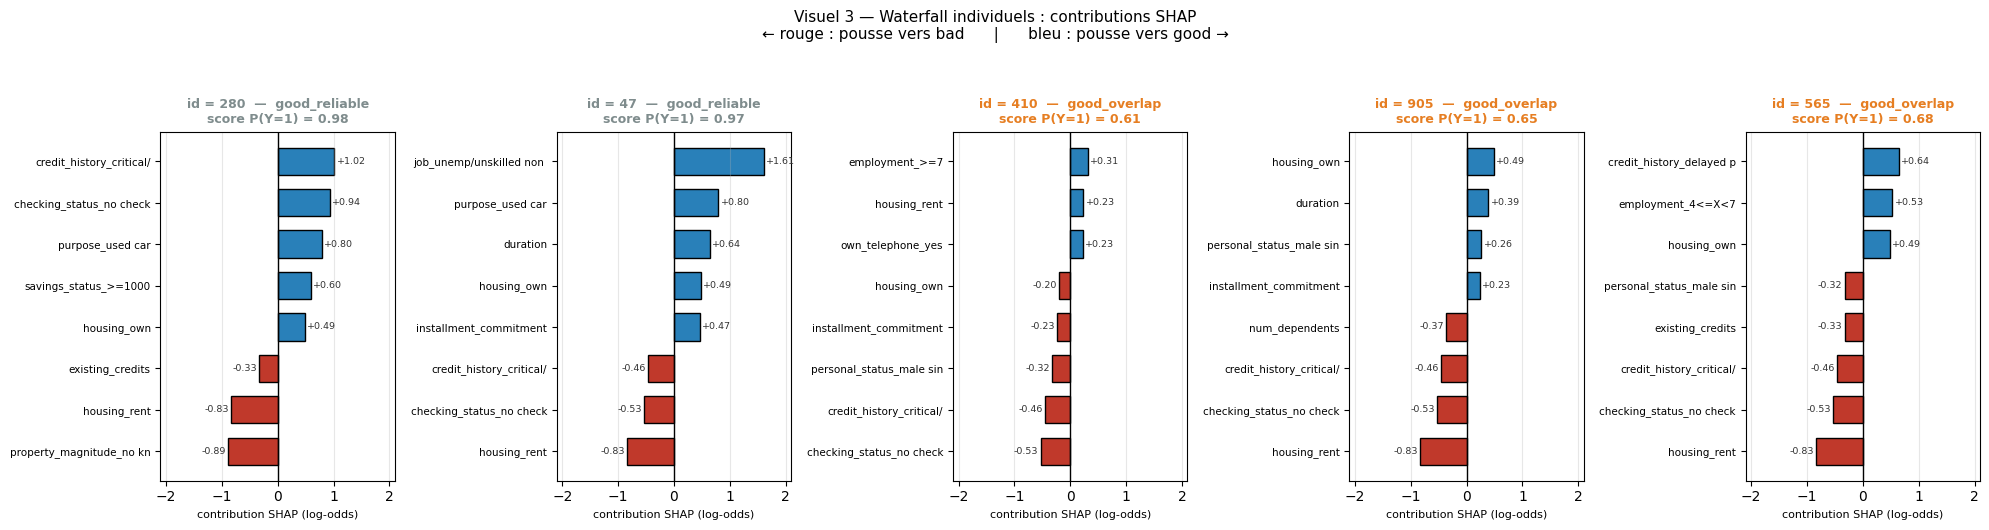

In [339]:
idx_gr   = X_test.index[young_good_reliable]
idx_go   = X_test.index[young_good_overlap]
score_gr = score[young_good_reliable]
score_go = score[young_good_overlap]

# 2 good_reliable (scores les plus élevés) + 3 good_overlap (scores les moins élevés)
sel_gr = idx_gr[np.argsort(score_gr)[::-1][:2]]
sel_go = idx_go[np.argsort(score_go)[:3]]
selected = [(ix, 'good_reliable') for ix in sel_gr] + \
           [(ix, 'good_overlap')  for ix in sel_go]

# Échelle x commune pour comparer les 5 profils à armes égales
_xmax = 0.0
for ix, _ in selected:
    pos = int(np.where(X_test.index == ix)[0][0])
    sv  = shap_test[pos]
    top = np.argsort(np.abs(sv))[::-1][:8]
    _xmax = max(_xmax, np.abs(sv[top]).max())
xlim = (-_xmax * 1.30, _xmax * 1.30)

fig, axes = plt.subplots(1, len(selected), figsize=(4.0 * len(selected), 5.0),
                         sharex=True)

for ax, (ix, grp) in zip(axes, selected):
    pos = int(np.where(X_test.index == ix)[0][0])
    sv  = shap_test[pos]

    # top 8 par |SHAP|, puis triées par valeur SHAP (négatif en bas, positif en haut)
    order = np.argsort(np.abs(sv))[::-1][:8]
    order = order[np.argsort(sv[order])]
    vals  = sv[order]
    names = [feature_names[k].replace('cat__', '').replace('num__', '')[:24]
             for k in order]
    colors = ['#C0392B' if v < 0 else '#2980B9' for v in vals]

    ax.barh(range(len(vals)), vals, color=colors, edgecolor='black', height=0.66)
    ax.axvline(0, color='black', lw=1)
    for i, v in enumerate(vals):
        ax.text(v + np.sign(v) * 0.04, i, f'{v:+.2f}',
                ha='left' if v >= 0 else 'right', va='center',
                fontsize=6.8, color='#333')
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=7.5)
    ax.set_xlim(xlim)
    grp_color = '#7F8C8D' if grp == 'good_reliable' else '#E67E22'
    ax.set_title(f'id = {ix}  —  {grp}\nscore P(Y=1) = {score[pos]:.2f}',
                 fontsize=9, color=grp_color, fontweight='bold')
    ax.set_xlabel('contribution SHAP (log-odds)', fontsize=8)
    ax.grid(axis='x', alpha=0.3)

fig.suptitle('Visuel 3 — Waterfall individuels : contributions SHAP\n'
             '← rouge : pousse vers bad      |      bleu : pousse vers good →',
             y=1.05, fontsize=11)
plt.tight_layout()
plt.savefig('shap_outputs/fig_good_individual_waterfall.png',
            dpi=150, bbox_inches='tight')
plt.show()

### Construction locale d’une contribution SHAP

Les waterfalls précédents montrent quelles variables poussent localement
le score vers *good* ou *bad*.

Le visuel suivant va plus loin, 
il décompose pédagogiquement la mécanique ayant produit ces contributions.

Chaque variable est reconstruite en trois étapes :

1. la fréquence de la modalité dans la population de référence 
2. le poids appris par le modèle 
3. la contribution SHAP résultante

L’objectif est de montrer qu’une contribution SHAP importante
ne dépend pas uniquement du coefficient du modèle,
mais également du caractère fréquent ou atypique du profil observé.

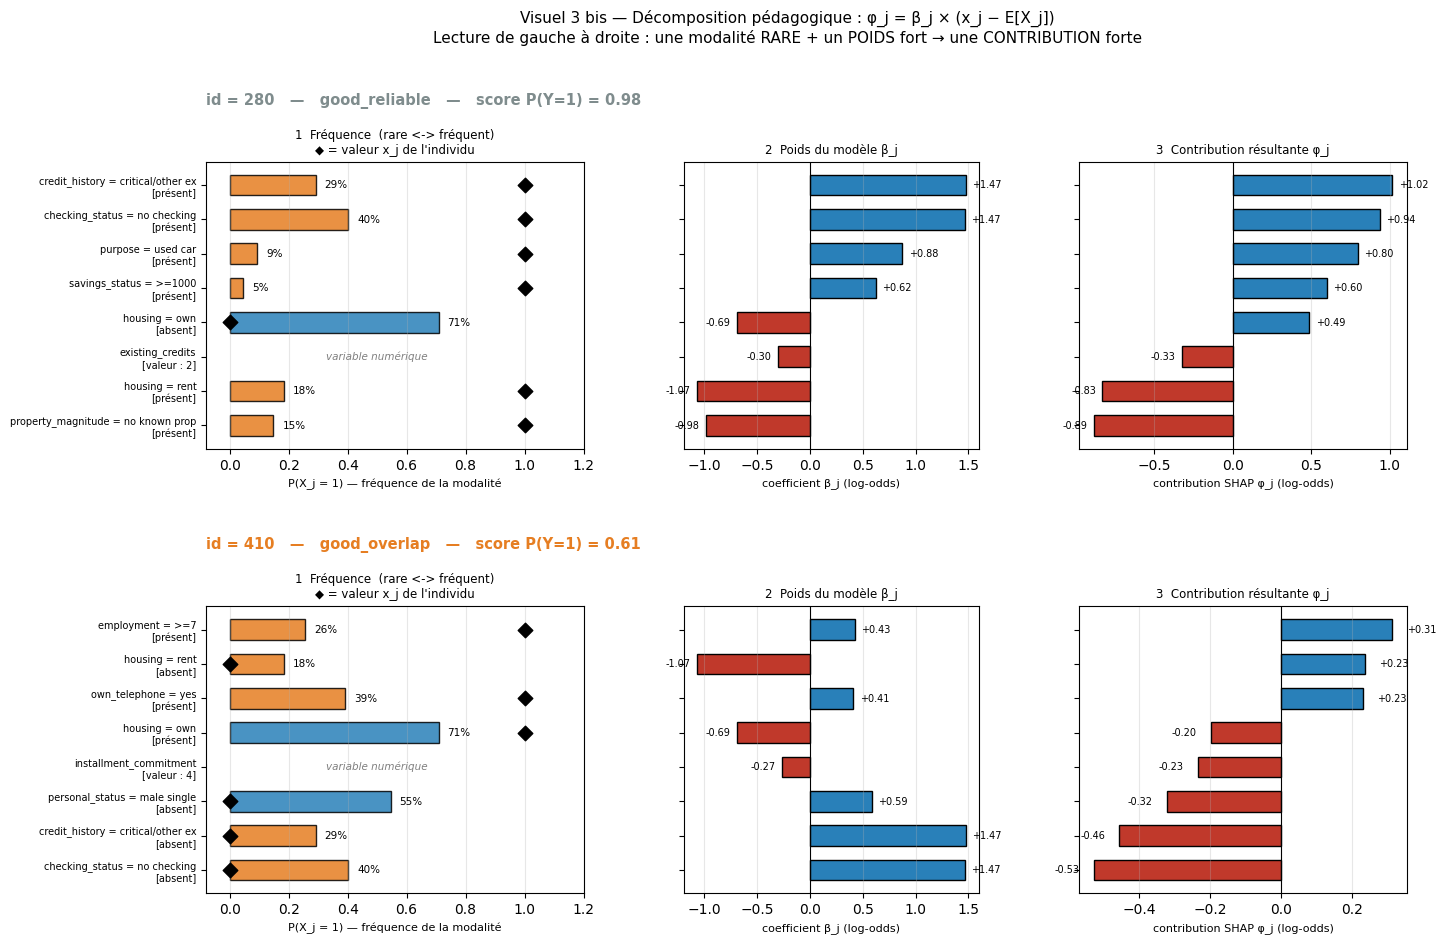

In [340]:
def _parse(feat):
    if feat.startswith('num__'):
        return feat[5:], None
    if feat.startswith('cat__'):
        rest = feat[5:]
        for col in sorted(cat_cols, key=len, reverse=True):
            if rest.startswith(col + '_'):
                return col, rest[len(col) + 1:]
    return feat, None

# Deux individus contrastés
ix_rel = idx_gr[int(np.argsort(score_gr)[::-1][0])]
ix_ov  = idx_go[int(np.argsort(score_go)[0])]
selected2 = [(ix_rel, 'good_reliable'), (ix_ov, 'good_overlap')]

fig, axes = plt.subplots(
    2, 3, figsize=(15.5, 9.5),
    gridspec_kw={'width_ratios': [1.15, 0.9, 1.0], 'hspace': 0.55, 'wspace': 0.30},
)

for row, (ix, grp) in enumerate(selected2):
    pos   = int(np.where(X_test.index == ix)[0][0])
    sv    = shap_test[pos]
    order = np.argsort(np.abs(sv))[::-1][:8]
    items = sorted([(sv[k], feature_names[k]) for k in order], key=lambda t: t[0])
    shap_vals = [v for v, _ in items]
    feats     = [f for _, f in items]

    ylabels, freqs, betas, xj_list = [], [], [], []
    for feat in feats:
        col, modality = _parse(feat)
        raw  = X_test.loc[ix, col]
        bidx = feature_names.index(feat)
        betas.append(float(clf.coef_[0][bidx]))
        if modality is not None:
            xj = 1 if str(raw) == str(modality) else 0
            p1 = float((X_train[col].astype(str) == str(modality)).mean())
            freqs.append(p1); xj_list.append(xj)
            etat = 'présent' if xj else 'absent'
            ylabels.append(f'{col} = {modality}'[:34] + f'\n[{etat}]')
        else:
            freqs.append(None); xj_list.append(None)
            ylabels.append(f'{col}'[:34] + f'\n[valeur : {raw}]')

    ypos = np.arange(len(feats))

    # ── Panneau 1 : fréquence P(X_j=1) ──
    ax = axes[row, 0]
    for i, (p1, xj) in enumerate(zip(freqs, xj_list)):
        if p1 is None:
            ax.text(0.5, i, 'variable numérique', va='center', ha='center',
                    fontsize=7.5, style='italic', color='gray')
        else:
            c = '#E67E22' if p1 < 0.5 else '#2980B9'
            ax.barh(i, p1, color=c, edgecolor='black', alpha=0.85, height=0.6)
            ax.text(p1 + 0.03, i, f'{p1:.0%}', va='center', fontsize=7.5)
            # marqueur de la valeur de l'individu x_j
            ax.scatter(xj, i, marker='D', s=55, color='black', zorder=5)
    ax.set_xlim(-0.08, 1.20)
    ax.set_yticks(ypos); ax.set_yticklabels(ylabels, fontsize=7)
    ax.set_xlabel('P(X_j = 1) — fréquence de la modalité', fontsize=8)
    ax.set_title('1  Fréquence  (rare <-> fréquent)\n◆ = valeur x_j de l\'individu',
                 fontsize=8.5)
    ax.grid(axis='x', alpha=0.3)

    # ── Panneau 2 : coefficient β_j ──
    ax = axes[row, 1]
    ax.barh(ypos, betas, color=['#C0392B' if b < 0 else '#2980B9' for b in betas],
            edgecolor='black', height=0.6)
    ax.axvline(0, color='black', lw=0.8)
    for i, b in enumerate(betas):
        ax.text(b + (0.06 if b >= 0 else -0.06), i, f'{b:+.2f}',
                va='center', ha='left' if b >= 0 else 'right', fontsize=7)
    ax.set_yticks(ypos); ax.set_yticklabels([])
    ax.set_xlabel('coefficient β_j (log-odds)', fontsize=8)
    ax.set_title('2  Poids du modèle β_j', fontsize=8.5)
    ax.grid(axis='x', alpha=0.3)

    # ── Panneau 3 : contribution SHAP φ_j ──
    ax = axes[row, 2]
    ax.barh(ypos, shap_vals,
            color=['#C0392B' if v < 0 else '#2980B9' for v in shap_vals],
            edgecolor='black', height=0.6)
    ax.axvline(0, color='black', lw=0.8)
    for i, v in enumerate(shap_vals):
        ax.text(v + (0.04 if v >= 0 else -0.04), i, f'{v:+.2f}',
                va='center', ha='left' if v >= 0 else 'right', fontsize=7)
    ax.set_yticks(ypos); ax.set_yticklabels([])
    ax.set_xlabel('contribution SHAP φ_j (log-odds)', fontsize=8)
    ax.set_title('3  Contribution résultante φ_j', fontsize=8.5)
    ax.grid(axis='x', alpha=0.3)

    grp_color = '#7F8C8D' if grp == 'good_reliable' else '#E67E22'
    axes[row, 0].annotate(
        f'id = {ix}   —   {grp}   —   score P(Y=1) = {score[pos]:.2f}',
        xy=(0.0, 1.20), xycoords='axes fraction',
        fontsize=10.5, fontweight='bold', color=grp_color)

fig.suptitle(
    'Visuel 3 bis — Décomposition pédagogique : φ_j = β_j × (x_j − E[X_j])\n'
    'Lecture de gauche à droite : une modalité RARE + un POIDS fort → une CONTRIBUTION forte',
    y=1.04, fontsize=11)
plt.savefig('shap_outputs/fig_good_shap_decomposition_pedago.png',
            dpi=150, bbox_inches='tight')
plt.show()


On retrouve ici le même type de bascule que plus haut pour foreign_worker_yes, cette fois 
au niveau de deux individus concrets.

La même variable, avec le même 
coefficient, va produire des contributions SHAP de signes opposés.

Chez l'individu de *good_reliable*, la modalité `housing = own` est 
absente, ce qui est atypique puisque $P(\text{housing = own}) \approx 0{,}71$. 

L'individu s'écarte négativement du profil moyen, et combiné au 
coefficient négatif de la variable, ce double signe négatif produit 
une contribution SHAP **positive**. 

> La variable pousse le score 
vers *good*.

Chez l'individu de *good_overlap*, la modalité est cette fois 
présente. L'individu se rapproche du profil moyen, l'écart bascule, 
et la même variable produit une contribution **négative** .

> Elle tire le score vers *bad*.

Ce n'est pas le modèle qui change, c'est la position de chaque 
individu dans la distribution, atypique ou typique, qui inverse 
le rôle de la variable.

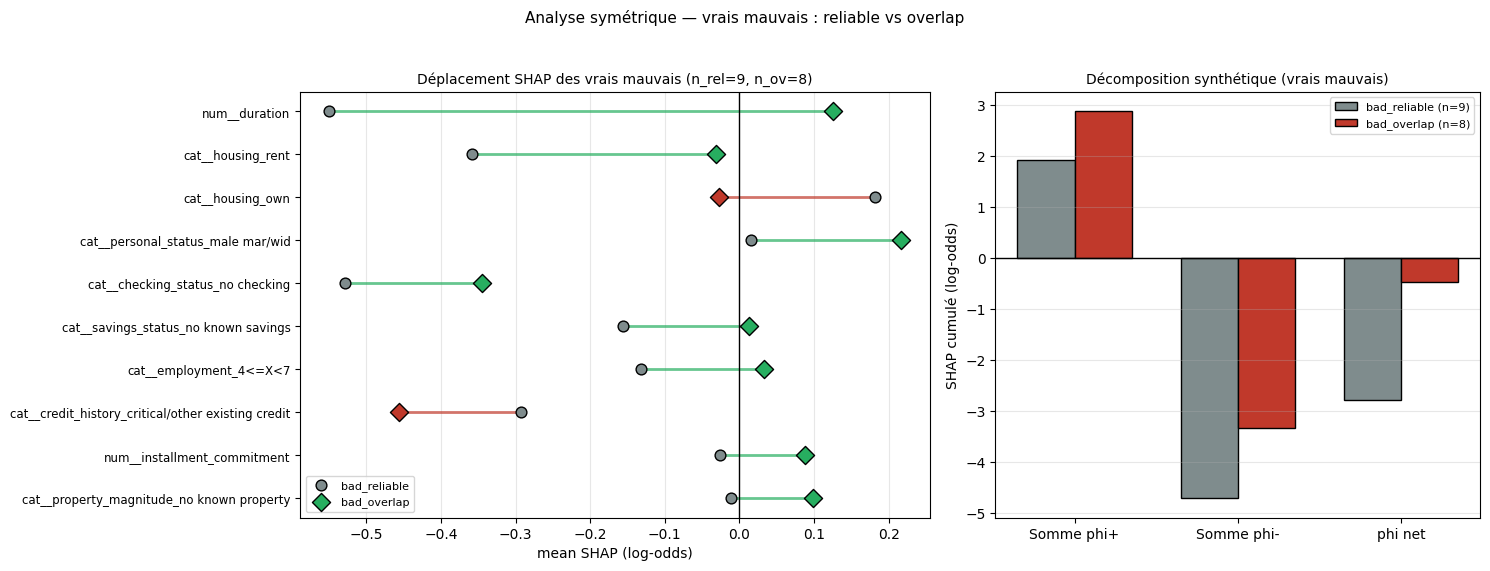

In [341]:
def decompose(shap_block):
    pos = np.where(shap_block > 0, shap_block, 0).sum(axis=1)
    neg = np.where(shap_block < 0, shap_block, 0).sum(axis=1)
    return pos.mean(), neg.mean(), (pos + neg).mean()

shap_br = shap_test[young_bad_reliable]
shap_bo = shap_test[young_bad_overlap]
n_br = int(young_bad_reliable.sum())
n_bo = int(young_bad_overlap.sum())

mean_br, mean_bo = shap_br.mean(axis=0), shap_bo.mean(axis=0)
delta_bad = mean_bo - mean_br
shift_bad = pd.DataFrame({
    'mean_shap_bad_reliable': mean_br,
    'mean_shap_bad_overlap':  mean_bo,
    'delta_bad':              delta_bad,
    'abs_delta':              np.abs(delta_bad),
}, index=feature_names).sort_values('abs_delta', ascending=False)
shift_bad.to_csv('shap_outputs/shap_shift_bad_reliable_vs_overlap.csv')

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5),
                         gridspec_kw={'width_ratios': [1.3, 1]})

top_b = shift_bad.head(10).iloc[::-1]
for i, (feat, row) in enumerate(top_b.iterrows()):
    r, o  = row['mean_shap_bad_reliable'], row['mean_shap_bad_overlap']
    color = '#27AE60' if o > r else '#C0392B'
    axes[0].plot([r, o], [i, i], color=color, lw=2, alpha=0.7, zorder=2)
    axes[0].scatter(r, i, color='#7F8C8D', s=60, edgecolor='black', zorder=3,
                    label='bad_reliable' if i == 0 else None)
    axes[0].scatter(o, i, color=color, s=85, edgecolor='black', marker='D', zorder=3,
                    label='bad_overlap' if i == 0 else None)
axes[0].axvline(0, color='black', lw=1)
axes[0].set_yticks(range(len(top_b)))
axes[0].set_yticklabels(top_b.index, fontsize=8.5)
axes[0].set_xlabel('mean SHAP (log-odds)')
axes[0].set_title(f'Déplacement SHAP des vrais mauvais (n_rel={n_br}, n_ov={n_bo})',
                  fontsize=10)
axes[0].legend(fontsize=8); axes[0].grid(axis='x', alpha=0.3)

pos_br, neg_br, net_br = decompose(shap_br)
pos_bo, neg_bo, net_bo = decompose(shap_bo)
x = np.arange(3); w = 0.35
axes[1].bar(x - w/2, [pos_br, neg_br, net_br], w, color='#7F8C8D', edgecolor='black',
            label=f'bad_reliable (n={n_br})')
axes[1].bar(x + w/2, [pos_bo, neg_bo, net_bo], w, color='#C0392B', edgecolor='black',
            label=f'bad_overlap (n={n_bo})')
axes[1].axhline(0, color='black', lw=1)
axes[1].set_xticks(x); axes[1].set_xticklabels(['Somme phi+', 'Somme phi-', 'phi net'])
axes[1].set_ylabel('SHAP cumulé (log-odds)')
axes[1].set_title('Décomposition synthétique (vrais mauvais)', fontsize=10)
axes[1].legend(fontsize=8); axes[1].grid(axis='y', alpha=0.3)

fig.suptitle('Analyse symétrique — vrais mauvais : reliable vs overlap',
             y=1.03, fontsize=11)
plt.tight_layout()
plt.savefig('shap_outputs/fig_bad_shap_shift.png', dpi=150, bbox_inches='tight')
plt.show()

### Analyse

On retrouve ici un phénomène symétrique à celui observé chez les vrais *good*.

Dans les régions `bad_reliable`, les contributions défavorables dominent clairement le score final.  

En se rapprochant de l’overlap, cette dominance s’affaiblit progressivement,
certaines contributions négatives perdent en intensité tandis que plusieurs contributions positives remontent.

Cependant, la figure révèle surtout un point plus intéressant.
Les vrais *bad* de l’overlap commencent à présenter plusieurs caractéristiques statistiquement associées aux bons profils. Certaines variables produisent ainsi des contributions favorables beaucoup plus importantes dans `bad_overlap` que dans `bad_reliable`.

> L’overlap apparaît ainsi comme une région où certaines observations
> empruntent simultanément des caractéristiques explicatives aux deux classes,
> ce qui rend leur séparation beaucoup plus fragile pour le modèle.

###  8.8 Contribution au score vs pouvoir discriminant


Les analyses précédentes ont montré que certaines variables restaient très présentes dans les scores de l’overlap.

Mais une variable peut fortement influencer le score sans réellement aider le modèle à séparer les classes.

Dans certains cas, une variable produit :
- des contributions SHAP de forte amplitude 
- mais de signe et d’intensité très proches chez les profils *good* et *bad*

Elle participe alors activement au calcul du score, tout en apportant très peu d’information discriminante.

Ce phénomène est particulièrement important pour les variables catégorielles encodées en one-hot, comme vu plus haut, 
une modalité rare ou atypique peut générer de fortes contributions SHAP dans les deux classes, simplement parce qu’elle s’éloigne fortement du profil moyen de référence.

> Une forte contribution SHAP traduit donc une influence locale sur la décision du modèle, mais pas nécessairement une capacité à distinguer efficacement les profils *good* des profils *bad*.



---

L’enjeu devient alors d’identifier les variables qui :
- structurent fortement les scores.
- mais dont le signal nous permet de départager entre les deux classes dans la région d’overlap.

---

Le pouvoir discriminant d’une variable est ici mesuré par l’écart moyen de contribution SHAP entre les deux classes :

$$
\Delta_j
=
\overline{\phi_j \mid Y=1}
-
\overline{\phi_j \mid Y=0}
$$

où :
- $\overline{\phi_j \mid Y=1}$ correspond à la contribution moyenne de la variable chez les profils *good* ;
- $\overline{\phi_j \mid Y=0}$ à celle observée chez les profils *bad*.

Ainsi :
- un $|\Delta_j|$ élevé indique que la variable contribue différemment selon la classe et possède donc un fort pouvoir séparateur. 
- un $|\Delta_j|$ proche de zéro signifie au contraire que la variable agit de manière similaire chez les *good* et les *bad*, même si sa contribution au score reste importante.

In [342]:
mask_reliable    = young_good_reliable | young_bad_reliable
mask_overlap_all = young_good_overlap  | young_bad_overlap

contrib_rel = np.abs(shap_test[mask_reliable]).mean(axis=0)
contrib_ov  = np.abs(shap_test[mask_overlap_all]).mean(axis=0)

delta_rel = (shap_test[young_good_reliable].mean(axis=0)
             - shap_test[young_bad_reliable].mean(axis=0))
delta_ov  = (shap_test[young_good_overlap].mean(axis=0)
             - shap_test[young_bad_overlap].mean(axis=0))

cd_df = pd.DataFrame({
    'contribution_reliable': contrib_rel,
    'contribution_overlap':  contrib_ov,
    'delta_reliable':        delta_rel,
    'delta_overlap':         delta_ov,
    'abs_delta_reliable':    np.abs(delta_rel),
    'abs_delta_overlap':     np.abs(delta_ov),
}, index=feature_names)
cd_df.to_csv('shap_outputs/contribution_vs_discrimination.csv')

print(f'Régions (jeunes) : reliable n={int(mask_reliable.sum())}, '
      f'overlap n={int(mask_overlap_all.sum())}')
display(cd_df.sort_values('contribution_overlap', ascending=False)
             .head(10)[['contribution_overlap', 'abs_delta_overlap',
                        'contribution_reliable', 'abs_delta_reliable']].round(3))


Régions (jeunes) : reliable n=18, overlap n=19


,contribution_overlap,abs_delta_overlap,contribution_reliable,abs_delta_reliable
cat__checking_status_no checking,0.571,0.050,0.596,0.489
cat__credit_history_critical/other existing credit,0.516,0.268,0.550,0.164
cat__housing_rent,0.486,0.315,0.566,0.000
cat__housing_own,0.321,0.203,0.359,0.000
cat__personal_status_male single,0.308,0.013,0.311,0.131
num__duration,0.279,0.038,0.505,0.788
cat__purpose_new car,0.222,0.027,0.249,0.088
cat__employment_4<=X<7,0.216,0.045,0.198,0.220
num__existing_credits,0.215,0.011,0.209,0.000
cat__savings_status_no known savings,0.213,0.108,0.217,0.226


### Analyse

Un résultat important apparaît lorsqu’on compare simultanément :
- l’amplitude moyenne des contributions SHAP 
- et leur pouvoir discriminant

Certaines variables conservent des niveaux de contribution très proches entre les régions fiables et l’overlap, alors que leur capacité à séparer les classes chute fortement.

Par exemple, pour :

$$
\texttt{checking\_status\_no checking}
$$

la contribution moyenne reste presque inchangée :

$$
\text{reliable} : 0.596
\qquad
\text{overlap} : 0.571
$$

alors que le pouvoir discriminant devient presque nul :

$$
|\Delta_j|_{\text{reliable}} : 0.489
\qquad
|\Delta_j|_{\text{overlap}} : 0.050
$$

Le même phénomène apparaît pour :

$$
\texttt{num\_\_duration}
$$

qui reste contributive dans l’overlap malgré une quasi disparition de son pouvoir séparateur.

> Ces résultats montrent empiriquement qu’une variable peut rester très influente dans la construction du score tout en devenant peu discriminante entre *good* et *bad*.

### Comment lire cette visualisation

Cette visualisation croise deux dimensions complémentaires.

**→ Axe horizontal : la contribution au score.** </br>
Plus une variable est à droite, plus elle pèse dans le calcul du score.

**↑ Axe vertical : le pouvoir discriminant.** </br>
Plus une variable est haute, plus ses contributions diffèrent entre *good* et *bad*.

Chaque variable apparaît **deux fois** : </br>
- en gris dans la région fiable
- en orange dans la région d'overlap. 

Une ligne pointillée les relie, son inclinaison signale immédiatement si la variable change de rôle entre les deux régions.

*Pour explorer* : le menu déroulant isole une variable précise / 
les histogrammes du bas peuvent aussi servir de filtre par niveau de contribution ou de 
discrimination.

De plus :) 

Les quadrants permettent une lecture immédiate du rôle des variables ! 

- **haut droite** = variables à la fois influentes et discriminantes 
- **haut gauche** = variables  peu influentes mais discriminantes 
- **bas droite** =  variables influentes mais peu discriminantes 
- **bas gauche** =  variables faibles et peu informatives


In [343]:
import altair as alt

def _parse_feat(feat):
    if feat.startswith('num__'):
        return feat[5:], None
    if feat.startswith('cat__'):
        rest = feat[5:]
        for c in sorted(cat_cols, key=len, reverse=True):
            if rest.startswith(c + '_'):
                return c, rest[len(c) + 1:]
    return feat, None

# ── Dataframe format long : une ligne par (feature, région) + fréquences + jumeau ──
_rows = []
for feat in feature_names:
    col, modality = _parse_feat(feat)
    for region, m_good, m_bad, ccol, dcol, scol in [
        ('reliable', young_good_reliable, young_bad_reliable,
         'contribution_reliable', 'abs_delta_reliable', 'delta_reliable'),
        ('overlap',  young_good_overlap,  young_bad_overlap,
         'contribution_overlap',  'abs_delta_overlap',  'delta_overlap'),
    ]:
        if modality is not None:
            fg = (float((X_test.loc[m_good, col].astype(str) == str(modality)).mean())
                  if m_good.sum() else np.nan)
            fb = (float((X_test.loc[m_bad, col].astype(str) == str(modality)).mean())
                  if m_bad.sum() else np.nan)
            vtype = 'catégorielle'
            fg_str = f'{fg:.0%}' if not np.isnan(fg) else 'n/d'
            fb_str = f'{fb:.0%}' if not np.isnan(fb) else 'n/d'
        else:
            fg = fb = np.nan
            vtype = 'numérique'
            fg_str = fb_str = '— (numérique)'
        _rows.append({
            'feature': feat, 'region': region,
            'contribution': float(cd_df.loc[feat, ccol]),
            'discrimination': float(cd_df.loc[feat, dcol]),
            'delta_shap': float(cd_df.loc[feat, scol]),
            'type': vtype, 'freq_good': fg, 'freq_bad': fb,
            'freq_good_str': fg_str, 'freq_bad_str': fb_str,
        })

_by_feat = {}
for r in _rows:
    _by_feat.setdefault(r['feature'], {})[r['region']] = r
for feat, d in _by_feat.items():
    rel, ov = d['reliable'], d['overlap']
    rel['sib_contribution'], rel['sib_discrimination'] = ov['contribution'], ov['discrimination']
    ov['sib_contribution'],  ov['sib_discrimination']  = rel['contribution'], rel['discrimination']

alt_df = pd.DataFrame(_rows)

x_thr = float(cd_df['contribution_overlap'].median())
y_thr = float(cd_df['abs_delta_overlap'].median())
x_max = float(alt_df['contribution'].max())
y_max = float(alt_df['discrimination'].max())

region_scale = alt.Scale(domain=['reliable', 'overlap'], range=['#7F8C8D', '#E67E22'])
_feat_options = sorted(alt_df['feature'].unique().tolist())

# ════════ MOYENS DE FILTRAGE — définissent la population affichée ════════
# 1) brush sur la distribution des contributions
contrib_brush = alt.selection_interval(
    fields=['contribution'], encodings=['x'], name='brush_contribution')
# 2) brush sur la distribution du pouvoir discriminant
discrim_brush = alt.selection_interval(
    fields=['discrimination'], encodings=['x'], name='brush_discrimination')
# 3) brush 2D directement sur la carte
map_brush = alt.selection_interval(encodings=['x', 'y'], name='brush_map')
# 4) menu déroulant : isoler une variable précise
var_param = alt.param(
    name='var_param', value=None,
    bind=alt.binding_select(options=[None] + _feat_options,
                            name='Isoler une variable : '),
)

# ════════ INVESTIGATION — sur la carte filtrée ════════
# clic-toggle sur un point pour le mettre en avant
feature_sel = alt.selection_point(fields=['feature'], toggle=True, empty=False)

# ── Règle de paire : un point reste si LUI ou son jumeau passe les 4 filtres ──
def _c_ok(v):
    return ("(!isValid(brush_contribution.contribution) || ("
            f"{v} >= brush_contribution.contribution[0] && "
            f"{v} <= brush_contribution.contribution[1]))")
def _d_ok(v):
    return ("(!isValid(brush_discrimination.discrimination) || ("
            f"{v} >= brush_discrimination.discrimination[0] && "
            f"{v} <= brush_discrimination.discrimination[1]))")
def _map_ok(vc, vd):
    return ("((!isValid(brush_map.contribution) || ("
            f"{vc} >= brush_map.contribution[0] && {vc} <= brush_map.contribution[1])) && "
            "(!isValid(brush_map.discrimination) || ("
            f"{vd} >= brush_map.discrimination[0] && {vd} <= brush_map.discrimination[1])))")
_list_ok = "(var_param == null || var_param == datum.feature)"

_self_pass = (f"({_c_ok('datum.contribution')} && {_d_ok('datum.discrimination')} && "
              f"{_map_ok('datum.contribution', 'datum.discrimination')} && {_list_ok})")
_sib_pass = (f"({_c_ok('datum.sib_contribution')} && {_d_ok('datum.sib_discrimination')} && "
             f"{_map_ok('datum.sib_contribution', 'datum.sib_discrimination')} && {_list_ok})")
_pair_expr = f"({_self_pass} || {_sib_pass})"

_tooltip = [
    alt.Tooltip('feature:N',        title='Variable'),
    alt.Tooltip('region:N',         title='Région'),
    alt.Tooltip('type:N',           title='Type'),
    alt.Tooltip('contribution:Q',   title='Contribution',   format='.3f'),
    alt.Tooltip('discrimination:Q', title='Discrimination', format='.3f'),
    alt.Tooltip('delta_shap:Q',     title='Δ SHAP signé',   format='.3f'),
    alt.Tooltip('freq_good_str:N',  title='Fréq. modalité | good'),
    alt.Tooltip('freq_bad_str:N',   title='Fréq. modalité | bad'),
]

# ── Lignes pointillées reliant les 2 régions d'une même variable ──
connectors = alt.Chart(alt_df).mark_line(
    strokeDash=[3, 3], color='#9A9A9A', size=1,
).encode(
    x='contribution:Q', y='discrimination:Q', detail='feature:N',
    opacity=alt.condition(feature_sel, alt.value(0.85), alt.value(0.12)),
).transform_filter(_pair_expr)

# ── Nuage de points : porte les sélections (investigation + brush carte + menu) ──
points = alt.Chart(alt_df).mark_point(filled=True).encode(
    x=alt.X('contribution:Q',
            title='Contribution moyenne au score — mean(|SHAP|)'),
    y=alt.Y('discrimination:Q',
            title='Pouvoir discriminant — |mean SHAP good - mean SHAP bad|'),
    color=alt.Color('region:N', title='Région', scale=region_scale),
    opacity=alt.condition(feature_sel, alt.value(1.0), alt.value(0.55)),
    size=alt.condition(feature_sel, alt.value(220), alt.value(70)),
    tooltip=_tooltip,
).add_params(feature_sel, map_brush, var_param).transform_filter(_pair_expr)

# ── Étiquettes : variables investiguées (cliquées) ET dans la population ──
labels = alt.Chart(alt_df).mark_text(
    dx=10, dy=-10, fontSize=10, fontWeight='bold',
).encode(
    x='contribution:Q', y='discrimination:Q', text='feature:N',
    color=alt.Color('region:N', scale=region_scale, legend=None),
).transform_filter(feature_sel).transform_filter(_pair_expr)

# ── Lignes de référence + étiquettes de quadrant ──
vline = alt.Chart(pd.DataFrame({'x': [x_thr]})).mark_rule(
    color='gray', strokeDash=[4, 4]).encode(x='x:Q')
hline = alt.Chart(pd.DataFrame({'y': [y_thr]})).mark_rule(
    color='gray', strokeDash=[4, 4]).encode(y='y:Q')

def _quad(x, y, txt, align):
    return alt.Chart(pd.DataFrame({'x': [x], 'y': [y], 't': [txt]})).mark_text(
        fontSize=9, fontStyle='italic', color='#9A9A9A', align=align,
    ).encode(x='x:Q', y='y:Q', text='t:N')

q1 = _quad(x_max * 0.99, y_max * 0.98, 'influente & discriminante', 'right')
q2 = _quad(x_max * 0.99, y_max * 0.02, 'influente mais peu discriminante', 'right')
q3 = _quad(x_max * 0.01, y_max * 0.02, 'faible & non discriminante', 'left')

scatter_map = (connectors + vline + hline + points + labels + q1 + q2 + q3).properties(
    width=660, height=450,
    title='Contribution au score vs pouvoir discriminant — lecture interactive',
)

# ── Distributions marginales par zone (sources des brushs 1 et 2) ──
contrib_hist = alt.Chart(alt_df).mark_bar(opacity=0.55).encode(
    x=alt.X('contribution:Q', bin=alt.Bin(maxbins=24),
            title='Contribution moyenne au score'),
    y=alt.Y('count():Q', title='nb variables', stack=None),
    color=alt.Color('region:N', scale=region_scale,
                    legend=alt.Legend(title='Région', orient='top')),
).add_params(contrib_brush).properties(
    width=320, height=140,
    title='Distribution — contribution  (brush = filtre 1)',
)

discrim_hist = alt.Chart(alt_df).mark_bar(opacity=0.55).encode(
    x=alt.X('discrimination:Q', bin=alt.Bin(maxbins=24),
            title='Pouvoir discriminant'),
    y=alt.Y('count():Q', title='nb variables', stack=None),
    color=alt.Color('region:N', scale=region_scale, legend=None),
).add_params(discrim_brush).properties(
    width=320, height=140,
    title='Distribution — discrimination  (brush = filtre 2)',
)

chart = alt.vconcat(
    scatter_map,
    alt.hconcat(contrib_hist, discrim_hist),
).configure_view(strokeOpacity=0)

chart


alt.VConcatChart(...)

### Analyse

La différence entre régions fiables et overlap apparaît encore plus 
clairement lorsqu'on observe simultanément :

- la position des points
- leurs trajectoires
- et les distributions marginales des histogrammes

**Dans les régions fiables (gris)**, plusieurs variables occupent 
encore la partie supérieure droite du plan. Elles sont à la fois 
influentes et fortement discriminantes. L'histogramme du pouvoir 
discriminant montre ainsi une queue relativement étendue vers des 
valeurs élevées.


**À l'inverse, dans l'overlap (orange)**, les points se déplacent 
massivement vers le bas du graphique. L'histogramme de discrimination 
devient alors fortement concentré près de zéro. Les variables 
réellement séparatrices deviennent beaucoup plus rares.

En revanche, l'histogramme des contributions reste relativement 
étalé. Autrement dit, de nombreuses variables continuent à fortement 
participer au calcul du score même dans l'overlap.

Ce contraste est central :

- la capacité des variables à **influencer** le score **persiste** ;
- mais leur capacité à **distinguer *good* et *bad*** **s'effondre** localement.

Les segments pointillés rendent ce déplacement visible variable par 
variable : plusieurs trajectoires deviennent principalement verticales, 
traduisant une perte de discrimination beaucoup plus forte qu'une 
perte d'influence.

> L'overlap correspond donc à une région où le modèle continue à 
> exploiter activement les variables, mais où les variables 
> véritablement discriminantes deviennent progressivement minoritaires.

<h2>9. Robustesse — domain-shift sur P(A)</h2>

<h3>9.1 Pourquoi pas le bruit gaussien ?</h3>

<p>
Le réflexe classique pour évaluer la robustesse consiste à ajouter un bruit gaussien :

$$
\sigma \times std(x)
$$

sur les variables numériques.
</p>

<br>

<div style="
margin:1.2em 0;
padding-left:1.1em;
border-left:3px solid #b88a4a;
line-height:1.9;
">

Sur German Credit, ce test possède cependant peu d’ancrage conceptuel.

Les variables :
- `duration`,
- `credit_amount`,
- `age`,
- `installment_rate`

ne proviennent pas de capteurs bruités,
mais de champs administratifs déclarés ou calculés.

</div>

<div style="
margin-top:1.2em;
padding:0.95em 1.15em;
background:rgba(255,255,255,0.035);
border-left:3px solid #666;
border-radius:6px;
line-height:1.9;
">

Le bruit gaussien simulerait donc une incertitude de mesure essentiellement absente dans ce contexte bancaire.

</div>

---

<h3>9.2 Formaliser le shift épistémique</h3>

<p>
Les principales sources d’incertitude sur German Credit sont plutôt :
</p>

<div style="
margin:1.4em 0;
padding-left:1.1em;
border-left:3px solid #7a8fb8;
line-height:1.9;
">

- <b>Limited Training Data</b> — échantillon historique limité (~1000 observations)

- <b>Deployment &amp; External Factors</b> — évolution future de la clientèle bancaire

</div>

<p>
Il s’agit donc d’incertitudes <b>épistémiques</b> :
</p>

<div style="
text-align:center;
font-size:1.05em;
margin:1.7em 0;
">

$$
\text{Predictive Uncertainty}
\;\rightarrow\;
\text{Epistemic}
\;\rightarrow\;
\text{Domain-shift}
$$

</div>

---

<h3>9.3 Shift sur la population jeune</h3>

<p>
Le cours décompose :
</p>

$$
P(y,x)=P(y\mid x)\cdot P(x)
$$

<p>
Nous simulons ici un <i>prior shift</i> portant sur :
</p>

<div style="
text-align:center;
font-size:1.05em;
margin:1.5em 0;
">

$$
P(A=\text{jeune})
$$

</div>

<p>
tandis que :
</p>

$$
P(y\mid x)
$$

<p>
reste supposé stable.
</p>

<div style="
margin-top:1.2em;
padding:0.95em 1.15em;
background:rgba(255,255,255,0.035);
border-left:3px solid #666;
border-radius:6px;
line-height:1.9;
">

Le scénario correspond par exemple à :
- une clientèle qui rajeunit 
- une nouvelle stratégie commerciale 
- ou l’ouverture vers de nouveaux segments emprunteurs

</div>

---

<h3>9.4 Pourquoi ce test est important pour le reweighting</h3>

<p>
La méthode Reweighted repose sur des poids :
</p>

$$
w(a,y)
=
\frac{
\hat P(A=a)\hat P(Y=y)
}{
\hat P(A=a,Y=y)
}
$$

<p>
estimés sur la distribution d’entraînement.
</p>

<div style="
margin-top:1.3em;
padding:1em 1.15em;
background:rgba(255,255,255,0.03);
border-left:3px solid #666;
border-radius:6px;
line-height:1.95;
">

La garantie fairness obtenue est donc conditionnelle à :

$$
P_{\text{prod}}(A)
\approx
\hat P_{\text{train}}(A)
$$

Un shift sur :

$$
P(A)
$$

interroge alors directement la robustesse de la mitigation apprise.

</div>

In [344]:
# Sanity check des variables requises pour §11                                                                                     
for v in ["A_test", "y_test", "X_test", "baseline", "reweighted"]:                                                                 
    assert v in dir(), f"❌ {v} non défini — relance les cellules précédentes"                                                     
print("✓ Toutes les variables requises sont chargées")      

✓ Toutes les variables requises sont chargées


In [345]:
# ========== Robustesse domain-shift : protocole ==========
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, f1_score

TAU        = 5/6
C_FP, C_FN = 5, 1
PI_LIST    = [0.05, 0.13, 0.20, 0.30, 0.40]   # P(A=jeune) cible
N_REPS     = 50
RNG        = np.random.default_rng(42)

# Convention : "jeune" = classe minoritaire (~13 % sur German Credit)
A_arr = np.asarray(A_test)
y_arr = np.asarray(y_test)
JEUNE  = 0 if (A_arr == 0).mean() < 0.5 else 1
ADULTE = 1 - JEUNE
idx_j  = np.where(A_arr == JEUNE)[0]
idx_a  = np.where(A_arr == ADULTE)[0]
n_test = len(A_arr)
print(f"Convention : A={JEUNE} = jeune  |  P(jeune)_test = {(A_arr==JEUNE).mean():.3f}")
print(f"n_jeunes = {len(idx_j)}  |  n_adultes = {len(idx_a)}")

# Scores des deux modèles (figés ; le shift change la composition du test, pas le modèle)
proba_nat = baseline.predict_proba(X_test)[:, 1]
proba_rw  = reweighted.predict_proba(X_test)[:, 1]


Convention : A=1 = jeune  |  P(jeune)_test = 0.147
n_jeunes = 44  |  n_adultes = 256


In [346]:
# ========== Métriques sur un sous-échantillon (par indices) ==========
def metrics_on(idx, proba_all):
    y_b, A_b, p_b = y_arr[idx], A_arr[idx], proba_all[idx]
    yhat  = (p_b >= TAU).astype(int)
    auroc = roc_auc_score(y_b, p_b) if len(np.unique(y_b)) > 1 else np.nan
    f1    = f1_score(y_b, yhat, zero_division=0)
    fp    = int(((yhat==1) & (y_b==0)).sum())
    fn    = int(((yhat==0) & (y_b==1)).sum())
    cost  = C_FP*fp + C_FN*fn
    m_j   = (A_b == JEUNE)  & (y_b == 1)
    m_a   = (A_b == ADULTE) & (y_b == 1)
    tpr_j = yhat[m_j].mean() if m_j.sum() else np.nan
    tpr_a = yhat[m_a].mean() if m_a.sum() else np.nan
    return auroc, f1, cost, abs(tpr_j - tpr_a)

# ========== Boucle domain-shift ==========
models       = {"Naturel": proba_nat, "Reweighted": proba_rw}
metric_names = ["AUROC", "F1", "Coût", "|ΔEOpp|"]
results = {m: {k: np.zeros((len(PI_LIST), N_REPS)) for k in metric_names}
           for m in models}

for i, pi in enumerate(PI_LIST):
    n_j = int(round(pi * n_test))
    n_a = n_test - n_j
    for r in range(N_REPS):
        sel = np.concatenate([
            RNG.choice(idx_j, size=n_j, replace=True),
            RNG.choice(idx_a, size=n_a, replace=True),
        ])
        for name, p_all in models.items():
            auroc, f1, cost, deop = metrics_on(sel, p_all)
            results[name]["AUROC"][i, r]   = auroc
            results[name]["F1"][i, r]      = f1
            results[name]["Coût"][i, r]    = cost
            results[name]["|ΔEOpp|"][i, r] = deop


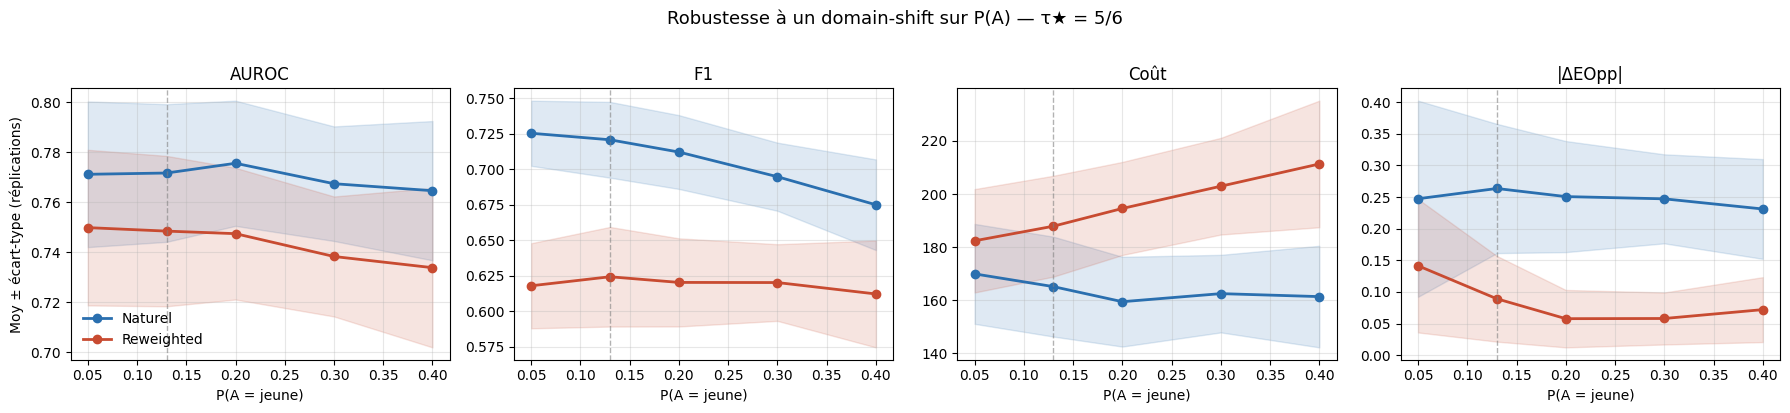

In [347]:
# ========== Figure 1 × 4 : moyennes ± écart-type sur réplications ==========
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
colors = {"Naturel": "#2A6FAF", "Reweighted": "#C84B31"}

for k, metric in enumerate(metric_names):
    ax = axes[k]
    for name in models:
        vals = results[name][metric]
        mu   = np.nanmean(vals, axis=1)
        sd   = np.nanstd(vals,  axis=1)
        ax.plot(PI_LIST, mu, "-o", color=colors[name], lw=2, label=name)
        ax.fill_between(PI_LIST, mu-sd, mu+sd, color=colors[name], alpha=0.15)
    ax.axvline(0.13, color="gray", ls="--", lw=1, alpha=0.6)
    ax.set_xlabel("P(A = jeune)")
    ax.set_title(metric)
    if k == 0:
        ax.legend(frameon=False)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Moy ± écart-type (réplications)")
plt.suptitle("Robustesse à un domain-shift sur P(A) — τ★ = 5/6", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


In [348]:
# ========== Tableau de synthèse : référence (π=0.13) vs shift (π=0.40) ==========
rows = []
for name in models:
    for metric in metric_names:
        ref = np.nanmean(results[name][metric][1])
        ext = np.nanmean(results[name][metric][-1])
        rel = (ext - ref) / ref * 100 if ref != 0 else np.nan
        rows.append({
            "Modèle":          name,
            "Métrique":        metric,
            "π=0.13 (réf.)":   f"{ref:.3f}",
            "π=0.40 (shift)":  f"{ext:.3f}",
            "Δ relatif (%)":   f"{rel:+.1f}",
        })
synth = pd.DataFrame(rows)
print(synth.to_string(index=False))


    Modèle Métrique π=0.13 (réf.) π=0.40 (shift) Δ relatif (%)
   Naturel    AUROC         0.772          0.765          -0.9
   Naturel       F1         0.721          0.675          -6.4
   Naturel     Coût       165.140        161.380          -2.3
   Naturel  |ΔEOpp|         0.264          0.231         -12.3
Reweighted    AUROC         0.748          0.734          -2.0
Reweighted       F1         0.624          0.612          -1.9
Reweighted     Coût       187.900        211.340         +12.5
Reweighted  |ΔEOpp|         0.089          0.072         -19.2


Le modèle **reweighted** corrige l’asymétrie d’Equal Opportunity en forçant une meilleure reconnaissance des bons profils du groupe défavorisé, mais cette correction déplace la frontière de décision vers une zone plus ambiguë du score, où le modèle accepte davantage de profils risqués ; d’où une amélioration du gap EOpp au prix d’une explosion du coût sous domain-shift. À l’inverse, le modèle **naturel** reste plus stable en coût car il conserve une règle de décision alignée avec le risque moyen appris, mais cette stabilité économique s’obtient en laissant persister une inégalité structurelle de TPR entre groupes.

On retrouve ici le phénomène d’<i>overconfidence fairness</i> :
un modèle peut paraître équitable <i>in-domain</i>,
tout en devenant progressivement moins fiable sous <i>domain-shift</i>.